# Module 02.5: Senescence Probability Modeling

Statistical modeling of cellular senescence probability across aging and disease.

---

**Part 0 (QC):** Sample composition and confidence assessment
- Donor-celltype sampling depth analysis
- Confidence-weighted visualization (opacity = donor contribution to cell type)
- Flags low-confidence observations (<P10 of n_cells per cell type)

**Part 1 (Cell-level):** Does the probability of a cell being senescent increase with age?
- Logistic GLMM with random intercept for donor
- Output: Odds Ratio per decade

**Part 2 (Donor-level):** Does the proportion of senescent cells per donor increase with age?
- Zero-Inflated Beta regression (Group A: ≥10% zeros) or Standard Beta regression (Group B: <10% zeros)
- 12 model configurations for Group A, 4 for Group B
- Output: β per decade, exp(β) = odds ratio (logit) or ≈ relative risk (cloglog)

**Part 3 (Groups):** Is senescence higher in Old vs Young?
- 3A/3B: Mann-Whitney U test with Cliff's δ effect size (overall + per cell type)
- 3C: Senescence marker expression by age group (Non-SnC vs SnC × Young vs Old)
- Output: Effect size, direction, log2FC

---

**Cells 1–3:** Config, Load, Harmonize
- Map source columns to standard names (Age, Sex, Cohort, Donor, Cell_Type, is_senescent)
- Create df_cells, df_donor, df_donor_ct with derived columns (prop_snc, Age_scaled)

**Cell 4:** Part 0 (Sample Composition QC)
- Sampling depth statistics per cell type
- Confidence-weighted boxplot with low-confidence flagging

**Cells 5–7:** Part 1 (Cell-level)
- 1A: Overall logistic GLMM
- 1B: Per cell type logistic GLMM
- Visualization

**Cells 8–10:** Part 2 (Donor-level Beta Regression)
- Cell 8: Classification (Group A vs B based on % zeros)
- Cell 9: Part 2A — Overall beta regression
- Cell 10: Part 2B — Per cell type beta regression + visualization

**Cells 11–13:** Part 3 (Group Comparisons)
- Cell 11: Part 3A/3B — Young vs Old senescence proportion (overall + per cell type)
- Cell 12: Part 3C — Marker expression by age group
- Cell 13: Visualization

**Cell 14:** Export all results

---

**Transformations:**
- v1: Epsilon clipping — `clip(prop, 1e-6, 1-1e-6)`
- v2: Smithson-Verkuilen — `(prop × (n-1) + 0.5) / n`

**Formulas:**
- Conditional: `prop_adj ~ Age_scaled + Sex + Cohort`
- Zero-inflation (Group A only): `zi_full`, `zi_age`, `zi_int`

**Link functions:**
- logit: exp(β) = odds ratio
- cloglog: exp(β) ≈ relative risk

**Model keys:**
- Group A (ZI Beta): `{v1,v2}_{logit,cloglog}_{zi_full,zi_age,zi_int}` (12 models)
- Group B (Standard): `{v1,v2}_{logit,cloglog}` (4 models)

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# CONFIG + IMPORTS
# ════════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# R Environment (must be set BEFORE importing rpy2)
# ─────────────────────────────────────────────────────────────────────────────

import os
os.environ['R_HOME'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R'
os.environ['R_LIBS'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'
os.environ['R_LIBS_USER'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'

# ─────────────────────────────────────────────────────────────────────────────
# Python Imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MODULE 02.5: SENESCENCE PROBABILITY MODELING")
print("="*60)
print("\n✓ Python packages loaded")

# ─────────────────────────────────────────────────────────────────────────────
# rpy2 Setup (Python-R interface)
# ─────────────────────────────────────────────────────────────────────────────

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

print(f"✓ rpy2 loaded | {ro.r('R.version$version.string')[0]}")

# Load R packages
ro.r('suppressPackageStartupMessages(library(lme4))')     # Logistic GLMM
ro.r('suppressPackageStartupMessages(library(glmmTMB))')  # Zero-Inflated Beta

lme4_ver = ro.r('as.character(packageVersion("lme4"))')[0]
glmmtmb_ver = ro.r('as.character(packageVersion("glmmTMB"))')[0]
print(f"✓ R packages: lme4 {lme4_ver}, glmmTMB {glmmtmb_ver}")

# ════════════════════════════════════════════════════════════════════════════════
# DATASET SELECTION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = 'psychad_aging'  # ← CHANGE THIS TO SWITCH DATASETS

# ════════════════════════════════════════════════════════════════════════════════
# DATASET-SPECIFIC COLUMN MAPPINGS
#
# Each dataset has different column names. This CONFIG maps them to standard names.
# To add a new dataset: add an entry with the source column names.
# ════════════════════════════════════════════════════════════════════════════════

CONFIG = {
    'psychad_aging': {
        'age': 'Age',
        'sex': 'Sex',
        'cohort': 'Cohort',
        'donor': 'Sample',
        'celltype': 'subclass',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': None,  # No diagnosis column (aging cohort)
    },
    'psychad_ad': {
        'age': 'Age',
        'sex': 'Sex',
        'cohort': 'Cohort',
        'donor': 'Sample',
        'celltype': 'subclass',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': 'Diagnosis',  # AD, MCI, Control
    },
    'mathys_2019': {
        'age': 'age_death',
        'sex': 'msex',
        'cohort': 'cohort',
        'donor': 'projid',
        'celltype': 'broad.cell.type',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': 'braaksc',
    },
    # Add more datasets as needed
}

# ─────────────────────────────────────────────────────────────────────────────
# Extract source column names for this dataset
# ─────────────────────────────────────────────────────────────────────────────

cfg = CONFIG[DATASET]

SRC_AGE = cfg['age']
SRC_SEX = cfg['sex']
SRC_COHORT = cfg['cohort']
SRC_DONOR = cfg['donor']
SRC_CELLTYPE = cfg['celltype']
SRC_SENESCENT = cfg['senescent']
SRC_STUDYGROUP = cfg['study_group']
SRC_DIAGNOSIS = cfg['diagnosis']  # None for aging cohorts

# ════════════════════════════════════════════════════════════════════════════════
# STANDARD COLUMN NAMES
#
# After Cell 3 harmonization, ALL cells use these names.
# This ensures the analysis code works regardless of source dataset.
# ════════════════════════════════════════════════════════════════════════════════

COL_AGE = 'Age'
COL_SEX = 'Sex'
COL_COHORT = 'Cohort'
COL_DONOR = 'Donor'
COL_CELLTYPE = 'Cell_Type'
COL_SENESCENT = 'is_senescent'
COL_STUDYGROUP = 'Study_Group'
COL_DIAGNOSIS = 'Diagnosis'

# ════════════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ════════════════════════════════════════════════════════════════════════════════

AGE_SCALE = 10      # Coefficients = effect per decade
EPSILON = 0.000001     # Beta regression boundary adjustment
MIN_CELLS = 100     # Min cells per cell type
MIN_DONORS = 15     # Min donors for mixed models

# ════════════════════════════════════════════════════════════════════════════════
# PATHS
# ════════════════════════════════════════════════════════════════════════════════

BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
INPUT_FILE = BASE_DIR / 'data/processed' / f'{DATASET}_senescence_scored.h5ad'
RESULTS_DIR = BASE_DIR / 'results/02.5_probability_modeling' / DATASET
FIGURES_DIR = BASE_DIR / 'figures/02.5_probability_modeling' / DATASET

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════════
# STUDY GROUP COLORS (for visualization)
# ════════════════════════════════════════════════════════════════════════════════

STUDY_GROUP_COLORS = {
    # Aging (cool → warm)
    'Age_20_29': '#2E86AB',
    'Age_30_39': '#4A90E2',
    'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347',
    'Age_60_69': '#FF8C00',
    'Age_70_79': '#E24A4A',
    'Age_80_89': '#8B0000',
    'Age_80_100': '#8B0000',
    'Age_90_99': '#4A0000',
    # Disease
    'Control': '#4E79A7',
    'NCI': '#4E79A7',
    'MCI': '#F28E2B',
    'AD': '#E15759',
}

# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("CONFIGURATION")
print(f"{'─'*60}")

print(f"\nDataset: {DATASET}")
print(f"Cohort type: {'Disease' if SRC_DIAGNOSIS else 'Aging'}")

print(f"\nSource → Standard column mapping:")
print(f"  {SRC_AGE} → {COL_AGE}")
print(f"  {SRC_SEX} → {COL_SEX}")
print(f"  {SRC_COHORT} → {COL_COHORT}")
print(f"  {SRC_DONOR} → {COL_DONOR}")
print(f"  {SRC_CELLTYPE} → {COL_CELLTYPE}")
print(f"  {SRC_SENESCENT} → {COL_SENESCENT}")
print(f"  {SRC_STUDYGROUP} → {COL_STUDYGROUP}")
if SRC_DIAGNOSIS:
    print(f"  {SRC_DIAGNOSIS} → {COL_DIAGNOSIS}")

print(f"\nParameters:")
print(f"  AGE_SCALE = {AGE_SCALE} (coefficients per decade)")
print(f"  MIN_CELLS = {MIN_CELLS}")
print(f"  MIN_DONORS = {MIN_DONORS}")

print(f"\nPaths:")
print(f"  Input:   {INPUT_FILE}")
print(f"  Results: {RESULTS_DIR}")
print(f"  Figures: {FIGURES_DIR}")

print(f"\n✓ Config complete → Cell 2: Load Data")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


MODULE 02.5: SENESCENCE PROBABILITY MODELING

✓ Python packages loaded
✓ rpy2 loaded | R version 4.5.1 (2025-06-13)


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘lme4’ was built under R version 4.5.2 
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘glmmTMB’ was built under R version 4.5.2 
  


✓ R packages: lme4 1.1.38, glmmTMB 1.1.13

────────────────────────────────────────────────────────────
CONFIGURATION
────────────────────────────────────────────────────────────

Dataset: psychad_aging
Cohort type: Aging

Source → Standard column mapping:
  Age → Age
  Sex → Sex
  Cohort → Cohort
  Sample → Donor
  subclass → Cell_Type
  is_senescent → is_senescent
  Study_Group → Study_Group

Parameters:
  AGE_SCALE = 10 (coefficients per decade)
  MIN_CELLS = 100
  MIN_DONORS = 15

Paths:
  Input:   /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_senescence_scored.h5ad
  Results: /fs/scratch/PAS2598/senescence_analysis/results/02.5_probability_modeling/psychad_aging
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging

✓ Config complete → Cell 2: Load Data


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("LOAD DATA")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Load AnnData
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nLoading: {INPUT_FILE.name}")
adata = sc.read_h5ad(INPUT_FILE)
print(f"✓ Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

# ─────────────────────────────────────────────────────────────────────────────
# Verify required columns exist
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("COLUMN VERIFICATION")
print(f"{'─'*60}")

required = {
    'Age': SRC_AGE,
    'Sex': SRC_SEX,
    'Cohort': SRC_COHORT,
    'Donor': SRC_DONOR,
    'Cell Type': SRC_CELLTYPE,
    'Senescent': SRC_SENESCENT,
    'Study Group': SRC_STUDYGROUP,
}

missing = []
for name, col in required.items():
    if col in adata.obs.columns:
        print(f"  ✓ {name}: '{col}'")
    else:
        print(f"  ✗ {name}: '{col}' NOT FOUND")
        missing.append(col)

# Optional diagnosis column
if SRC_DIAGNOSIS:
    if SRC_DIAGNOSIS in adata.obs.columns:
        print(f"  ✓ Diagnosis: '{SRC_DIAGNOSIS}'")
    else:
        print(f"  ⚠ Diagnosis: '{SRC_DIAGNOSIS}' NOT FOUND (Part 3B will be skipped)")

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ─────────────────────────────────────────────────────────────────────────────
# Data Overview
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("DATA OVERVIEW")
print(f"{'─'*60}")

# Donors
n_donors = adata.obs[SRC_DONOR].nunique()
print(f"\nDonors: {n_donors}")

# Age
ages = adata.obs[SRC_AGE].dropna()
print(f"Age range: {ages.min():.0f} - {ages.max():.0f} (median: {ages.median():.0f})")

# Sex
sex_counts = adata.obs[SRC_SEX].value_counts()
print(f"Sex: {dict(sex_counts)}")

# Cohort
cohort_counts = adata.obs[SRC_COHORT].value_counts()
print(f"Cohorts: {len(cohort_counts)} ({', '.join(cohort_counts.index.tolist())})")

# Cell types
ct_counts = adata.obs[SRC_CELLTYPE].value_counts()
print(f"Cell types: {len(ct_counts)}")
for ct, n in ct_counts.items():
    print(f"  {ct}: {n:,}")

# Senescence
snc_counts = adata.obs[SRC_SENESCENT].value_counts()
n_snc = snc_counts.get(1, 0)
n_total = len(adata)
pct_snc = n_snc / n_total * 100
print(f"\nSenescent cells: {n_snc:,} / {n_total:,} ({pct_snc:.1f}%)")

# Study groups
sg_counts = adata.obs[SRC_STUDYGROUP].value_counts()
print(f"\nStudy groups: {len(sg_counts)}")
for sg, n in sg_counts.items():
    print(f"  {sg}: {n:,}")

# Diagnosis (if available)
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    dx_counts = adata.obs[SRC_DIAGNOSIS].value_counts()
    print(f"\nDiagnosis groups: {len(dx_counts)}")
    for dx, n in dx_counts.items():
        print(f"  {dx}: {n:,}")

# ─────────────────────────────────────────────────────────────────────────────
# QC Checks
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("QC CHECKS")
print(f"{'─'*60}")

# Check for missing values
print("\nMissing values:")
for name, col in required.items():
    n_missing = adata.obs[col].isna().sum()
    if n_missing > 0:
        print(f"  ⚠ {name}: {n_missing:,} missing")
    else:
        print(f"  ✓ {name}: no missing")

# Check donors have enough cells
cells_per_donor = adata.obs.groupby(SRC_DONOR).size()
donors_low = (cells_per_donor < MIN_CELLS).sum()
if donors_low > 0:
    print(f"\n⚠ {donors_low} donors have < {MIN_CELLS} cells")
else:
    print(f"\n✓ All donors have ≥ {MIN_CELLS} cells")

# Check cell types have enough cells
cells_per_ct = adata.obs.groupby(SRC_CELLTYPE).size()
ct_low = (cells_per_ct < MIN_CELLS).sum()
if ct_low > 0:
    print(f"⚠ {ct_low} cell types have < {MIN_CELLS} cells")
else:
    print(f"✓ All cell types have ≥ {MIN_CELLS} cells")

print(f"\n✓ Data loaded → Cell 3: Harmonization")

LOAD DATA

Loading: psychad_aging_senescence_scored.h5ad
✓ Loaded: 544,780 cells × 34,890 genes

────────────────────────────────────────────────────────────
COLUMN VERIFICATION
────────────────────────────────────────────────────────────
  ✓ Age: 'Age'
  ✓ Sex: 'Sex'
  ✓ Cohort: 'Cohort'
  ✓ Donor: 'Sample'
  ✓ Cell Type: 'subclass'
  ✓ Senescent: 'is_senescent'
  ✓ Study Group: 'Study_Group'

────────────────────────────────────────────────────────────
DATA OVERVIEW
────────────────────────────────────────────────────────────

Donors: 124
Age range: 20 - 90 (median: 54)
Sex: {'Male': np.int64(273716), 'Female': np.int64(271064)}
Cohorts: 2 (HBCC, Mt Sinai Brain Bank)
Cell types: 12
  Oligodendrocyte: 193,310
  Excitatory: 121,182
  Inhibitory: 90,648
  Astrocyte: 63,658
  OPC: 36,059
  Microglia: 22,475
  Endothelial: 7,501
  Pericyte: 4,136
  VLMC: 2,991
  PVM: 1,150
  Adaptive: 883
  VSMC: 787

Senescent cells: 25,358 / 544,780 (4.7%)

Study groups: 7
  Age_40_49: 90,929
  Age_20_2

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# DATA HARMONIZATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Creates 3 dataframes with STANDARD column names:
#   df_cells    - Cell-level (one row per cell)
#   df_donor    - Donor-level (one row per donor)
#   df_donor_ct - Donor × Cell Type (one row per donor-celltype)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("DATA HARMONIZATION")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Create df_cells (Cell-level)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_cells...")

df_cells = pd.DataFrame({
    COL_AGE: adata.obs[SRC_AGE].values,
    COL_SEX: adata.obs[SRC_SEX].values,
    COL_COHORT: adata.obs[SRC_COHORT].values,
    COL_DONOR: adata.obs[SRC_DONOR].values,
    COL_CELLTYPE: adata.obs[SRC_CELLTYPE].values,
    COL_SENESCENT: adata.obs[SRC_SENESCENT].values,
    COL_STUDYGROUP: adata.obs[SRC_STUDYGROUP].values,
})

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    df_cells[COL_DIAGNOSIS] = adata.obs[SRC_DIAGNOSIS].values

# Add scaled age
df_cells['Age_scaled'] = df_cells[COL_AGE] / AGE_SCALE

# Ensure senescent is integer
df_cells[COL_SENESCENT] = df_cells[COL_SENESCENT].astype(int)

# Drop rows with missing key values
n_before = len(df_cells)
df_cells = df_cells.dropna(subset=[COL_AGE, COL_SEX, COL_COHORT, COL_DONOR, COL_SENESCENT])
n_after = len(df_cells)

if n_before != n_after:
    print(f"  ⚠ Dropped {n_before - n_after:,} rows with missing values")

print(f"  ✓ df_cells: {len(df_cells):,} cells")
print(f"    Columns: {list(df_cells.columns)}")

# ─────────────────────────────────────────────────────────────────────────────
# Create df_donor (Donor-level)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_donor...")

df_donor = df_cells.groupby(COL_DONOR).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    Age=(COL_AGE, 'first'),
    Sex=(COL_SEX, 'first'),
    Cohort=(COL_COHORT, 'first'),
    Study_Group=(COL_STUDYGROUP, 'first'),
).reset_index()

# Rename to standard
df_donor = df_donor.rename(columns={
    'Age': COL_AGE,
    'Sex': COL_SEX,
    'Cohort': COL_COHORT,
    'Study_Group': COL_STUDYGROUP,
})

# Add derived columns
df_donor['prop_snc'] = df_donor['n_snc'] / df_donor['n_cells']
df_donor['Age_scaled'] = df_donor[COL_AGE] / AGE_SCALE

# Adjusted proportion for beta regression: handles 0 and 1
# Formula: (prop × (n-1) + 0.5) / n
df_donor['prop_adj'] = (df_donor['prop_snc'] * (df_donor['n_cells'] - 1) + 0.5) / df_donor['n_cells']

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    donor_dx = df_cells.groupby(COL_DONOR)[COL_DIAGNOSIS].first().reset_index()
    df_donor = df_donor.merge(donor_dx, on=COL_DONOR, how='left')

print(f"  ✓ df_donor: {len(df_donor)} donors")
print(f"    Age range: {df_donor[COL_AGE].min():.0f} - {df_donor[COL_AGE].max():.0f}")
print(f"    Prop SnC range: {df_donor['prop_snc'].min()*100:.2f}% - {df_donor['prop_snc'].max()*100:.2f}%")

# Check for donors with 0% or 100% senescent
n_zero = (df_donor['prop_snc'] == 0).sum()
n_one = (df_donor['prop_snc'] == 1).sum()
print(f"    Donors with 0% SnC: {n_zero} ({n_zero/len(df_donor)*100:.1f}%)")
if n_one > 0:
    print(f"    Donors with 100% SnC: {n_one} ({n_one/len(df_donor)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# Create df_donor_ct (Donor × Cell Type)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_donor_ct...")

df_donor_ct = df_cells.groupby([COL_DONOR, COL_CELLTYPE]).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    Age=(COL_AGE, 'first'),
    Sex=(COL_SEX, 'first'),
    Cohort=(COL_COHORT, 'first'),
    Study_Group=(COL_STUDYGROUP, 'first'),
).reset_index()

# Rename to standard
df_donor_ct = df_donor_ct.rename(columns={
    'Age': COL_AGE,
    'Sex': COL_SEX,
    'Cohort': COL_COHORT,
    'Study_Group': COL_STUDYGROUP,
})

# Add derived columns
df_donor_ct['prop_snc'] = df_donor_ct['n_snc'] / df_donor_ct['n_cells']
df_donor_ct['Age_scaled'] = df_donor_ct[COL_AGE] / AGE_SCALE
df_donor_ct['prop_adj'] = (df_donor_ct['prop_snc'] * (df_donor_ct['n_cells'] - 1) + 0.5) / df_donor_ct['n_cells']

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    donor_ct_dx = df_cells.groupby([COL_DONOR, COL_CELLTYPE])[COL_DIAGNOSIS].first().reset_index()
    df_donor_ct = df_donor_ct.merge(donor_ct_dx, on=[COL_DONOR, COL_CELLTYPE], how='left')

print(f"  ✓ df_donor_ct: {len(df_donor_ct):,} observations")
print(f"    Cell types: {df_donor_ct[COL_CELLTYPE].nunique()}")

# Check for zero proportions
n_zero_ct = (df_donor_ct['prop_snc'] == 0).sum()
print(f"    Observations with 0% SnC: {n_zero_ct} ({n_zero_ct/len(df_donor_ct)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# Get ordered study groups (for visualization)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Ordering study groups...")

unique_groups = df_cells[COL_STUDYGROUP].unique().tolist()

def sort_study_groups(groups):
    """Sort study groups: Age (young→old) or Disease (healthy→disease)."""
    
    # Check if aging cohort (Age_XX_YY pattern)
    is_aging = any(g.startswith('Age_') for g in groups)
    
    if is_aging:
        # Sort by starting age
        def get_age_start(sg):
            if sg.startswith('Age_'):
                try:
                    return int(sg.split('_')[1])
                except:
                    return 999
            return 999
        return sorted(groups, key=get_age_start)
    
    else:
        # Disease cohort: Control/Healthy → intermediate → Disease
        disease_order = {
            # Healthy (lowest)
            'Control': 0,
            'Ctrl': 0,
            'Healthy': 0,
            'NCI': 0,
            'No Cognitive Impairment': 0,
            'Normal': 0,
            # Intermediate
            'MCI': 1,
            'Mild Cognitive Impairment': 1,
            'Early': 1,
            # Disease (highest)
            'AD': 2,
            'Alzheimer': 2,
            'Dementia': 2,
            'Disease': 2,
            'Late': 2,
        }
        
        def get_disease_order(sg):
            # Check exact match
            if sg in disease_order:
                return disease_order[sg]
            # Check partial match (case-insensitive)
            sg_lower = sg.lower()
            for key, val in disease_order.items():
                if key.lower() in sg_lower:
                    return val
            return 999  # Unknown groups at end
        
        return sorted(groups, key=get_disease_order)

STUDY_GROUPS_ORDERED = sort_study_groups(unique_groups)

# Detect cohort type
is_aging_cohort = any(g.startswith('Age_') for g in STUDY_GROUPS_ORDERED)
cohort_type = "Aging" if is_aging_cohort else "Disease"

print(f"  Cohort type: {cohort_type}")
print(f"  Order: {STUDY_GROUPS_ORDERED}")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("HARMONIZATION COMPLETE")
print(f"{'─'*60}")

print(f"\nDataframes created:")
print(f"  df_cells:    {len(df_cells):,} cells")
print(f"  df_donor:    {len(df_donor)} donors")
print(f"  df_donor_ct: {len(df_donor_ct):,} donor × cell type")

print(f"\nStandard columns:")
print(f"  {COL_AGE}, {COL_SEX}, {COL_COHORT}, {COL_DONOR}, {COL_CELLTYPE}")
print(f"  {COL_SENESCENT}, {COL_STUDYGROUP}, Age_scaled")
print(f"  prop_snc, prop_adj (donor-level)")

print(f"\n✓ Data harmonized → Cell 4: Part 1A Analysis")

DATA HARMONIZATION

▸ Creating df_cells...
  ✓ df_cells: 544,780 cells
    Columns: ['Age', 'Sex', 'Cohort', 'Donor', 'Cell_Type', 'is_senescent', 'Study_Group', 'Age_scaled']

▸ Creating df_donor...
  ✓ df_donor: 124 donors
    Age range: 20 - 90
    Prop SnC range: 0.00% - 43.10%
    Donors with 0% SnC: 2 (1.6%)

▸ Creating df_donor_ct...
  ✓ df_donor_ct: 1,488 observations
    Cell types: 12
    Observations with 0% SnC: 458 (30.8%)

▸ Ordering study groups...
  Cohort type: Aging
  Order: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

────────────────────────────────────────────────────────────
HARMONIZATION COMPLETE
────────────────────────────────────────────────────────────

Dataframes created:
  df_cells:    544,780 cells
  df_donor:    124 donors
  df_donor_ct: 1,488 donor × cell type

Standard columns:
  Age, Sex, Cohort, Donor, Cell_Type
  is_senescent, Study_Group, Age_scaled
  prop_snc, prop_adj (donor-level)

✓ Data harmonize

PART 0: SAMPLE COMPOSITION QC

────────────────────────────────────────────────────────────
0.1 CONFIGURATION
────────────────────────────────────────────────────────────

  Low confidence threshold: max(P10, 10 cells)

────────────────────────────────────────────────────────────
0.2 CONFIDENCE METRICS
────────────────────────────────────────────────────────────

  Computed for 12 cell types
  Total low-confidence observations: 439 / 1488 (29.5%)

────────────────────────────────────────────────────────────
0.3 SUMMARY TABLE: SAMPLING DEPTH PER CELL TYPE
────────────────────────────────────────────────────────────

  Cell Type              N      Total  Median    P10 Thresh   Min   n=0  <Thr   %SnC  %Zero
  -----------------------------------------------------------------------------------------------
  Oligodendrocyte      124    193,310    1252    233    233     8     0    13   4.0%  10.5%
  Excitatory           124    121,182     818    106    106     0     1    13   1.1%  35.5%
  I

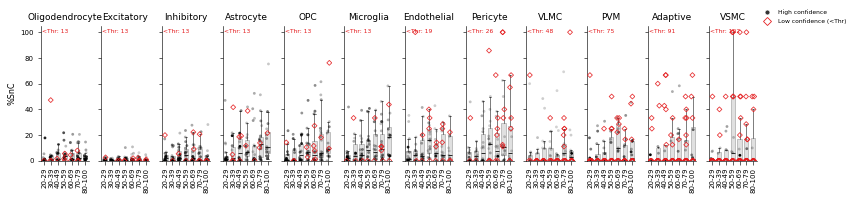


  ✓ Saved: psychad_aging_part0_qc_boxplot.pdf/.png

────────────────────────────────────────────────────────────
0.5 SUMMARY
────────────────────────────────────────────────────────────

  Threshold: max(P10, 10 cells) per cell type
  Point opacity reflects donor's proportional contribution to cell type
  Red diamonds (◇) = donors below threshold

  Interpretation:
    - Faded points = fewer cells → less reliable %SnC estimate
    - Solid points = more cells → more reliable %SnC estimate
    - Red diamonds = very few cells → interpret with caution

✓ Part 0 complete → Cell 5: Part 1A Analysis


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 0 - SAMPLE COMPOSITION QC
# ════════════════════════════════════════════════════════════════════════════════
#
# Quality control visualization for donor-celltype sampling depth.
# Identifies low-confidence observations where %SnC estimates may be unreliable.
#
# Output:
#   - Table: Per cell type sampling statistics
#   - Figure: Boxplot with confidence-weighted donor points
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 0: SAMPLE COMPOSITION QC")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# 0.1 Configuration
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("0.1 CONFIGURATION")
print(f"{'─'*60}")

# Low confidence threshold: donors below this percentile (within cell type)
LOW_CONF_PERCENTILE = 10

# Absolute minimum cells — catches rare cell types where P10 may be 0
MIN_CELLS_ABSOLUTE = 10

print(f"\n  Low confidence threshold: max(P{LOW_CONF_PERCENTILE}, {MIN_CELLS_ABSOLUTE} cells)")

# ─────────────────────────────────────────────────────────────────────────────────
# 0.2 Compute Confidence Metrics
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("0.2 CONFIDENCE METRICS")
print(f"{'─'*60}")

# Copy to avoid modifying original
df_qc = df_donor_ct.copy()

# Compute per-celltype statistics
ct_stats = df_qc.groupby(COL_CELLTYPE).agg(
    n_donors=(COL_DONOR, 'nunique'),
    total_cells=('n_cells', 'sum'),
    median_cells=('n_cells', 'median'),
    mean_cells=('n_cells', 'mean'),
    min_cells=('n_cells', 'min'),
    max_cells=('n_cells', 'max'),
    p10_cells=('n_cells', lambda x: np.percentile(x, LOW_CONF_PERCENTILE)),
    n_donors_zero=('n_cells', lambda x: (x == 0).sum()),
    n_donors_lt10=('n_cells', lambda x: (x < MIN_CELLS_ABSOLUTE).sum()),
    mean_prop_snc=('prop_snc', 'mean'),
    pct_zero=('prop_snc', lambda x: (x == 0).mean() * 100),
).reset_index()

# Compute hybrid threshold: max(P10, MIN_CELLS_ABSOLUTE)
ct_stats['threshold'] = ct_stats['p10_cells'].apply(
    lambda x: max(x, MIN_CELLS_ABSOLUTE)
)

# Compute confidence weight: donor contribution within cell type
df_qc['total_cells_ct'] = df_qc.groupby(COL_CELLTYPE)['n_cells'].transform('sum')
df_qc['donor_weight'] = df_qc['n_cells'] / df_qc['total_cells_ct']

# Scale alpha to visible range [0.15, 1.0]
df_qc['max_weight_ct'] = df_qc.groupby(COL_CELLTYPE)['donor_weight'].transform('max')
df_qc['alpha'] = 0.15 + 0.85 * (df_qc['donor_weight'] / df_qc['max_weight_ct'])

# Flag low confidence using HYBRID threshold: max(P10, MIN_CELLS_ABSOLUTE)
df_qc['p10_threshold'] = df_qc.groupby(COL_CELLTYPE)['n_cells'].transform(
    lambda x: np.percentile(x, LOW_CONF_PERCENTILE)
)
df_qc['threshold'] = df_qc['p10_threshold'].apply(lambda x: max(x, MIN_CELLS_ABSOLUTE))
df_qc['low_confidence'] = df_qc['n_cells'] < df_qc['threshold']

# Count low confidence per cell type
ct_stats = ct_stats.merge(
    df_qc.groupby(COL_CELLTYPE)['low_confidence'].sum().reset_index().rename(
        columns={'low_confidence': 'n_low_conf'}
    ),
    on=COL_CELLTYPE
)

print(f"\n  Computed for {df_qc[COL_CELLTYPE].nunique()} cell types")
print(f"  Total low-confidence observations: {df_qc['low_confidence'].sum()} / {len(df_qc)} ({df_qc['low_confidence'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────────
# 0.3 Summary Table
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("0.3 SUMMARY TABLE: SAMPLING DEPTH PER CELL TYPE")
print(f"{'─'*60}")

# Sort by total cells descending
ct_stats_sorted = ct_stats.sort_values('total_cells', ascending=False)

# Display table
print(f"\n  {'Cell Type':<18} {'N':>5} {'Total':>10} {'Median':>7} {'P10':>6} {'Thresh':>6} {'Min':>5} {'n=0':>5} {'<Thr':>5} {'%SnC':>6} {'%Zero':>6}")
print(f"  {'-'*95}")

for _, row in ct_stats_sorted.iterrows():
    print(f"  {row[COL_CELLTYPE]:<18} {row['n_donors']:>5} {row['total_cells']:>10,} {row['median_cells']:>7.0f} {row['p10_cells']:>6.0f} {row['threshold']:>6.0f} {row['min_cells']:>5.0f} {row['n_donors_zero']:>5.0f} {row['n_low_conf']:>5.0f} {row['mean_prop_snc']*100:>5.1f}% {row['pct_zero']:>5.1f}%")

print(f"\n  P10 = {LOW_CONF_PERCENTILE}th percentile | Thresh = max(P10, {MIN_CELLS_ABSOLUTE})")
print(f"  n=0 = donors with zero cells | <Thr = donors below threshold (low confidence)")

# ─────────────────────────────────────────────────────────────────────────────────
# 0.3.1 Warnings for problematic cell types
# ─────────────────────────────────────────────────────────────────────────────────

# Cell types where >50% of donors have <MIN_CELLS_ABSOLUTE cells
sparse_ct = ct_stats_sorted[ct_stats_sorted['n_donors_lt10'] > ct_stats_sorted['n_donors'] * 0.5]
if len(sparse_ct) > 0:
    print(f"\n  ⚠ SPARSE CELL TYPES (>50% donors with <{MIN_CELLS_ABSOLUTE} cells):")
    for _, row in sparse_ct.iterrows():
        pct = row['n_donors_lt10'] / row['n_donors'] * 100
        print(f"    {row[COL_CELLTYPE]}: {row['n_donors_lt10']:.0f}/{row['n_donors']} donors ({pct:.0f}%) — interpret with caution")

# Cell types where >20% of donors have zero cells
zero_heavy_ct = ct_stats_sorted[ct_stats_sorted['n_donors_zero'] > ct_stats_sorted['n_donors'] * 0.2]
if len(zero_heavy_ct) > 0:
    print(f"\n  ⚠ CELL TYPES WITH MANY ZERO-CELL DONORS (>20%):")
    for _, row in zero_heavy_ct.iterrows():
        pct = row['n_donors_zero'] / row['n_donors'] * 100
        print(f"    {row[COL_CELLTYPE]}: {row['n_donors_zero']:.0f}/{row['n_donors']} donors ({pct:.0f}%) have 0 cells")

# Export table
ct_stats_export = ct_stats_sorted[[
    COL_CELLTYPE, 'n_donors', 'total_cells', 'median_cells', 'mean_cells',
    'min_cells', 'max_cells', 'p10_cells', 'threshold', 'n_donors_zero', 
    'n_donors_lt10', 'n_low_conf', 'mean_prop_snc', 'pct_zero'
]].copy()
ct_stats_export.columns = [
    'Cell_Type', 'N_Donors', 'Total_Cells', 'Median_Cells', 'Mean_Cells',
    'Min_Cells', 'Max_Cells', 'P10_Cells', 'Threshold', 'N_Donors_Zero',
    'N_Donors_LT10', 'N_Low_Confidence', 'Mean_Prop_SnC', 'Pct_Zero_SnC'
]
ct_stats_export.to_csv(RESULTS_DIR / f'{DATASET}_part0_sampling_stats.csv', index=False)
print(f"\n  ✓ Saved: {DATASET}_part0_sampling_stats.csv")

# ─────────────────────────────────────────────────────────────────────────────────
# 0.4 Visualization: Confidence-Weighted Boxplot
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("0.4 CONFIDENCE-WEIGHTED BOXPLOT")
print(f"{'─'*60}")

# Visualization parameters
FONT_TITLE = 9
FONT_LABEL = 8
FONT_TICK = 7
FONT_ANNOT = 6
LW_AXIS = 0.6
LW_BOX = 0.5
MARKER_SIZE = 8
MARKER_SIZE_LOW = 12
DPI = 300

# Colors
COLOR_LOW_CONF = '#E41A1C'  # Red for low confidence
COLOR_BOX = '0.7'

# Get cell type order (by total cells, descending)
ct_order = ct_stats_sorted[COL_CELLTYPE].tolist()
n_ct = len(ct_order)

# Study group formatting
def format_sg_label(sg):
    """Format study group label for display."""
    if sg.startswith('Age_'):
        parts = sg.replace('Age_', '').split('_')
        if len(parts) == 2:
            return f"{parts[0]}-{parts[1]}"
        return sg.replace('Age_', '')
    return sg

sg_labels = [format_sg_label(sg) for sg in STUDY_GROUPS_ORDERED]
n_sg = len(STUDY_GROUPS_ORDERED)

# Figure layout: one row, columns = cell types
fig_width = min(1.0 * n_ct, 12)
fig_height = 2.8

fig, axes = plt.subplots(1, n_ct, figsize=(fig_width, fig_height), sharey=True)
if n_ct == 1:
    axes = [axes]

# Y-axis limit
y_max = df_qc['prop_snc'].max() * 100
y_lim = (0, np.ceil(y_max / 5) * 5 + 5)

for ct_idx, ct in enumerate(ct_order):
    ax = axes[ct_idx]
    df_ct = df_qc[df_qc[COL_CELLTYPE] == ct]
    
    # Plot boxplot for each study group
    box_positions = []
    box_data = []
    
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) > 0:
            box_positions.append(i)
            box_data.append(sg_data['prop_snc'].values * 100)
    
    # Draw boxplots
    if box_data:
        bp = ax.boxplot(
            box_data, 
            positions=box_positions,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=0.8),
            boxprops=dict(facecolor=COLOR_BOX, edgecolor='black', linewidth=LW_BOX, alpha=0.4),
            whiskerprops=dict(linewidth=LW_BOX, color='black'),
            capprops=dict(linewidth=LW_BOX, color='black'),
        )
    
    # Overlay jittered points with confidence-weighted alpha
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) == 0:
            continue
        
        # Jitter
        jitter = np.random.uniform(-0.18, 0.18, len(sg_data))
        
        # Separate high and low confidence
        high_conf = sg_data[~sg_data['low_confidence']]
        low_conf = sg_data[sg_data['low_confidence']]
        
        # High confidence points: alpha-weighted
        if len(high_conf) > 0:
            hc_jitter = jitter[~sg_data['low_confidence'].values]
            ax.scatter(
                i + hc_jitter,
                high_conf['prop_snc'].values * 100,
                s=MARKER_SIZE,
                c='black',
                alpha=high_conf['alpha'].values,
                edgecolors='none',
                zorder=3,
            )
        
        # Low confidence points: red diamonds
        if len(low_conf) > 0:
            lc_jitter = jitter[sg_data['low_confidence'].values]
            ax.scatter(
                i + lc_jitter,
                low_conf['prop_snc'].values * 100,
                s=MARKER_SIZE_LOW,
                c='none',
                edgecolors=COLOR_LOW_CONF,
                linewidths=0.8,
                marker='D',
                alpha=0.9,
                zorder=4,
            )
    
    # Formatting
    ax.set_title(ct, fontsize=FONT_TITLE, fontweight='medium')
    ax.set_xlim(-0.5, n_sg - 0.5)
    ax.set_ylim(y_lim)
    ax.set_xticks(range(n_sg))
    ax.set_xticklabels(sg_labels, fontsize=FONT_TICK, rotation=90)
    
    # Y-axis label only on first panel
    if ct_idx == 0:
        ax.set_ylabel('%SnC', fontsize=FONT_LABEL)
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(LW_AXIS)
    ax.spines['bottom'].set_linewidth(LW_AXIS)
    ax.tick_params(width=LW_AXIS, labelsize=FONT_TICK)
    
    # Annotate n low conf (TOP LEFT)
    n_low = df_ct['low_confidence'].sum()
    if n_low > 0:
        ax.text(
            0.02, 0.98, f'<Thr: {n_low}',
            transform=ax.transAxes,
            fontsize=FONT_ANNOT,
            ha='left', va='top',
            color=COLOR_LOW_CONF,
        )

# Legend (right side, outside plot area)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=5, alpha=0.8, label='High confidence'),
    Line2D([0], [0], marker='D', color='w', markeredgecolor=COLOR_LOW_CONF, markerfacecolor='none', markersize=5, markeredgewidth=0.8, label=f'Low confidence (<Thr)'),
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.99, 0.99),
    fontsize=FONT_ANNOT,
    frameon=True,
    framealpha=0.9,
    edgecolor='none',
)

plt.tight_layout()
plt.subplots_adjust(right=0.88)

# Save
plt.savefig(FIGURES_DIR / f'{DATASET}_part0_qc_boxplot.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part0_qc_boxplot.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n  ✓ Saved: {DATASET}_part0_qc_boxplot.pdf/.png")

# ─────────────────────────────────────────────────────────────────────────────────
# 0.5 Summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("0.5 SUMMARY")
print(f"{'─'*60}")

print(f"\n  Threshold: max(P{LOW_CONF_PERCENTILE}, {MIN_CELLS_ABSOLUTE} cells) per cell type")
print(f"  Point opacity reflects donor's proportional contribution to cell type")
print(f"  Red diamonds (◇) = donors below threshold")

print(f"\n  Interpretation:")
print(f"    - Faded points = fewer cells → less reliable %SnC estimate")
print(f"    - Solid points = more cells → more reliable %SnC estimate")
print(f"    - Red diamonds = very few cells → interpret with caution")

print(f"\n{'='*60}")
print(f"✓ Part 0 complete → Cell 5: Part 1A Analysis")
print(f"{'='*60}")

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 1A - CELL-LEVEL OVERALL
# ════════════════════════════════════════════════════════════════════════════════
#
# Logistic GLMM with two link functions:
#   - Logit: exp(β) = Odds Ratio (OR)
#   - Cloglog: exp(β) ≈ Relative Risk (RR) for rare events
#
# Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1A: CELL-LEVEL OVERALL")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Prepare data for R
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Preparing data...")

df_model = df_cells[[COL_SENESCENT, 'Age_scaled', COL_SEX, COL_COHORT, COL_DONOR]].copy()
df_model.columns = ['is_senescent', 'Age_scaled', 'Sex', 'Cohort', 'Donor']

print(f"  N cells: {len(df_model):,}")
print(f"  N donors: {df_model['Donor'].nunique()}")
print(f"  N senescent: {df_model['is_senescent'].sum():,} ({df_model['is_senescent'].mean()*100:.1f}%)")

# Transfer to R
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['df_model'] = ro.conversion.py2rpy(df_model)

# ─────────────────────────────────────────────────────────────────────────────
# Fit Logistic GLMM with LOGIT link
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Fitting Logistic GLMM (LOGIT link)...")
print("  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)")

r_code_logit = """
library(lme4)

tryCatch({
    model <- glmer(
        is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
        data = df_model,
        family = binomial(link = "logit"),
        control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 100000))
    )
    
    summ <- summary(model)
    coef_df <- as.data.frame(summ$coefficients)
    
    # Add exp(beta) and CI
    coef_df$exp_beta <- exp(coef_df$Estimate)
    coef_df$exp_beta_lower <- exp(coef_df$Estimate - 1.96 * coef_df$`Std. Error`)
    coef_df$exp_beta_upper <- exp(coef_df$Estimate + 1.96 * coef_df$`Std. Error`)
    
    re_var <- as.data.frame(VarCorr(model))$vcov[1]
    
    list(
        success = TRUE,
        coefficients = coef_df,
        re_variance = re_var,
        n_obs = nrow(df_model),
        n_donors = length(unique(df_model$Donor)),
        converged = model@optinfo$conv$opt == 0
    )
}, error = function(e) {
    list(success = FALSE, error = as.character(e))
})
"""

try:
    result_logit = ro.r(r_code_logit)
    
    if result_logit.rx2('success')[0]:
        with localconverter(ro.default_converter + pandas2ri.converter):
            coef_logit = ro.conversion.rpy2py(result_logit.rx2('coefficients'))
        
        re_var_logit = result_logit.rx2('re_variance')[0]
        converged_logit = bool(result_logit.rx2('converged')[0])
        
        print(f"  ✓ Model {'converged' if converged_logit else 'WARNING: did not converge'}")
        print(f"  Random effect variance: {re_var_logit:.4f}")
        
        # Extract age effect
        age_row_logit = coef_logit.loc['Age_scaled']
        or_val = age_row_logit['exp_beta']
        or_lo = age_row_logit['exp_beta_lower']
        or_hi = age_row_logit['exp_beta_upper']
        p_logit = age_row_logit['Pr(>|z|)']
        
        sig = '***' if p_logit < 0.001 else '**' if p_logit < 0.01 else '*' if p_logit < 0.05 else ''
        direction = '↑' if or_val > 1 else '↓'
        
        print(f"\n  Age effect (OR): {or_val:.3f} (95% CI: {or_lo:.3f} - {or_hi:.3f}) {direction}")
        print(f"  p = {p_logit:.2e} {sig}")
        
        results_1a_logit = {
            'coefficients': coef_logit,
            're_variance': re_var_logit,
            'converged': converged_logit,
        }
    else:
        print(f"  ✗ Model failed: {result_logit.rx2('error')[0]}")
        results_1a_logit = None
        
except Exception as e:
    print(f"  ✗ Error: {e}")
    results_1a_logit = None

# ─────────────────────────────────────────────────────────────────────────────
# Fit Logistic GLMM with CLOGLOG link
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Fitting Logistic GLMM (CLOGLOG link)...")
print("  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)")

r_code_cloglog = """
library(lme4)

tryCatch({
    model <- glmer(
        is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
        data = df_model,
        family = binomial(link = "cloglog"),
        control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 100000))
    )
    
    summ <- summary(model)
    coef_df <- as.data.frame(summ$coefficients)
    
    # Add exp(beta) and CI
    coef_df$exp_beta <- exp(coef_df$Estimate)
    coef_df$exp_beta_lower <- exp(coef_df$Estimate - 1.96 * coef_df$`Std. Error`)
    coef_df$exp_beta_upper <- exp(coef_df$Estimate + 1.96 * coef_df$`Std. Error`)
    
    re_var <- as.data.frame(VarCorr(model))$vcov[1]
    
    list(
        success = TRUE,
        coefficients = coef_df,
        re_variance = re_var,
        n_obs = nrow(df_model),
        n_donors = length(unique(df_model$Donor)),
        converged = model@optinfo$conv$opt == 0
    )
}, error = function(e) {
    list(success = FALSE, error = as.character(e))
})
"""

try:
    result_cloglog = ro.r(r_code_cloglog)
    
    if result_cloglog.rx2('success')[0]:
        with localconverter(ro.default_converter + pandas2ri.converter):
            coef_cloglog = ro.conversion.rpy2py(result_cloglog.rx2('coefficients'))
        
        re_var_cloglog = result_cloglog.rx2('re_variance')[0]
        converged_cloglog = bool(result_cloglog.rx2('converged')[0])
        
        print(f"  ✓ Model {'converged' if converged_cloglog else 'WARNING: did not converge'}")
        print(f"  Random effect variance: {re_var_cloglog:.4f}")
        
        # Extract age effect
        age_row_cloglog = coef_cloglog.loc['Age_scaled']
        rr_val = age_row_cloglog['exp_beta']
        rr_lo = age_row_cloglog['exp_beta_lower']
        rr_hi = age_row_cloglog['exp_beta_upper']
        p_cloglog = age_row_cloglog['Pr(>|z|)']
        
        sig = '***' if p_cloglog < 0.001 else '**' if p_cloglog < 0.01 else '*' if p_cloglog < 0.05 else ''
        direction = '↑' if rr_val > 1 else '↓'
        
        print(f"\n  Age effect (RR): {rr_val:.3f} (95% CI: {rr_lo:.3f} - {rr_hi:.3f}) {direction}")
        print(f"  p = {p_cloglog:.2e} {sig}")
        
        results_1a_cloglog = {
            'coefficients': coef_cloglog,
            're_variance': re_var_cloglog,
            'converged': converged_cloglog,
        }
    else:
        print(f"  ✗ Model failed: {result_cloglog.rx2('error')[0]}")
        results_1a_cloglog = None
        
except Exception as e:
    print(f"  ✗ Error: {e}")
    results_1a_cloglog = None

# ─────────────────────────────────────────────────────────────────────────────
# Store combined results
# ─────────────────────────────────────────────────────────────────────────────

results_1a = {
    'logit': results_1a_logit,
    'cloglog': results_1a_cloglog,
    'n_obs': len(df_model),
    'n_donors': df_model['Donor'].nunique(),
}

# ─────────────────────────────────────────────────────────────────────────────
# Summary comparison
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("COMPARISON: LOGIT vs CLOGLOG")
print(f"{'─'*60}")

print(f"\n  {'Link':<10} {'exp(β)':<10} {'95% CI':<20} {'p-value':<12} {'Interpretation'}")
print(f"  {'-'*10} {'-'*10} {'-'*20} {'-'*12} {'-'*20}")

if results_1a_logit is not None:
    row = results_1a_logit['coefficients'].loc['Age_scaled']
    ci_str = f"({row['exp_beta_lower']:.3f} - {row['exp_beta_upper']:.3f})"
    print(f"  {'Logit':<10} {row['exp_beta']:.3f}     {ci_str:<20} {row['Pr(>|z|)']:.2e}   OR per decade")

if results_1a_cloglog is not None:
    row = results_1a_cloglog['coefficients'].loc['Age_scaled']
    ci_str = f"({row['exp_beta_lower']:.3f} - {row['exp_beta_upper']:.3f})"
    print(f"  {'Cloglog':<10} {row['exp_beta']:.3f}     {ci_str:<20} {row['Pr(>|z|)']:.2e}   RR per decade")

print(f"\n  Note: Cloglog exp(β) ≈ Relative Risk when outcome is rare (<10%)")

print(f"\n✓ Part 1A complete → Cell 5: Part 1B Analysis")

PART 1A: CELL-LEVEL OVERALL

▸ Preparing data...
  N cells: 544,780
  N donors: 124
  N senescent: 25,358 (4.7%)

▸ Fitting Logistic GLMM (LOGIT link)...
  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
  ✓ Model converged
  Random effect variance: 2.6279

  Age effect (OR): 1.156 (95% CI: 0.969 - 1.378) ↑
  p = 1.06e-01 

▸ Fitting Logistic GLMM (CLOGLOG link)...
  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
  ✓ Model converged
  Random effect variance: 2.5148

  Age effect (RR): 1.155 (95% CI: 0.972 - 1.372) ↑
  p = 1.01e-01 

────────────────────────────────────────────────────────────
COMPARISON: LOGIT vs CLOGLOG
────────────────────────────────────────────────────────────

  Link       exp(β)     95% CI               p-value      Interpretation
  ---------- ---------- -------------------- ------------ --------------------
  Logit      1.156     (0.969 - 1.378)      1.06e-01   OR per decade
  Cloglog    1.155     (0.972 - 1.372)      1.01e-01   RR p

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 1B - CELL-LEVEL PER CELL TYPE
# ════════════════════════════════════════════════════════════════════════════════
#
# Logistic GLMM per cell type with both link functions:
#   - Logit: exp(β) = Odds Ratio (OR)
#   - Cloglog: exp(β) ≈ Relative Risk (RR)
#
# Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1B: CELL-LEVEL PER CELL TYPE")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Identify eligible cell types
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Checking cell types...")

ct_stats = df_cells.groupby(COL_CELLTYPE).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    n_donors=(COL_DONOR, 'nunique'),
).reset_index()

ct_stats['pct_snc'] = ct_stats['n_snc'] / ct_stats['n_cells'] * 100

print(f"\n  {'Cell Type':<20} {'Cells':>10} {'SnC':>8} {'%SnC':>8} {'Donors':>8} {'Status':<10}")
print(f"  {'-'*20} {'-'*10} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")

eligible_cts = []
for _, row in ct_stats.iterrows():
    ct = row[COL_CELLTYPE]
    n_cells = row['n_cells']
    n_snc = row['n_snc']
    pct = row['pct_snc']
    n_donors = row['n_donors']
    
    if n_cells < MIN_CELLS:
        status = "few cells"
    elif n_donors < MIN_DONORS:
        status = "few donors"
    elif n_snc == 0:
        status = "no SnC"
    else:
        status = "✓"
        eligible_cts.append(ct)
    
    print(f"  {ct:<20} {n_cells:>10,} {n_snc:>8,} {pct:>7.1f}% {n_donors:>8} {status:<10}")

print(f"\n  Eligible: {len(eligible_cts)}/{len(ct_stats)} cell types")

# ─────────────────────────────────────────────────────────────────────────────
# Helper function to fit GLMM
# ─────────────────────────────────────────────────────────────────────────────

def fit_glmm_celltype(ct, link='logit'):
    """Fit GLMM for a single cell type with specified link function."""
    
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct].copy()
    
    df_model = df_ct[[COL_SENESCENT, 'Age_scaled', COL_SEX, COL_COHORT, COL_DONOR]].copy()
    df_model.columns = ['is_senescent', 'Age_scaled', 'Sex', 'Cohort', 'Donor']
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['df_model'] = ro.conversion.py2rpy(df_model)
    
    r_code = f"""
    tryCatch({{
        model <- glmer(
            is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
            data = df_model,
            family = binomial(link = "{link}"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 50000))
        )
        
        summ <- summary(model)
        coef_df <- as.data.frame(summ$coefficients)
        age_row <- coef_df["Age_scaled", ]
        
        list(
            success = TRUE,
            estimate = age_row$Estimate,
            se = age_row$`Std. Error`,
            z = age_row$`z value`,
            p = age_row$`Pr(>|z|)`,
            exp_beta = exp(age_row$Estimate),
            exp_beta_lower = exp(age_row$Estimate - 1.96 * age_row$`Std. Error`),
            exp_beta_upper = exp(age_row$Estimate + 1.96 * age_row$`Std. Error`)
        )
    }}, error = function(e) {{
        list(success = FALSE, error = as.character(e))
    }})
    """
    
    try:
        result = ro.r(r_code)
        
        if result.rx2('success')[0]:
            return {
                'estimate': result.rx2('estimate')[0],
                'se': result.rx2('se')[0],
                'z': result.rx2('z')[0],
                'p': result.rx2('p')[0],
                'exp_beta': result.rx2('exp_beta')[0],
                'exp_beta_lower': result.rx2('exp_beta_lower')[0],
                'exp_beta_upper': result.rx2('exp_beta_upper')[0],
            }
        else:
            return None
    except:
        return None

# ─────────────────────────────────────────────────────────────────────────────
# Fit models for each cell type
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n▸ Fitting models for each cell type...")

results_1b_list = []

for ct in eligible_cts:
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct]
    
    row_data = {
        COL_CELLTYPE: ct,
        'n_cells': len(df_ct),
        'n_snc': df_ct[COL_SENESCENT].sum(),
        'pct_snc': df_ct[COL_SENESCENT].mean() * 100,
        'n_donors': df_ct[COL_DONOR].nunique(),
    }
    
    # Fit LOGIT
    res_logit = fit_glmm_celltype(ct, link='logit')
    if res_logit is not None:
        row_data['logit_Estimate'] = res_logit['estimate']
        row_data['logit_SE'] = res_logit['se']
        row_data['logit_z'] = res_logit['z']
        row_data['logit_P'] = res_logit['p']
        row_data['logit_exp_beta'] = res_logit['exp_beta']
        row_data['logit_exp_beta_lower'] = res_logit['exp_beta_lower']
        row_data['logit_exp_beta_upper'] = res_logit['exp_beta_upper']
    else:
        row_data['logit_Estimate'] = np.nan
        row_data['logit_SE'] = np.nan
        row_data['logit_z'] = np.nan
        row_data['logit_P'] = np.nan
        row_data['logit_exp_beta'] = np.nan
        row_data['logit_exp_beta_lower'] = np.nan
        row_data['logit_exp_beta_upper'] = np.nan
    
    # Fit CLOGLOG
    res_cloglog = fit_glmm_celltype(ct, link='cloglog')
    if res_cloglog is not None:
        row_data['cloglog_Estimate'] = res_cloglog['estimate']
        row_data['cloglog_SE'] = res_cloglog['se']
        row_data['cloglog_z'] = res_cloglog['z']
        row_data['cloglog_P'] = res_cloglog['p']
        row_data['cloglog_exp_beta'] = res_cloglog['exp_beta']
        row_data['cloglog_exp_beta_lower'] = res_cloglog['exp_beta_lower']
        row_data['cloglog_exp_beta_upper'] = res_cloglog['exp_beta_upper']
    else:
        row_data['cloglog_Estimate'] = np.nan
        row_data['cloglog_SE'] = np.nan
        row_data['cloglog_z'] = np.nan
        row_data['cloglog_P'] = np.nan
        row_data['cloglog_exp_beta'] = np.nan
        row_data['cloglog_exp_beta_lower'] = np.nan
        row_data['cloglog_exp_beta_upper'] = np.nan
    
    results_1b_list.append(row_data)
    
    # Print progress
    logit_str = f"OR={res_logit['exp_beta']:.2f}" if res_logit else "failed"
    cloglog_str = f"RR={res_cloglog['exp_beta']:.2f}" if res_cloglog else "failed"
    print(f"  {ct}: Logit {logit_str}, Cloglog {cloglog_str}")

# ─────────────────────────────────────────────────────────────────────────────
# Create results dataframe
# ─────────────────────────────────────────────────────────────────────────────

df_results_1b = pd.DataFrame(results_1b_list)

# FDR correction for LOGIT
valid_logit = ~df_results_1b['logit_P'].isna()
if valid_logit.sum() > 0:
    df_results_1b.loc[valid_logit, 'logit_P_adj'] = stats.false_discovery_control(
        df_results_1b.loc[valid_logit, 'logit_P'], method='bh'
    )
else:
    df_results_1b['logit_P_adj'] = np.nan

# FDR correction for CLOGLOG
valid_cloglog = ~df_results_1b['cloglog_P'].isna()
if valid_cloglog.sum() > 0:
    df_results_1b.loc[valid_cloglog, 'cloglog_P_adj'] = stats.false_discovery_control(
        df_results_1b.loc[valid_cloglog, 'cloglog_P'], method='bh'
    )
else:
    df_results_1b['cloglog_P_adj'] = np.nan

# Sort by logit exp_beta
df_results_1b = df_results_1b.sort_values('logit_exp_beta', ascending=False)

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY: LOGIT (Odds Ratio)")
print(f"{'─'*60}")

n_pos_logit = (df_results_1b['logit_exp_beta'] > 1).sum()
n_sig_nom_logit = (df_results_1b['logit_P'] < 0.05).sum()
n_sig_fdr_logit = (df_results_1b['logit_P_adj'] < 0.05).sum()

print(f"\n  Cell types analyzed: {len(df_results_1b)}")
print(f"  Positive age effect (OR > 1): {n_pos_logit}")
print(f"  Significant (p < 0.05): {n_sig_nom_logit}")
print(f"  Significant (FDR < 0.05): {n_sig_fdr_logit}")

print(f"\n{'─'*60}")
print("SUMMARY: CLOGLOG (Relative Risk)")
print(f"{'─'*60}")

n_pos_cloglog = (df_results_1b['cloglog_exp_beta'] > 1).sum()
n_sig_nom_cloglog = (df_results_1b['cloglog_P'] < 0.05).sum()
n_sig_fdr_cloglog = (df_results_1b['cloglog_P_adj'] < 0.05).sum()

print(f"\n  Cell types analyzed: {len(df_results_1b)}")
print(f"  Positive age effect (RR > 1): {n_pos_cloglog}")
print(f"  Significant (p < 0.05): {n_sig_nom_cloglog}")
print(f"  Significant (FDR < 0.05): {n_sig_fdr_cloglog}")

# ─────────────────────────────────────────────────────────────────────────────
# Display results table
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("RESULTS BY CELL TYPE")
print(f"{'─'*60}\n")

display_cols = [COL_CELLTYPE, 'pct_snc', 
                'logit_exp_beta', 'logit_P', 'logit_P_adj',
                'cloglog_exp_beta', 'cloglog_P', 'cloglog_P_adj']

df_display = df_results_1b[display_cols].copy()
df_display['pct_snc'] = df_display['pct_snc'].round(1)
df_display['logit_exp_beta'] = df_display['logit_exp_beta'].round(3)
df_display['cloglog_exp_beta'] = df_display['cloglog_exp_beta'].round(3)
df_display['logit_P'] = df_display['logit_P'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['logit_P_adj'] = df_display['logit_P_adj'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['cloglog_P'] = df_display['cloglog_P'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['cloglog_P_adj'] = df_display['cloglog_P_adj'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")

df_display.columns = [COL_CELLTYPE, '%SnC', 'OR', 'P', 'FDR', 'RR', 'P', 'FDR']

print(df_display.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Highlight FDR-significant cell types
# ─────────────────────────────────────────────────────────────────────────────

if n_sig_fdr_logit > 0:
    print(f"\n  FDR-significant (Logit):")
    sig_cts = df_results_1b[df_results_1b['logit_P_adj'] < 0.05]
    for _, row in sig_cts.iterrows():
        direction = '↑' if row['logit_exp_beta'] > 1 else '↓'
        print(f"    {row[COL_CELLTYPE]}: OR={row['logit_exp_beta']:.2f} {direction} (FDR={row['logit_P_adj']:.3f})")

if n_sig_fdr_cloglog > 0:
    print(f"\n  FDR-significant (Cloglog):")
    sig_cts = df_results_1b[df_results_1b['cloglog_P_adj'] < 0.05]
    for _, row in sig_cts.iterrows():
        direction = '↑' if row['cloglog_exp_beta'] > 1 else '↓'
        print(f"    {row[COL_CELLTYPE]}: RR={row['cloglog_exp_beta']:.2f} {direction} (FDR={row['cloglog_P_adj']:.3f})")

print(f"\n✓ Part 1B complete → Cell 6: Part 1 Visualization")

PART 1B: CELL-LEVEL PER CELL TYPE

▸ Checking cell types...

  Cell Type                 Cells      SnC     %SnC   Donors Status    
  -------------------- ---------- -------- -------- -------- ----------
  Adaptive                    883       92    10.4%      102 ✓         
  Astrocyte                63,658    6,544    10.3%      124 ✓         
  Endothelial               7,501      506     6.7%      123 ✓         
  Excitatory              121,182      905     0.7%      123 ✓         
  Inhibitory               90,648    3,437     3.8%      124 ✓         
  Microglia                22,475    2,233     9.9%      124 ✓         
  OPC                      36,059    3,240     9.0%      124 ✓         
  Oligodendrocyte         193,310    7,715     4.0%      124 ✓         
  PVM                       1,150      111     9.7%      110 ✓         
  Pericyte                  4,136      306     7.4%      123 ✓         
  VLMC                      2,991      206     6.9%      120 ✓         
  V

PART 1 VISUALIZATION

▸ Figure 1: Part 1A Overall Forest Plot


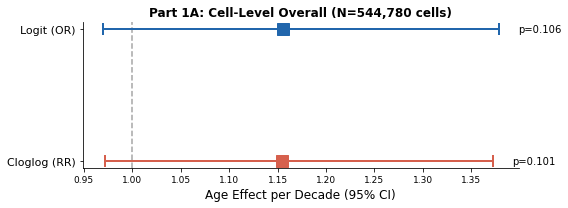

  ✓ Saved: part1a_forest_overall.svg

▸ Figure 2: Part 1B Forest Plot (Logit)


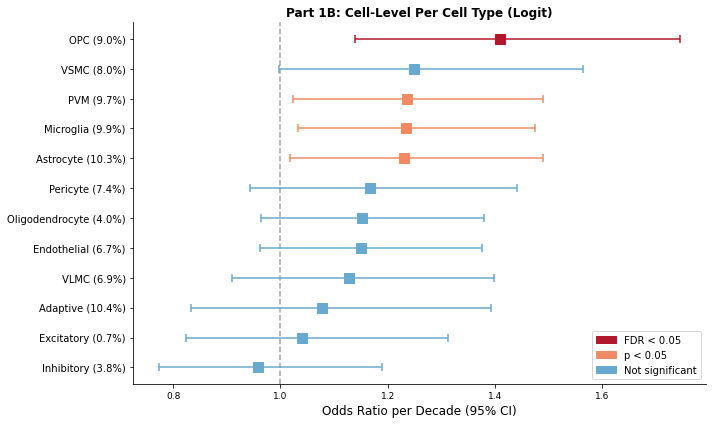

  ✓ Saved: part1b_forest_logit.svg

▸ Figure 3: Part 1B Forest Plot (Cloglog)


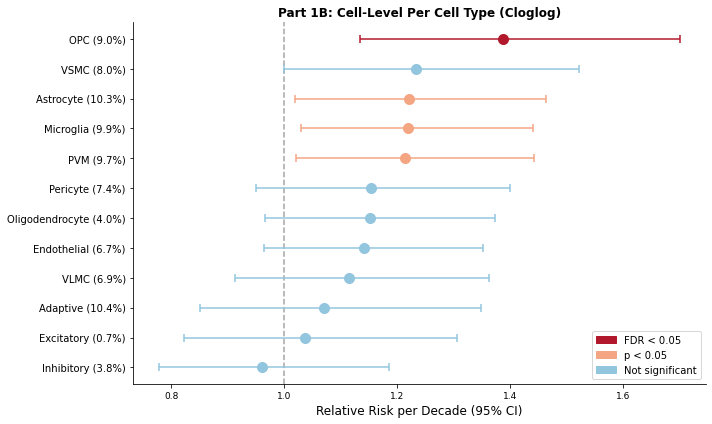

  ✓ Saved: part1b_forest_cloglog.svg

▸ Figure 4: Part 1A Predicted Probability Curve


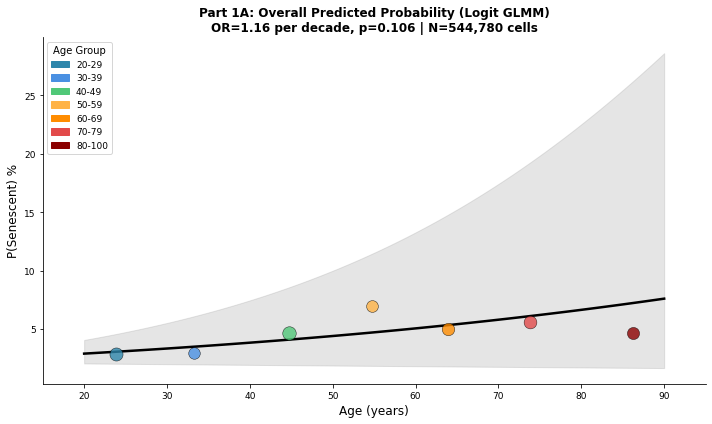

  ✓ Saved: part1a_predicted_prob.svg

▸ Figure 5: Part 1B Predicted Probability Curves (All Cell Types)


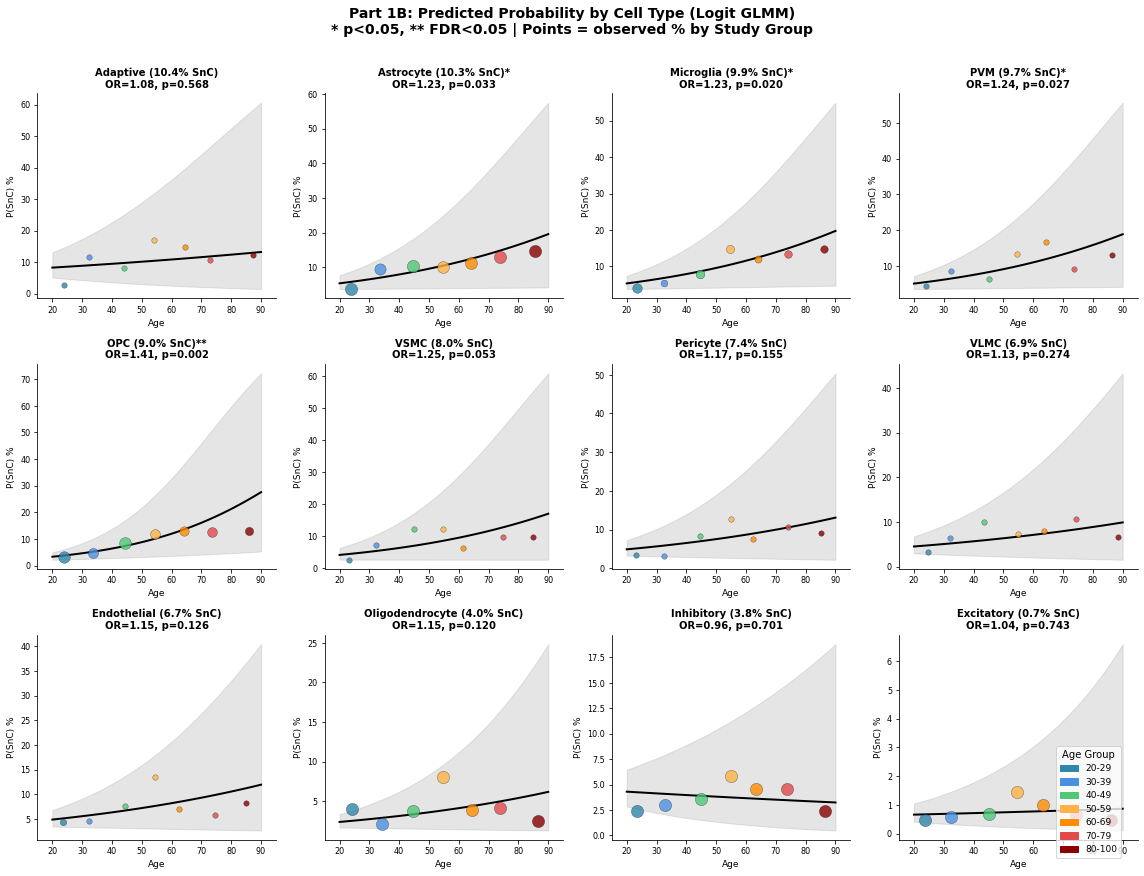

  ✓ Saved: part1b_predicted_prob_all.svg

PART 1 VISUALIZATION COMPLETE

Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging
  1. part1a_forest_overall.svg - Logit vs Cloglog comparison
  2. part1b_forest_logit.svg - Per cell type (OR)
  3. part1b_forest_cloglog.svg - Per cell type (RR)
  4. part1a_predicted_prob.svg - Overall probability curve
  5. part1b_predicted_prob_all.svg - Per cell type probability curves

✓ Part 1 complete → Cell 7: Part 2A Analysis


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 1 VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Figures:
#   1. Forest plot - Part 1A overall (logit vs cloglog)
#   2. Forest plot - Part 1B per cell type (logit)
#   3. Forest plot - Part 1B per cell type (cloglog)
#   4. Predicted probability curve - Part 1A overall
#   5. Predicted probability curves - All cell types
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1 VISUALIZATION")
print("="*60)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plot settings
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Age range for predictions
age_min = df_cells[COL_AGE].min()
age_max = df_cells[COL_AGE].max()
age_range = np.linspace(age_min, age_max, 100)
age_scaled_range = age_range / AGE_SCALE

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Forest Plot - Part 1A Overall (Logit vs Cloglog)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 1: Part 1A Overall Forest Plot")

fig, ax = plt.subplots(figsize=(8, 3))

y_pos = [1, 0]
labels = ['Logit (OR)', 'Cloglog (RR)']
colors_link = ['#2166AC', '#D6604D']

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, link in enumerate(['logit', 'cloglog']):
    if results_1a[link] is not None:
        row = results_1a[link]['coefficients'].loc['Age_scaled']
        est = row['exp_beta']
        lo = row['exp_beta_lower']
        hi = row['exp_beta_upper']
        p = row['Pr(>|z|)']
        
        ax.errorbar(est, y_pos[i], xerr=[[est-lo], [hi-est]], 
                    fmt='s', color=colors_link[i], capsize=6, markersize=12, 
                    capthick=2, elinewidth=2)
        
        sig = "*" if p < 0.05 else ""
        ax.annotate(f'p={p:.3f}{sig}', (hi + 0.02, y_pos[i]), fontsize=10, va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Age Effect per Decade (95% CI)', fontsize=12)
ax.set_title(f'Part 1A: Cell-Level Overall (N={len(df_cells):,} cells)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1a_forest_overall.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1a_forest_overall.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Forest Plot - Part 1B Per Cell Type (Logit)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 2: Part 1B Forest Plot (Logit)")

fig, ax = plt.subplots(figsize=(10, max(6, len(df_results_1b) * 0.5)))

df_plot = df_results_1b.sort_values('logit_Estimate', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_plot))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, (_, row) in enumerate(df_plot.iterrows()):
    if np.isnan(row.get('logit_P', np.nan)):
        continue
        
    fdr = row.get('logit_P_adj', 1)
    if fdr < 0.05:
        color = '#B2182B'  # FDR significant
    elif row['logit_P'] < 0.05:
        color = '#EF8A62'  # Nominally significant
    else:
        color = '#67A9CF'  # Not significant
    
    est = row['logit_exp_beta']
    lo = row['logit_exp_beta_lower']
    hi = row['logit_exp_beta_upper']
    
    ax.errorbar(est, i, xerr=[[est-lo], [hi-est]], 
                fmt='s', color=color, capsize=4, markersize=10, 
                capthick=1.5, elinewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row[COL_CELLTYPE]} ({row['pct_snc']:.1f}%)" for _, row in df_plot.iterrows()], fontsize=10)
ax.set_xlabel('Odds Ratio per Decade (95% CI)', fontsize=12)
ax.set_title('Part 1B: Cell-Level Per Cell Type (Logit)', fontsize=12, fontweight='bold')

# Legend
fdr_patch = mpatches.Patch(color='#B2182B', label='FDR < 0.05')
nom_patch = mpatches.Patch(color='#EF8A62', label='p < 0.05')
ns_patch = mpatches.Patch(color='#67A9CF', label='Not significant')
ax.legend(handles=[fdr_patch, nom_patch, ns_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_forest_logit.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_forest_logit.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Forest Plot - Part 1B Per Cell Type (Cloglog)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 3: Part 1B Forest Plot (Cloglog)")

fig, ax = plt.subplots(figsize=(10, max(6, len(df_results_1b) * 0.5)))

df_plot = df_results_1b.sort_values('cloglog_Estimate', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_plot))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, (_, row) in enumerate(df_plot.iterrows()):
    if np.isnan(row.get('cloglog_P', np.nan)):
        continue
        
    fdr = row.get('cloglog_P_adj', 1)
    if fdr < 0.05:
        color = '#B2182B'
    elif row['cloglog_P'] < 0.05:
        color = '#F4A582'
    else:
        color = '#92C5DE'
    
    est = row['cloglog_exp_beta']
    lo = row['cloglog_exp_beta_lower']
    hi = row['cloglog_exp_beta_upper']
    
    ax.errorbar(est, i, xerr=[[est-lo], [hi-est]], 
                fmt='o', color=color, capsize=4, markersize=10, 
                capthick=1.5, elinewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row[COL_CELLTYPE]} ({row['pct_snc']:.1f}%)" for _, row in df_plot.iterrows()], fontsize=10)
ax.set_xlabel('Relative Risk per Decade (95% CI)', fontsize=12)
ax.set_title('Part 1B: Cell-Level Per Cell Type (Cloglog)', fontsize=12, fontweight='bold')

fdr_patch = mpatches.Patch(color='#B2182B', label='FDR < 0.05')
nom_patch = mpatches.Patch(color='#F4A582', label='p < 0.05')
ns_patch = mpatches.Patch(color='#92C5DE', label='Not significant')
ax.legend(handles=[fdr_patch, nom_patch, ns_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_forest_cloglog.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_forest_cloglog.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Predicted Probability Curve - Part 1A Overall
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 4: Part 1A Predicted Probability Curve")

fig, ax = plt.subplots(figsize=(10, 6))

# Get coefficients (logit)
baseline_prop = df_cells[COL_SENESCENT].mean()
beta_age = results_1a['logit']['coefficients'].loc['Age_scaled', 'Estimate']
se_age = results_1a['logit']['coefficients'].loc['Age_scaled', 'Std. Error']
mean_age_scaled = df_cells['Age_scaled'].mean()

# Estimate intercept
intercept = np.log(baseline_prop / (1 - baseline_prop)) - beta_age * mean_age_scaled

# Predicted probability
eta = intercept + beta_age * age_scaled_range
prob = 1 / (1 + np.exp(-eta))

# CI
eta_lo = intercept + (beta_age - 1.96 * se_age) * age_scaled_range
eta_hi = intercept + (beta_age + 1.96 * se_age) * age_scaled_range
prob_lo = 1 / (1 + np.exp(-eta_lo))
prob_hi = 1 / (1 + np.exp(-eta_hi))

# Plot prediction line and CI
ax.fill_between(age_range, prob_lo * 100, prob_hi * 100, alpha=0.2, color='gray')
ax.plot(age_range, prob * 100, color='black', linewidth=2.5, label='Model prediction')

# Plot observed points by Study_Group
for sg in STUDY_GROUPS_ORDERED:
    mask = df_cells[COL_STUDYGROUP] == sg
    if mask.sum() > 0:
        n_cells_grp = mask.sum()
        n_snc_grp = df_cells.loc[mask, COL_SENESCENT].sum()
        pct_snc = n_snc_grp / n_cells_grp * 100
        midpoint_age = df_cells.loc[mask, COL_AGE].mean()
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        size = min(300, max(80, n_cells_grp / 500))
        ax.scatter(midpoint_age, pct_snc, s=size, color=color, 
                   edgecolors='black', linewidths=0.5, alpha=0.8, zorder=5)

# Get p-value and OR for annotation
p_val = results_1a['logit']['coefficients'].loc['Age_scaled', 'Pr(>|z|)']
or_val = results_1a['logit']['coefficients'].loc['Age_scaled', 'exp_beta']

# Legend for Study Groups
legend_patches = [mpatches.Patch(color=STUDY_GROUP_COLORS.get(sg, 'gray'), 
                                  label=sg.replace('Age_', '').replace('_', '-'))
                  for sg in STUDY_GROUPS_ORDERED]
ax.legend(handles=legend_patches, title='Age Group', loc='upper left', fontsize=9, title_fontsize=10)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('P(Senescent) %', fontsize=12)
ax.set_xlim(age_min - 5, age_max + 5)
ax.set_title(f'Part 1A: Overall Predicted Probability (Logit GLMM)\n'
             f'OR={or_val:.2f} per decade, p={p_val:.3f} | N={len(df_cells):,} cells', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1a_predicted_prob.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1a_predicted_prob.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 5: Predicted Probability Curves - All Cell Types
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 5: Part 1B Predicted Probability Curves (All Cell Types)")

# Sort by % SnC descending
ct_order = df_results_1b.sort_values('pct_snc', ascending=False)[COL_CELLTYPE].tolist()
n_cts = len(ct_order)

n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order):
    ax = axes[idx]
    
    row = df_results_1b[df_results_1b[COL_CELLTYPE] == ct].iloc[0]
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct]
    baseline_prop_ct = df_ct[COL_SENESCENT].mean()
    
    # Skip if no valid coefficients
    if np.isnan(row.get('logit_Estimate', np.nan)):
        ax.text(0.5, 0.5, 'Model failed', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(ct, fontsize=10, fontweight='bold')
        continue
    
    beta_age_ct = row['logit_Estimate']
    se_age_ct = row['logit_SE']
    
    # Estimate intercept
    mean_age_scaled_ct = df_ct['Age_scaled'].mean()
    if baseline_prop_ct > 0 and baseline_prop_ct < 1:
        intercept_ct = np.log(baseline_prop_ct / (1 - baseline_prop_ct)) - beta_age_ct * mean_age_scaled_ct
        
        # Predicted probability
        eta_ct = intercept_ct + beta_age_ct * age_scaled_range
        prob_ct = 1 / (1 + np.exp(-eta_ct))
        
        # CI
        eta_lo_ct = intercept_ct + (beta_age_ct - 1.96 * se_age_ct) * age_scaled_range
        eta_hi_ct = intercept_ct + (beta_age_ct + 1.96 * se_age_ct) * age_scaled_range
        prob_lo_ct = 1 / (1 + np.exp(-eta_lo_ct))
        prob_hi_ct = 1 / (1 + np.exp(-eta_hi_ct))
        
        ax.fill_between(age_range, prob_lo_ct * 100, prob_hi_ct * 100, alpha=0.2, color='gray')
        ax.plot(age_range, prob_ct * 100, color='black', linewidth=2, label='Model prediction')
    
    # Plot observed points by Study_Group
    for sg in STUDY_GROUPS_ORDERED:
        mask = df_ct[COL_STUDYGROUP] == sg
        if mask.sum() > 0:
            n_cells_grp = mask.sum()
            n_snc_grp = df_ct.loc[mask, COL_SENESCENT].sum()
            pct_snc = n_snc_grp / n_cells_grp * 100
            midpoint_age = df_ct.loc[mask, COL_AGE].mean()
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            size = min(150, max(30, n_cells_grp / 50))
            ax.scatter(midpoint_age, pct_snc, s=size, color=color, 
                       edgecolors='black', linewidths=0.3, alpha=0.8, zorder=5)
    
    # Significance marker
    fdr = row.get('logit_P_adj', 1)
    sig_marker = "**" if fdr < 0.05 else ("*" if row['logit_P'] < 0.05 else "")
    
    ax.set_title(f"{ct} ({row['pct_snc']:.1f}% SnC){sig_marker}\nOR={row['logit_exp_beta']:.2f}, p={row['logit_P']:.3f}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Age', fontsize=9)
    ax.set_ylabel('P(SnC) %', fontsize=9)
    ax.set_xlim(age_min - 5, age_max + 5)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

# Shared legend
legend_patches = [mpatches.Patch(color=STUDY_GROUP_COLORS.get(sg, 'gray'), 
                                  label=sg.replace('Age_', '').replace('_', '-'))
                  for sg in STUDY_GROUPS_ORDERED]
fig.legend(handles=legend_patches, title='Age Group', loc='lower right', 
           fontsize=9, title_fontsize=10, bbox_to_anchor=(0.98, 0.02))

plt.suptitle('Part 1B: Predicted Probability by Cell Type (Logit GLMM)\n'
             '* p<0.05, ** FDR<0.05 | Points = observed % by Study Group', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_predicted_prob_all.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_predicted_prob_all.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print("PART 1 VISUALIZATION COMPLETE")
print(f"{'='*60}")

print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"  1. part1a_forest_overall.svg - Logit vs Cloglog comparison")
print(f"  2. part1b_forest_logit.svg - Per cell type (OR)")
print(f"  3. part1b_forest_cloglog.svg - Per cell type (RR)")
print(f"  4. part1a_predicted_prob.svg - Overall probability curve")
print(f"  5. part1b_predicted_prob_all.svg - Per cell type probability curves")

print(f"\n✓ Part 1 complete → Cell 7: Part 2A Analysis")

In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 2 - CONFIGURATION & CLASSIFICATION
# ════════════════════════════════════════════════════════════════════════════════
#
# This cell sets up the Zero-Inflated Beta Regression analysis framework:
#
# STATISTICAL BACKGROUND:
# ──────────────────────────────────────────────────────────────────────────────
# Zero-Inflated Beta (ZIB) regression models proportions (0,1) with excess zeros.
# The model has TWO components:
#
#   1. CONDITIONAL (Beta): Models the proportion among non-zero observations
#      - Question: "Given a donor HAS senescent cells, how does age affect proportion?"
#      - Output: β_conditional, exp(β) = odds ratio per decade
#
#   2. ZERO-INFLATION (ZI): Models the probability of structural zeros
#      - Question: "Does age affect the probability of having ANY senescent cells?"
#      - Output: β_ZI, exp(β) = odds ratio for P(structural zero)
#      - Positive β_ZI = more zeros with age; Negative β_ZI = fewer zeros with age
#
# WHEN TO USE ZIB vs STANDARD BETA:
# ──────────────────────────────────────────────────────────────────────────────
# - If a cell type has many zeros (≥10%), these may be "structural zeros" 
#   (biological absence, not just sampling) → Use ZIB
# - If a cell type has few zeros (<10%), standard Beta regression suffices
#
# CLASSIFICATION:
# ──────────────────────────────────────────────────────────────────────────────
#   Group A (≥10% zeros): Zero-Inflated Beta - models both P(zero) and proportion
#   Group B (<10% zeros):  Standard Beta - models proportion only
#
# Output: df_classification, {DATASET}_part2_classification.csv
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2: CONFIGURATION & CLASSIFICATION")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────────
# 7.1 Configuration
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("7.1 CONFIGURATION")
print(f"{'─'*80}")

# Zero-inflation threshold
ZERO_THRESHOLD = 0.10  # 10% - Cell types with ≥10% zeros use ZI Beta

# Transformation methods for beta regression
# v1: Epsilon clipping - clip(prop, ε, 1-ε)
# v2: Smithson-Verkuilen (2006) - (prop × (n-1) + 0.5) / n
TRANSFORMATIONS = ['v1', 'v2']

# Link functions
# logit: exp(β) = odds ratio
# cloglog: exp(β) ≈ relative risk (for rare outcomes)
LINK_FUNCTIONS = ['logit', 'cloglog']

# Zero-inflation formulas (for Group A only)
# zi_full: Age + Sex + Cohort effects on P(zero)
# zi_age:  Age effect only on P(zero)
# zi_int:  Intercept only (constant P(zero))
ZI_FORMULAS = {
    'zi_full': f'~ Age_scaled + {COL_SEX} + {COL_COHORT}',
    'zi_age': '~ Age_scaled',
    'zi_int': '~ 1'
}

# Conditional formula (same for all models)
FORMULA_CONDITIONAL = f'prop_adj ~ Age_scaled + {COL_SEX} + {COL_COHORT}'

# Covariates list
COVARIATES = [COL_SEX, COL_COHORT]

# ─────────────────────────────────────────────────────────────────────────────────
# Build model configuration matrices
# ─────────────────────────────────────────────────────────────────────────────────

# Group A: ZI Beta models (12 configurations)
MODEL_CONFIGS_GROUP_A = []
for transform in TRANSFORMATIONS:
    for link in LINK_FUNCTIONS:
        for zi_name, zi_formula in ZI_FORMULAS.items():
            MODEL_CONFIGS_GROUP_A.append({
                'transform': transform,
                'link': link,
                'zi_name': zi_name,
                'zi_formula': zi_formula,
                'model_key': f'{transform}_{link}_{zi_name}',
                'model_type': 'zib'
            })

# Group B: Standard Beta models (4 configurations)
MODEL_CONFIGS_GROUP_B = []
for transform in TRANSFORMATIONS:
    for link in LINK_FUNCTIONS:
        MODEL_CONFIGS_GROUP_B.append({
            'transform': transform,
            'link': link,
            'zi_name': None,
            'zi_formula': None,
            'model_key': f'{transform}_{link}_beta',
            'model_type': 'beta'
        })

# Print configuration summary
print(f"\n  {'Parameter':<30} {'Value':<50}")
print(f"  {'-'*80}")
print(f"  {'ZERO_THRESHOLD':<30} {ZERO_THRESHOLD:.0%} (≥{ZERO_THRESHOLD:.0%} zeros → ZI Beta)")
print(f"  {'EPSILON':<30} {EPSILON}")
print(f"  {'AGE_SCALE':<30} {AGE_SCALE} (coefficients per decade)")
print(f"  {'Conditional formula':<30} {FORMULA_CONDITIONAL}")
print(f"  {'Covariates':<30} {COVARIATES}")

print(f"\n  Transformations:")
print(f"    v1: Epsilon clipping     → prop_adj = clip(prop, {EPSILON}, {1-EPSILON})")
print(f"    v2: Smithson-Verkuilen   → prop_adj = (prop × (n-1) + 0.5) / n")

print(f"\n  Link functions:")
print(f"    logit:   exp(β) = odds ratio per decade")
print(f"    cloglog: exp(β) ≈ relative risk per decade")

print(f"\n  Zero-inflation formulas (Group A only):")
for zi_name, zi_formula in ZI_FORMULAS.items():
    print(f"    {zi_name:<10} {zi_formula}")

print(f"\n  Model configurations:")
print(f"    Group A (ZI Beta):     {len(MODEL_CONFIGS_GROUP_A)} models")
print(f"    Group B (Standard):    {len(MODEL_CONFIGS_GROUP_B)} models")

# ─────────────────────────────────────────────────────────────────────────────────
# 7.2 Calculate Zero Rates
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("7.2 ZERO RATE CALCULATION")
print(f"{'─'*80}")

# Overall zero rate (from df_donor)
overall_n_donors = len(df_donor)
overall_n_zeros = (df_donor['prop_snc'] == 0).sum()
overall_pct_zeros = overall_n_zeros / overall_n_donors * 100

print(f"\n  OVERALL (all cell types pooled):")
print(f"    N donors:      {overall_n_donors}")
print(f"    N zeros:       {overall_n_zeros}")
print(f"    % zeros:       {overall_pct_zeros:.1f}%")

# Per cell type zero rates (from df_donor_ct)
print(f"\n  PER CELL TYPE:")

celltype_stats = []

for ct in sorted(df_donor_ct[COL_CELLTYPE].unique()):
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct]
    
    n_obs = len(df_ct)
    n_donors = df_ct[COL_DONOR].nunique()
    n_zeros = (df_ct['prop_snc'] == 0).sum()
    pct_zeros = n_zeros / n_obs * 100
    mean_prop = df_ct['prop_snc'].mean() * 100
    
    celltype_stats.append({
        COL_CELLTYPE: ct,
        'n_obs': n_obs,
        'n_donors': n_donors,
        'n_zeros': n_zeros,
        'pct_zeros': pct_zeros,
        'mean_prop': mean_prop
    })

df_celltype_stats = pd.DataFrame(celltype_stats)

# Print summary table
print(f"\n  {COL_CELLTYPE:<20} {'N obs':>8} {'N donors':>10} {'N zeros':>10} {'% zeros':>10} {'Mean %SnC':>12}")
print(f"  {'-'*72}")

for _, row in df_celltype_stats.iterrows():
    print(f"  {row[COL_CELLTYPE]:<20} {row['n_obs']:>8} {row['n_donors']:>10} {row['n_zeros']:>10} {row['pct_zeros']:>9.1f}% {row['mean_prop']:>11.2f}%")

# ─────────────────────────────────────────────────────────────────────────────────
# 7.3 Classification
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("7.3 CLASSIFICATION")
print(f"{'─'*80}")

print(f"\n  Threshold: {ZERO_THRESHOLD:.0%} zeros")
print(f"    ≥{ZERO_THRESHOLD:.0%} zeros → Group A (Zero-Inflated Beta)")
print(f"    <{ZERO_THRESHOLD:.0%} zeros → Group B (Standard Beta)")

# Classify Overall
overall_group = 'A' if (overall_pct_zeros / 100) >= ZERO_THRESHOLD else 'B'
overall_model_type = 'Zero-Inflated Beta' if overall_group == 'A' else 'Standard Beta'

print(f"\n  OVERALL CLASSIFICATION:")
print(f"    % zeros: {overall_pct_zeros:.1f}% → Group {overall_group} ({overall_model_type})")

# Classify cell types
df_celltype_stats['group'] = df_celltype_stats['pct_zeros'].apply(
    lambda x: 'A' if (x / 100) >= ZERO_THRESHOLD else 'B'
)
df_celltype_stats['model_type'] = df_celltype_stats['group'].apply(
    lambda x: 'Zero-Inflated Beta' if x == 'A' else 'Standard Beta'
)

# Create classification dataframe
df_classification = df_celltype_stats.copy()

# Add Overall row
overall_row = pd.DataFrame([{
    COL_CELLTYPE: 'Overall',
    'n_obs': overall_n_donors,
    'n_donors': overall_n_donors,
    'n_zeros': overall_n_zeros,
    'pct_zeros': overall_pct_zeros,
    'mean_prop': df_donor['prop_snc'].mean() * 100,
    'group': overall_group,
    'model_type': overall_model_type
}])

df_classification = pd.concat([overall_row, df_classification], ignore_index=True)

# Print classification summary
group_a = df_classification[df_classification['group'] == 'A']
group_b = df_classification[df_classification['group'] == 'B']

print(f"\n  GROUP A: Zero-Inflated Beta (≥{ZERO_THRESHOLD:.0%} zeros)")
print(f"  Models: {len(MODEL_CONFIGS_GROUP_A)} configurations per cell type")
print(f"\n  {COL_CELLTYPE:<20} {'% zeros':>12} {'Mean %SnC':>12} {'N donors':>12}")
print(f"  {'-'*58}")

for _, row in group_a.iterrows():
    print(f"  {row[COL_CELLTYPE]:<20} {row['pct_zeros']:>11.1f}% {row['mean_prop']:>11.2f}% {row['n_donors']:>12}")

if len(group_a) == 0:
    print(f"  (No cell types in Group A)")

print(f"\n  GROUP B: Standard Beta (<{ZERO_THRESHOLD:.0%} zeros)")
print(f"  Models: {len(MODEL_CONFIGS_GROUP_B)} configurations per cell type")
print(f"\n  {COL_CELLTYPE:<20} {'% zeros':>12} {'Mean %SnC':>12} {'N donors':>12}")
print(f"  {'-'*58}")

for _, row in group_b.iterrows():
    print(f"  {row[COL_CELLTYPE]:<20} {row['pct_zeros']:>11.1f}% {row['mean_prop']:>11.2f}% {row['n_donors']:>12}")

if len(group_b) == 0:
    print(f"  (No cell types in Group B)")

# Summary counts
n_group_a = len(group_a)
n_group_b = len(group_b)
total_models_a = n_group_a * len(MODEL_CONFIGS_GROUP_A)
total_models_b = n_group_b * len(MODEL_CONFIGS_GROUP_B)

print(f"\n  SUMMARY:")
print(f"    Group A (ZI Beta):     {n_group_a} cell types × {len(MODEL_CONFIGS_GROUP_A)} models = {total_models_a} total models")
print(f"    Group B (Standard):    {n_group_b} cell types × {len(MODEL_CONFIGS_GROUP_B)} models = {total_models_b} total models")
print(f"    Total models to fit:   {total_models_a + total_models_b}")

# ─────────────────────────────────────────────────────────────────────────────────
# Export classification
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("OUTPUT")
print(f"{'─'*80}")

# Save classification
classification_file = RESULTS_DIR / f'{DATASET}_part2_classification.csv'
df_classification.to_csv(classification_file, index=False)

print(f"\n  df_classification: {df_classification.shape[0]} rows × {df_classification.shape[1]} columns")
print(f"  Columns: {list(df_classification.columns)}")
print(f"\n  ✓ Saved: {classification_file}")

# Store group lists for downstream cells
CELLTYPES_GROUP_A = group_a[group_a[COL_CELLTYPE] != 'Overall'][COL_CELLTYPE].tolist()
CELLTYPES_GROUP_B = group_b[group_b[COL_CELLTYPE] != 'Overall'][COL_CELLTYPE].tolist()
OVERALL_GROUP = overall_group

print(f"\n  Variables for downstream analysis:")
print(f"    CELLTYPES_GROUP_A: {CELLTYPES_GROUP_A}")
print(f"    CELLTYPES_GROUP_B: {CELLTYPES_GROUP_B}")
print(f"    OVERALL_GROUP: '{OVERALL_GROUP}'")

print(f"\n{'═'*80}")
print(f"✓ Classification complete → Cell 8: Part 2A Overall Analysis")
print(f"{'═'*80}")

PART 2: CONFIGURATION & CLASSIFICATION

────────────────────────────────────────────────────────────────────────────────
7.1 CONFIGURATION
────────────────────────────────────────────────────────────────────────────────

  Parameter                      Value                                             
  --------------------------------------------------------------------------------
  ZERO_THRESHOLD                 10% (≥10% zeros → ZI Beta)
  EPSILON                        1e-06
  AGE_SCALE                      10 (coefficients per decade)
  Conditional formula            prop_adj ~ Age_scaled + Sex + Cohort
  Covariates                     ['Sex', 'Cohort']

  Transformations:
    v1: Epsilon clipping     → prop_adj = clip(prop, 1e-06, 0.999999)
    v2: Smithson-Verkuilen   → prop_adj = (prop × (n-1) + 0.5) / n

  Link functions:
    logit:   exp(β) = odds ratio per decade
    cloglog: exp(β) ≈ relative risk per decade

  Zero-inflation formulas (Group A only):
    zi_full    ~ Age

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 2A - OVERALL DONOR-LEVEL ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
#
# Analyzes the overall donor-level senescence proportion (pooled across cell types).
#
# Based on classification (Cell 7):
#   - If OVERALL_GROUP == 'A': Fit Zero-Inflated Beta (12 models)
#   - If OVERALL_GROUP == 'B': Fit Standard Beta (4 models)
#
# For each model, extracts:
#   - Conditional coefficients: β, SE, exp(β), 95% CI, p-value
#   - ZI coefficients (Group A only): β_ZI, SE, exp(β), 95% CI, p-value
#   - Model fit: AIC, BIC, log-likelihood
#
# Output: df_results_2a, {DATASET}_part2a_overall_results.csv
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2A: OVERALL DONOR-LEVEL ANALYSIS")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────────
# 8.1 Setup
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.1 SETUP")
print(f"{'─'*80}")

print(f"\n  Overall classification: Group {OVERALL_GROUP}")
print(f"  Model type: {'Zero-Inflated Beta' if OVERALL_GROUP == 'A' else 'Standard Beta'}")

# Select model configurations based on group
if OVERALL_GROUP == 'A':
    MODEL_CONFIGS = MODEL_CONFIGS_GROUP_A
    print(f"  Models to fit: {len(MODEL_CONFIGS)} (2 transforms × 2 links × 3 ZI formulas)")
else:
    MODEL_CONFIGS = MODEL_CONFIGS_GROUP_B
    print(f"  Models to fit: {len(MODEL_CONFIGS)} (2 transforms × 2 links)")

# ─────────────────────────────────────────────────────────────────────────────────
# 8.2 Prepare Data
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.2 DATA PREPARATION")
print(f"{'─'*80}")

# Prepare model dataframe
df_model = df_donor[[COL_DONOR, 'prop_snc', 'n_cells', 'Age_scaled', COL_SEX, COL_COHORT]].copy()

# Apply transformations
df_model['prop_adj_v1'] = df_model['prop_snc'].clip(EPSILON, 1 - EPSILON)
df_model['prop_adj_v2'] = (df_model['prop_snc'] * (df_model['n_cells'] - 1) + 0.5) / df_model['n_cells']

# Data summary
n_donors = len(df_model)
n_zeros = (df_model['prop_snc'] == 0).sum()
pct_zeros = n_zeros / n_donors * 100
mean_prop = df_model['prop_snc'].mean() * 100

print(f"\n  N donors:        {n_donors}")
print(f"  N zeros:         {n_zeros} ({pct_zeros:.1f}%)")
print(f"  Mean %SnC:       {mean_prop:.2f}%")
print(f"  Range:           {df_model['prop_snc'].min()*100:.2f}% - {df_model['prop_snc'].max()*100:.2f}%")

print(f"\n  Transformations applied:")
print(f"    v1 range: {df_model['prop_adj_v1'].min():.6f} - {df_model['prop_adj_v1'].max():.6f}")
print(f"    v2 range: {df_model['prop_adj_v2'].min():.6f} - {df_model['prop_adj_v2'].max():.6f}")

# ─────────────────────────────────────────────────────────────────────────────────
# 8.3 Fit Models
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.3 MODEL FITTING")
print(f"{'─'*80}")

results_list = []
raw_summaries = {}

for config in MODEL_CONFIGS:
    transform = config['transform']
    link = config['link']
    zi_name = config['zi_name']
    zi_formula = config['zi_formula']
    model_key = config['model_key']
    model_type = config['model_type']
    
    print(f"\n  Fitting {model_key}...")
    
    # Set adjusted proportion column
    adj_col = f'prop_adj_{transform}'
    df_model['prop_adj'] = df_model[adj_col]
    
    # Transfer data to R
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['df_fit'] = ro.conversion.py2rpy(df_model)
    
    # Build R code based on model type
    if model_type == 'zib':
        # Zero-Inflated Beta
        r_code = f'''
        library(glmmTMB)
        
        model <- tryCatch({{
            m <- glmmTMB(
                {FORMULA_CONDITIONAL},
                ziformula = {zi_formula},
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            # Check for convergence issues
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        
        if (is.null(model)) {{
            list(success = FALSE, error = "Model failed to converge")
        }} else {{
            s <- summary(model)
            
            # Conditional coefficients
            cond_coef <- as.data.frame(s$coefficients$cond)
            cond_coef$term <- rownames(cond_coef)
            cond_coef$component <- "conditional"
            
            # ZI coefficients
            zi_coef <- as.data.frame(s$coefficients$zi)
            zi_coef$term <- rownames(zi_coef)
            zi_coef$component <- "zero_inflation"
            
            # Combine
            all_coef <- rbind(cond_coef, zi_coef)
            all_coef$exp_est <- exp(all_coef$Estimate)
            all_coef$exp_lower <- exp(all_coef$Estimate - 1.96 * all_coef$`Std. Error`)
            all_coef$exp_upper <- exp(all_coef$Estimate + 1.96 * all_coef$`Std. Error`)
            
            raw_summary <- capture.output(summary(model))
            
            list(
                success = TRUE,
                coefficients = all_coef,
                aic = AIC(model),
                bic = BIC(model),
                loglik = as.numeric(logLik(model)),
                raw_summary = raw_summary
            )
        }}
        '''
    else:
        # Standard Beta (no ZI)
        r_code = f'''
        library(glmmTMB)
        
        model <- tryCatch({{
            m <- glmmTMB(
                {FORMULA_CONDITIONAL},
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        
        if (is.null(model)) {{
            list(success = FALSE, error = "Model failed to converge")
        }} else {{
            s <- summary(model)
            
            # Conditional coefficients only
            cond_coef <- as.data.frame(s$coefficients$cond)
            cond_coef$term <- rownames(cond_coef)
            cond_coef$component <- "conditional"
            cond_coef$exp_est <- exp(cond_coef$Estimate)
            cond_coef$exp_lower <- exp(cond_coef$Estimate - 1.96 * cond_coef$`Std. Error`)
            cond_coef$exp_upper <- exp(cond_coef$Estimate + 1.96 * cond_coef$`Std. Error`)
            
            raw_summary <- capture.output(summary(model))
            
            list(
                success = TRUE,
                coefficients = cond_coef,
                aic = AIC(model),
                bic = BIC(model),
                loglik = as.numeric(logLik(model)),
                raw_summary = raw_summary
            )
        }}
        '''
    
    # Run model
    try:
        result = ro.r(r_code)
        
        if result.rx2('success')[0]:
            # Extract coefficients
            with localconverter(ro.default_converter + pandas2ri.converter):
                coef_df = ro.conversion.rpy2py(result.rx2('coefficients'))
            
            aic = result.rx2('aic')[0]
            bic = result.rx2('bic')[0]
            loglik = result.rx2('loglik')[0]
            
            # Store raw summary
            raw_summaries[model_key] = '\n'.join(list(result.rx2('raw_summary')))
            
            # Extract Age effect from conditional component
            cond_age = coef_df[(coef_df['term'] == 'Age_scaled') & (coef_df['component'] == 'conditional')]
            
            if len(cond_age) > 0:
                cond_age = cond_age.iloc[0]
                cond_beta = cond_age['Estimate']
                cond_se = cond_age['Std. Error']
                cond_p = cond_age['Pr(>|z|)']
                cond_exp = cond_age['exp_est']
                cond_lower = cond_age['exp_lower']
                cond_upper = cond_age['exp_upper']
            else:
                cond_beta = cond_se = cond_p = cond_exp = cond_lower = cond_upper = np.nan
            
            # Extract Age effect from ZI component (if applicable)
            zi_age = coef_df[(coef_df['term'] == 'Age_scaled') & (coef_df['component'] == 'zero_inflation')]
            
            if len(zi_age) > 0:
                zi_age = zi_age.iloc[0]
                zi_beta = zi_age['Estimate']
                zi_se = zi_age['Std. Error']
                zi_p = zi_age['Pr(>|z|)']
                zi_exp = zi_age['exp_est']
                zi_lower = zi_age['exp_lower']
                zi_upper = zi_age['exp_upper']
            else:
                zi_beta = zi_se = zi_p = zi_exp = zi_lower = zi_upper = np.nan
            
            # Build result row
            result_row = {
                COL_CELLTYPE: 'Overall',
                'model_key': model_key,
                'transform': transform,
                'link': link,
                'zi_formula': zi_name if zi_name else 'none',
                'model_type': model_type,
                'converged': True,
                'n_obs': n_donors,
                'pct_zeros': pct_zeros,
                # Conditional (Age effect on proportion)
                'cond_beta': cond_beta,
                'cond_se': cond_se,
                'cond_exp_beta': cond_exp,
                'cond_exp_lower': cond_lower,
                'cond_exp_upper': cond_upper,
                'cond_p': cond_p,
                # ZI (Age effect on P(zero))
                'zi_beta': zi_beta,
                'zi_se': zi_se,
                'zi_exp_beta': zi_exp,
                'zi_exp_lower': zi_lower,
                'zi_exp_upper': zi_upper,
                'zi_p': zi_p,
                # Model fit
                'aic': aic,
                'bic': bic,
                'loglik': loglik
            }
            
            results_list.append(result_row)
            
            # Print summary
            sig_cond = "***" if cond_p < 0.001 else "**" if cond_p < 0.01 else "*" if cond_p < 0.05 else ""
            print(f"    ✓ Converged | AIC={aic:.1f}")
            print(f"      Conditional: exp(β)={cond_exp:.4f}, p={cond_p:.2e} {sig_cond}")
            
            if not np.isnan(zi_p):
                sig_zi = "***" if zi_p < 0.001 else "**" if zi_p < 0.01 else "*" if zi_p < 0.05 else ""
                print(f"      ZI:          exp(β)={zi_exp:.4f}, p={zi_p:.2e} {sig_zi}")
        
        else:
            print(f"    ✗ Failed to converge")
            results_list.append({
                COL_CELLTYPE: 'Overall',
                'model_key': model_key,
                'transform': transform,
                'link': link,
                'zi_formula': zi_name if zi_name else 'none',
                'model_type': model_type,
                'converged': False,
                'n_obs': n_donors,
                'pct_zeros': pct_zeros
            })
            raw_summaries[model_key] = 'Model failed to converge'
    
    except Exception as e:
        print(f"    ✗ Error: {str(e)}")
        results_list.append({
            COL_CELLTYPE: 'Overall',
            'model_key': model_key,
            'transform': transform,
            'link': link,
            'zi_formula': zi_name if zi_name else 'none',
            'model_type': model_type,
            'converged': False,
            'n_obs': n_donors,
            'pct_zeros': pct_zeros
        })
        raw_summaries[model_key] = f'Error: {str(e)}'

# Create results dataframe
df_results_2a = pd.DataFrame(results_list)

# ─────────────────────────────────────────────────────────────────────────────────
# 8.4 Model Comparison
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.4 MODEL COMPARISON")
print(f"{'─'*80}")

# Filter converged models
df_converged = df_results_2a[df_results_2a['converged'] == True].copy()

if len(df_converged) > 0:
    # Sort by AIC
    df_converged = df_converged.sort_values('aic')
    
    # Calculate delta AIC
    best_aic = df_converged['aic'].min()
    df_converged['delta_aic'] = df_converged['aic'] - best_aic
    
    # Update main dataframe
    df_results_2a = df_results_2a.merge(
        df_converged[['model_key', 'delta_aic']], 
        on='model_key', 
        how='left'
    )
    
    print(f"\n  {'Model':<25} {'Transform':<12} {'Link':<10} {'AIC':>10} {'ΔAIC':>10} {'exp(β)':>10} {'p-value':>12}")
    print(f"  {'-'*95}")
    
    for _, row in df_converged.iterrows():
        delta = row['delta_aic']
        marker = "←" if delta == 0 else ""
        print(f"  {row['model_key']:<25} {row['transform']:<12} {row['link']:<10} {row['aic']:>10.2f} {delta:>10.2f} {row['cond_exp_beta']:>10.4f} {row['cond_p']:>12.2e} {marker}")
    
    # Best model
    best_model = df_converged.iloc[0]
    print(f"\n  BEST MODEL: {best_model['model_key']} (AIC = {best_model['aic']:.2f})")
else:
    print("\n  ⚠ No models converged")

# ─────────────────────────────────────────────────────────────────────────────────
# 8.5 Raw R Summaries
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.5 RAW R MODEL SUMMARIES")
print(f"{'─'*80}")

for model_key, summary in raw_summaries.items():
    print(f"\n{'='*80}")
    print(f"MODEL: Overall | {model_key}")
    print(f"{'='*80}")
    print(summary)

# ─────────────────────────────────────────────────────────────────────────────────
# 8.6 Best Model Interpretation
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.6 BEST MODEL INTERPRETATION")
print(f"{'─'*80}")

if len(df_converged) > 0:
    best = best_model
    
    print(f"\n  Model: {best['model_key']}")
    print(f"  Type:  {'Zero-Inflated Beta' if best['model_type'] == 'zib' else 'Standard Beta'}")
    
    print(f"\n  CONDITIONAL COMPONENT (Age effect on proportion):")
    print(f"    β (Age_scaled)  = {best['cond_beta']:.4f}")
    print(f"    SE              = {best['cond_se']:.4f}")
    print(f"    exp(β)          = {best['cond_exp_beta']:.4f}")
    print(f"    95% CI          = ({best['cond_exp_lower']:.4f}, {best['cond_exp_upper']:.4f})")
    print(f"    p-value         = {best['cond_p']:.2e}")
    
    # Interpretation
    direction = "increases" if best['cond_beta'] > 0 else "decreases"
    pct_change = abs(best['cond_exp_beta'] - 1) * 100
    sig = "significantly " if best['cond_p'] < 0.05 else "not significantly "
    
    print(f"\n    Interpretation: Odds of senescence {sig}{direction} by {pct_change:.1f}% per decade")
    
    # ZI component (if applicable)
    if not np.isnan(best['zi_p']):
        print(f"\n  ZERO-INFLATION COMPONENT (Age effect on P(zero)):")
        print(f"    β (Age_scaled)  = {best['zi_beta']:.4f}")
        print(f"    SE              = {best['zi_se']:.4f}")
        print(f"    exp(β)          = {best['zi_exp_beta']:.4f}")
        print(f"    95% CI          = ({best['zi_exp_lower']:.4f}, {best['zi_exp_upper']:.4f})")
        print(f"    p-value         = {best['zi_p']:.2e}")
        
        zi_direction = "increases" if best['zi_beta'] > 0 else "decreases"
        zi_pct = abs(best['zi_exp_beta'] - 1) * 100
        zi_sig = "significantly " if best['zi_p'] < 0.05 else "not significantly "
        
        print(f"\n    Interpretation: Odds of structural zero {zi_sig}{zi_direction} by {zi_pct:.1f}% per decade")

# ─────────────────────────────────────────────────────────────────────────────────
# 8.7 Export Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("8.7 OUTPUT")
print(f"{'─'*80}")

# Save results
results_file = RESULTS_DIR / f'{DATASET}_part2a_overall_results.csv'
df_results_2a.to_csv(results_file, index=False)

print(f"\n  df_results_2a: {df_results_2a.shape[0]} rows × {df_results_2a.shape[1]} columns")
print(f"  Columns: {list(df_results_2a.columns)}")
print(f"\n  ✓ Saved: {results_file}")

# Store best model info for downstream
if len(df_converged) > 0:
    BEST_MODEL_2A = best_model['model_key']
    print(f"\n  BEST_MODEL_2A: '{BEST_MODEL_2A}'")

print(f"\n{'═'*80}")
print(f"✓ Part 2A complete → Cell 9: Part 2B Per Cell Type Analysis")
print(f"{'═'*80}")

PART 2A: OVERALL DONOR-LEVEL ANALYSIS

────────────────────────────────────────────────────────────────────────────────
8.1 SETUP
────────────────────────────────────────────────────────────────────────────────

  Overall classification: Group B
  Model type: Standard Beta
  Models to fit: 4 (2 transforms × 2 links)

────────────────────────────────────────────────────────────────────────────────
8.2 DATA PREPARATION
────────────────────────────────────────────────────────────────────────────────

  N donors:        124
  N zeros:         2 (1.6%)
  Mean %SnC:       6.05%
  Range:           0.00% - 43.10%

  Transformations applied:
    v1 range: 0.000001 - 0.431034
    v2 range: 0.000091 - 0.432224

────────────────────────────────────────────────────────────────────────────────
8.3 MODEL FITTING
────────────────────────────────────────────────────────────────────────────────

  Fitting v1_logit_beta...
    ✓ Converged | AIC=-470.3
      Conditional: exp(β)=1.0869, p=1.00e-01 

  Fitt

In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 2B - PER CELL TYPE ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
#
# Analyzes senescence proportion per cell type using the appropriate model:
#   - Group A (≥10% zeros): Zero-Inflated Beta (12 models per cell type)
#   - Group B (<10% zeros): Standard Beta (4 models per cell type)
#
# Output organized BY MODEL:
#   - Raw R summary for each cell type
#   - Summary table with N, %SnC, %Zeros, conditional & ZI coefficients
#
# Output:
#   - df_results_2b_groupA: All models for high-zero cell types
#   - df_results_2b_groupB: All models for low-zero cell types
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2B: PER CELL TYPE ANALYSIS")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────────
# 9.1 Setup
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("9.1 SETUP")
print(f"{'─'*80}")

print(f"\n  Group A (ZI Beta):     {len(CELLTYPES_GROUP_A)} cell types × {len(MODEL_CONFIGS_GROUP_A)} models")
print(f"  Group B (Standard):    {len(CELLTYPES_GROUP_B)} cell types × {len(MODEL_CONFIGS_GROUP_B)} models")

print(f"\n  Group A cell types: {CELLTYPES_GROUP_A}")
print(f"  Group B cell types: {CELLTYPES_GROUP_B}")

# ─────────────────────────────────────────────────────────────────────────────────
# 9.2 Prepare Data for All Cell Types
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("9.2 DATA PREPARATION")
print(f"{'─'*80}")

# Prepare data dict for each cell type
celltype_data = {}

for ct in CELLTYPES_GROUP_A + CELLTYPES_GROUP_B:
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    
    # Apply transformations
    df_ct['prop_adj_v1'] = df_ct['prop_snc'].clip(EPSILON, 1 - EPSILON)
    df_ct['prop_adj_v2'] = (df_ct['prop_snc'] * (df_ct['n_cells'] - 1) + 0.5) / df_ct['n_cells']
    
    n_obs = len(df_ct)
    n_zeros = (df_ct['prop_snc'] == 0).sum()
    pct_zeros = n_zeros / n_obs * 100
    mean_snc = df_ct['prop_snc'].mean() * 100
    
    celltype_data[ct] = {
        'df': df_ct,
        'n_obs': n_obs,
        'n_zeros': n_zeros,
        'pct_zeros': pct_zeros,
        'mean_snc': mean_snc
    }
    
    print(f"  {ct:<20} N={n_obs:>4}, %SnC={mean_snc:>6.2f}%, %Zeros={pct_zeros:>5.1f}%")

# ─────────────────────────────────────────────────────────────────────────────────
# 9.3 Define Model Fitting Function
# ─────────────────────────────────────────────────────────────────────────────────

def fit_and_extract(df_data, config, cell_type):
    """
    Fit beta regression model and return results + raw R summary.
    """
    transform = config['transform']
    link = config['link']
    zi_name = config['zi_name']
    zi_formula = config['zi_formula']
    model_key = config['model_key']
    model_type = config['model_type']
    
    # Set adjusted proportion column
    adj_col = f'prop_adj_{transform}'
    df_fit = df_data.copy()
    df_fit['prop_adj'] = df_fit[adj_col]
    
    # Transfer data to R
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['df_fit'] = ro.conversion.py2rpy(df_fit)
    
    # Build R code
    if model_type == 'zib':
        r_code = f'''
        library(glmmTMB)
        
        model <- tryCatch({{
            m <- glmmTMB(
                {FORMULA_CONDITIONAL},
                ziformula = {zi_formula},
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        
        if (is.null(model)) {{
            list(success = FALSE)
        }} else {{
            s <- summary(model)
            
            cond_coef <- as.data.frame(s$coefficients$cond)
            cond_coef$term <- rownames(cond_coef)
            cond_coef$component <- "conditional"
            
            zi_coef <- as.data.frame(s$coefficients$zi)
            zi_coef$term <- rownames(zi_coef)
            zi_coef$component <- "zero_inflation"
            
            all_coef <- rbind(cond_coef, zi_coef)
            all_coef$exp_est <- exp(all_coef$Estimate)
            all_coef$exp_lower <- exp(all_coef$Estimate - 1.96 * all_coef$`Std. Error`)
            all_coef$exp_upper <- exp(all_coef$Estimate + 1.96 * all_coef$`Std. Error`)
            
            raw_summary <- capture.output(summary(model))
            
            list(
                success = TRUE,
                coefficients = all_coef,
                aic = AIC(model),
                bic = BIC(model),
                loglik = as.numeric(logLik(model)),
                raw_summary = raw_summary
            )
        }}
        '''
    else:
        r_code = f'''
        library(glmmTMB)
        
        model <- tryCatch({{
            m <- glmmTMB(
                {FORMULA_CONDITIONAL},
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        
        if (is.null(model)) {{
            list(success = FALSE)
        }} else {{
            s <- summary(model)
            
            cond_coef <- as.data.frame(s$coefficients$cond)
            cond_coef$term <- rownames(cond_coef)
            cond_coef$component <- "conditional"
            cond_coef$exp_est <- exp(cond_coef$Estimate)
            cond_coef$exp_lower <- exp(cond_coef$Estimate - 1.96 * cond_coef$`Std. Error`)
            cond_coef$exp_upper <- exp(cond_coef$Estimate + 1.96 * cond_coef$`Std. Error`)
            
            raw_summary <- capture.output(summary(model))
            
            list(
                success = TRUE,
                coefficients = cond_coef,
                aic = AIC(model),
                bic = BIC(model),
                loglik = as.numeric(logLik(model)),
                raw_summary = raw_summary
            )
        }}
        '''
    
    # Run model
    try:
        result = ro.r(r_code)
        
        if result.rx2('success')[0]:
            with localconverter(ro.default_converter + pandas2ri.converter):
                coef_df = ro.conversion.rpy2py(result.rx2('coefficients'))
            
            aic = result.rx2('aic')[0]
            bic = result.rx2('bic')[0]
            loglik = result.rx2('loglik')[0]
            raw_summary = '\n'.join(list(result.rx2('raw_summary')))
            
            # Extract Age effect - conditional
            cond_age = coef_df[(coef_df['term'] == 'Age_scaled') & (coef_df['component'] == 'conditional')]
            if len(cond_age) > 0:
                cond_age = cond_age.iloc[0]
                cond_beta = cond_age['Estimate']
                cond_se = cond_age['Std. Error']
                cond_p = cond_age['Pr(>|z|)']
                cond_exp = cond_age['exp_est']
                cond_lower = cond_age['exp_lower']
                cond_upper = cond_age['exp_upper']
            else:
                cond_beta = cond_se = cond_p = cond_exp = cond_lower = cond_upper = np.nan
            
            # Extract Age effect - ZI
            zi_age = coef_df[(coef_df['term'] == 'Age_scaled') & (coef_df['component'] == 'zero_inflation')]
            if len(zi_age) > 0:
                zi_age = zi_age.iloc[0]
                zi_beta = zi_age['Estimate']
                zi_se = zi_age['Std. Error']
                zi_p = zi_age['Pr(>|z|)']
                zi_exp = zi_age['exp_est']
                zi_lower = zi_age['exp_lower']
                zi_upper = zi_age['exp_upper']
            else:
                zi_beta = zi_se = zi_p = zi_exp = zi_lower = zi_upper = np.nan
            
            return {
                'converged': True,
                'cond_beta': cond_beta,
                'cond_se': cond_se,
                'cond_exp_beta': cond_exp,
                'cond_exp_lower': cond_lower,
                'cond_exp_upper': cond_upper,
                'cond_p': cond_p,
                'zi_beta': zi_beta,
                'zi_se': zi_se,
                'zi_exp_beta': zi_exp,
                'zi_exp_lower': zi_lower,
                'zi_exp_upper': zi_upper,
                'zi_p': zi_p,
                'aic': aic,
                'bic': bic,
                'loglik': loglik,
                'raw_summary': raw_summary
            }
        else:
            return {'converged': False, 'raw_summary': 'Model failed to converge'}
    
    except Exception as e:
        return {'converged': False, 'raw_summary': f'Error: {str(e)}'}

# ─────────────────────────────────────────────────────────────────────────────────
# 9.4 Process Group A: Zero-Inflated Beta (organized by model)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("9.4 GROUP A: ZERO-INFLATED BETA RESULTS")
print(f"{'─'*80}")

results_group_a = []

for config in MODEL_CONFIGS_GROUP_A:
    model_key = config['model_key']
    transform = config['transform']
    link = config['link']
    zi_name = config['zi_name']
    zi_formula = config['zi_formula']
    
    transform_label = "Epsilon clipping" if transform == "v1" else "Smithson-Verkuilen"
    
    print(f"\n{'═'*100}")
    print(f"MODEL: {model_key}")
    print(f"Transform: {transform_label} | Link: {link} | ZI: {zi_formula}")
    print(f"{'═'*100}")
    
    model_results = []
    
    # Fit and print raw output for each cell type
    print(f"\nRAW R OUTPUT:")
    
    for ct in CELLTYPES_GROUP_A:
        ct_info = celltype_data[ct]
        
        print(f"\n{'─'*80}")
        print(f"Cell Type: {ct} (N={ct_info['n_obs']}, %SnC={ct_info['mean_snc']:.2f}%, %Zeros={ct_info['pct_zeros']:.1f}%)")
        print(f"{'─'*80}")
        
        result = fit_and_extract(ct_info['df'], config, ct)
        
        print(result['raw_summary'])
        
        # Store result
        row = {
            COL_CELLTYPE: ct,
            'model_key': model_key,
            'transform': transform,
            'link': link,
            'zi_formula': zi_name,
            'model_type': 'zib',
            'n_obs': ct_info['n_obs'],
            'mean_snc': ct_info['mean_snc'],
            'pct_zeros': ct_info['pct_zeros'],
            **{k: v for k, v in result.items() if k != 'raw_summary'}
        }
        model_results.append(row)
        results_group_a.append(row)
    
    # Summary table for this model
    print(f"\n{'─'*80}")
    print(f"SUMMARY TABLE: {model_key}")
    print(f"{'─'*80}")
    
    print(f"\n  {COL_CELLTYPE:<16} {'N':>5} {'%SnC':>7} {'%Zero':>7} │ {'β_cond':>8} {'exp(β)':>8} {'95% CI':>18} {'p':>10} │ {'β_ZI':>8} {'exp(β)':>8} {'95% CI':>18} {'p':>10}")
    print(f"  {'-'*145}")
    
    for row in model_results:
        if row['converged']:
            # Conditional
            cond_ci = f"({row['cond_exp_lower']:.3f}-{row['cond_exp_upper']:.3f})"
            cond_sig = "***" if row['cond_p'] < 0.001 else "**" if row['cond_p'] < 0.01 else "*" if row['cond_p'] < 0.05 else ""
            
            # ZI
            if not np.isnan(row['zi_p']):
                zi_ci = f"({row['zi_exp_lower']:.3f}-{row['zi_exp_upper']:.3f})"
                zi_sig = "***" if row['zi_p'] < 0.001 else "**" if row['zi_p'] < 0.01 else "*" if row['zi_p'] < 0.05 else ""
                zi_beta_str = f"{row['zi_beta']:>8.4f}"
                zi_exp_str = f"{row['zi_exp_beta']:>8.4f}"
                zi_p_str = f"{row['zi_p']:>8.2e}{zi_sig:<2}"
            else:
                zi_ci = "N/A"
                zi_beta_str = "N/A"
                zi_exp_str = "N/A"
                zi_p_str = "N/A"
            
            print(f"  {row[COL_CELLTYPE]:<16} {row['n_obs']:>5} {row['mean_snc']:>6.2f}% {row['pct_zeros']:>6.1f}% │ {row['cond_beta']:>8.4f} {row['cond_exp_beta']:>8.4f} {cond_ci:>18} {row['cond_p']:>8.2e}{cond_sig:<2} │ {zi_beta_str:>8} {zi_exp_str:>8} {zi_ci:>18} {zi_p_str:>10}")
        else:
            print(f"  {row[COL_CELLTYPE]:<16} {row['n_obs']:>5} {row['mean_snc']:>6.2f}% {row['pct_zeros']:>6.1f}% │ {'FAILED':^60} │")

df_results_2b_groupA = pd.DataFrame(results_group_a)

# ─────────────────────────────────────────────────────────────────────────────────
# 9.5 Process Group B: Standard Beta (organized by model)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("9.5 GROUP B: STANDARD BETA RESULTS")
print(f"{'─'*80}")

results_group_b = []

for config in MODEL_CONFIGS_GROUP_B:
    model_key = config['model_key']
    transform = config['transform']
    link = config['link']
    
    transform_label = "Epsilon clipping" if transform == "v1" else "Smithson-Verkuilen"
    
    print(f"\n{'═'*100}")
    print(f"MODEL: {model_key}")
    print(f"Transform: {transform_label} | Link: {link} | ZI: None (Standard Beta)")
    print(f"{'═'*100}")
    
    model_results = []
    
    # Fit and print raw output for each cell type
    print(f"\nRAW R OUTPUT:")
    
    for ct in CELLTYPES_GROUP_B:
        ct_info = celltype_data[ct]
        
        print(f"\n{'─'*80}")
        print(f"Cell Type: {ct} (N={ct_info['n_obs']}, %SnC={ct_info['mean_snc']:.2f}%, %Zeros={ct_info['pct_zeros']:.1f}%)")
        print(f"{'─'*80}")
        
        result = fit_and_extract(ct_info['df'], config, ct)
        
        print(result['raw_summary'])
        
        # Store result
        row = {
            COL_CELLTYPE: ct,
            'model_key': model_key,
            'transform': transform,
            'link': link,
            'zi_formula': 'none',
            'model_type': 'beta',
            'n_obs': ct_info['n_obs'],
            'mean_snc': ct_info['mean_snc'],
            'pct_zeros': ct_info['pct_zeros'],
            **{k: v for k, v in result.items() if k != 'raw_summary'}
        }
        model_results.append(row)
        results_group_b.append(row)
    
    # Summary table for this model
    print(f"\n{'─'*80}")
    print(f"SUMMARY TABLE: {model_key}")
    print(f"{'─'*80}")
    
    print(f"\n  {COL_CELLTYPE:<16} {'N':>5} {'%SnC':>7} {'%Zero':>7} │ {'β_cond':>8} {'exp(β)':>8} {'95% CI':>18} {'p':>10}")
    print(f"  {'-'*90}")
    
    for row in model_results:
        if row['converged']:
            cond_ci = f"({row['cond_exp_lower']:.3f}-{row['cond_exp_upper']:.3f})"
            cond_sig = "***" if row['cond_p'] < 0.001 else "**" if row['cond_p'] < 0.01 else "*" if row['cond_p'] < 0.05 else ""
            
            print(f"  {row[COL_CELLTYPE]:<16} {row['n_obs']:>5} {row['mean_snc']:>6.2f}% {row['pct_zeros']:>6.1f}% │ {row['cond_beta']:>8.4f} {row['cond_exp_beta']:>8.4f} {cond_ci:>18} {row['cond_p']:>8.2e}{cond_sig:<2}")
        else:
            print(f"  {row[COL_CELLTYPE]:<16} {row['n_obs']:>5} {row['mean_snc']:>6.2f}% {row['pct_zeros']:>6.1f}% │ {'FAILED':^50}")

df_results_2b_groupB = pd.DataFrame(results_group_b)

# ─────────────────────────────────────────────────────────────────────────────────
# 9.6 Export Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("9.6 OUTPUT")
print(f"{'─'*80}")

# Combine all results
df_results_2b_all = pd.concat([df_results_2b_groupA, df_results_2b_groupB], ignore_index=True)

# Save Group A results
if len(df_results_2b_groupA) > 0:
    file_a = RESULTS_DIR / f'{DATASET}_part2b_groupA_results.csv'
    df_results_2b_groupA.to_csv(file_a, index=False)
    print(f"\n  df_results_2b_groupA: {df_results_2b_groupA.shape[0]} rows × {df_results_2b_groupA.shape[1]} columns")
    print(f"  ✓ Saved: {file_a}")

# Save Group B results
if len(df_results_2b_groupB) > 0:
    file_b = RESULTS_DIR / f'{DATASET}_part2b_groupB_results.csv'
    df_results_2b_groupB.to_csv(file_b, index=False)
    print(f"\n  df_results_2b_groupB: {df_results_2b_groupB.shape[0]} rows × {df_results_2b_groupB.shape[1]} columns")
    print(f"  ✓ Saved: {file_b}")

# Save combined
file_all = RESULTS_DIR / f'{DATASET}_part2b_all_results.csv'
df_results_2b_all.to_csv(file_all, index=False)
print(f"\n  df_results_2b_all: {df_results_2b_all.shape[0]} rows × {df_results_2b_all.shape[1]} columns")
print(f"  ✓ Saved: {file_all}")

print(f"\n{'═'*80}")
print(f"✓ Part 2B complete → Cell 10: Part 2 Visualization")
print(f"{'═'*80}")

PART 2B: PER CELL TYPE ANALYSIS

────────────────────────────────────────────────────────────────────────────────
9.1 SETUP
────────────────────────────────────────────────────────────────────────────────

  Group A (ZI Beta):     11 cell types × 12 models
  Group B (Standard):    1 cell types × 4 models

  Group A cell types: ['Adaptive', 'Endothelial', 'Excitatory', 'Inhibitory', 'Microglia', 'OPC', 'Oligodendrocyte', 'PVM', 'Pericyte', 'VLMC', 'VSMC']
  Group B cell types: ['Astrocyte']

────────────────────────────────────────────────────────────────────────────────
9.2 DATA PREPARATION
────────────────────────────────────────────────────────────────────────────────
  Adaptive             N= 124, %SnC= 11.12%, %Zeros= 50.0%
  Endothelial          N= 124, %SnC= 10.42%, %Zeros= 28.2%
  Excitatory           N= 124, %SnC=  1.06%, %Zeros= 35.5%
  Inhibitory           N= 124, %SnC=  4.82%, %Zeros= 18.5%
  Microglia            N= 124, %SnC= 11.28%, %Zeros= 16.9%
  OPC                  N= 

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  


 Family: beta  ( logit )
Formula:          prop_adj ~ Age_scaled + Sex + Cohort
Zero inflation:            ~1
Data: df_fit

      AIC       BIC    logLik -2*log(L)  df.resid 
  -1206.1   -1190.6     609.1   -1218.1        92 


Dispersion parameter for beta family (): 0.463 

Conditional model:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.51774    0.39609  -3.832 0.000127 ***
Age_scaled                 0.09671    0.07422   1.303 0.192581    
SexMale                   -0.39659    0.24419  -1.624 0.104362    
CohortMt Sinai Brain Bank -0.36385    0.30563  -1.190 0.233855    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)    -21.4     4476.1  -0.005    0.996

────────────────────────────────────────────────────────────────────────────────
SUMMARY TABLE: v1_logit_zi_int
────────────────────────────────────────────────────────────────────

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; non-positive-definite Hessian matrix. See vi

Model failed to converge

────────────────────────────────────────────────────────────────────────────────
Cell Type: Pericyte (N=124, %SnC=14.31%, %Zeros=34.7%)
────────────────────────────────────────────────────────────────────────────────
 Family: beta  ( cloglog )
Formula:          prop_adj ~ Age_scaled + Sex + Cohort
Zero inflation:            ~Age_scaled + Sex + Cohort
Data: df_fit

      AIC       BIC    logLik -2*log(L)  df.resid 
   -813.6    -788.3     415.8    -831.6       114 


Dispersion parameter for beta family (): 0.846 

Conditional model:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.89511    0.32624  -5.809 6.29e-09 ***
Age_scaled                 0.03168    0.05912   0.536    0.592    
SexMale                   -0.14514    0.19105  -0.760    0.447    
CohortMt Sinai Brain Bank  0.35232    0.24269   1.452    0.147    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
          

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  


 Family: beta  ( cloglog )
Formula:          prop_adj ~ Age_scaled + Sex + Cohort
Zero inflation:            ~Age_scaled
Data: df_fit

      AIC       BIC    logLik -2*log(L)  df.resid 
   -524.0    -504.2     269.0    -538.0       117 


Dispersion parameter for beta family (): 3.13 

Conditional model:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -3.02036    0.30360  -9.948   <2e-16 ***
Age_scaled                 0.12945    0.05161   2.508   0.0121 *  
SexMale                   -0.21850    0.17928  -1.219   0.2229    
CohortMt Sinai Brain Bank  0.28316    0.20730   1.366   0.1720    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)   -11.472  57688.632       0        1
Age_scaled     -3.959  26999.637       0        1

────────────────────────────────────────────────────────────────────────────────
Cell Type: OPC (N=124, %SnC=10.58%, %

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old) :  
R callback write-console: 
   
R callback write-console:  Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')
  


 Family: beta  ( cloglog )
Formula:          prop_adj ~ Age_scaled + Sex + Cohort
Zero inflation:            ~Age_scaled
Data: df_fit

      AIC       BIC    logLik -2*log(L)  df.resid 
   -817.6    -797.9     415.8    -831.6       116 


Dispersion parameter for beta family (): 0.846 

Conditional model:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.89511    0.32624  -5.809 6.29e-09 ***
Age_scaled                 0.03168    0.05912   0.536    0.592    
SexMale                   -0.14514    0.19105  -0.760    0.447    
CohortMt Sinai Brain Bank  0.35232    0.24269   1.452    0.147    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)   -12.938  38519.766       0        1
Age_scaled     -3.122  17497.697       0        1

────────────────────────────────────────────────────────────────────────────────
Cell Type: VLMC (N=124, %SnC=8.29%, 

PART 2 VISUALIZATION

────────────────────────────────────────────────────────────────────────────────
10.1 CONFIGURATION
────────────────────────────────────────────────────────────────────────────────

  Cohort type: Aging
  Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

  Models: A=v1_logit_zi_full, B=v1_logit_beta

────────────────────────────────────────────────────────────────────────────────
10.2 DATA PREPARATION
────────────────────────────────────────────────────────────────────────────────
  Group A: 11 cell types
  Group B: 1 cell types

────────────────────────────────────────────────────────────────────────────────
10.3 FDR CORRECTION
────────────────────────────────────────────────────────────────────────────────
  Conditional: 1/12 FDR<0.05
  ZI: 0/11 FDR<0.05

  Y-limits: %SnC=(0, np.float64(100.0)), log(n)=(np.float64(0.0), np.float64(4.0)), %Zero=(0, 100)

────────────────────────────────────────────────────

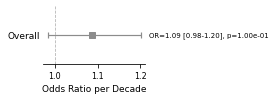

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 2: Forest Plot - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


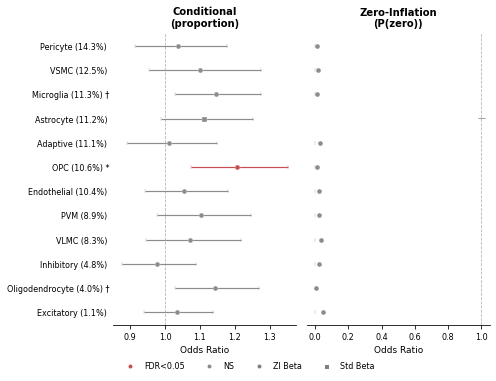

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 3: Scatter + Trendline - Overall
────────────────────────────────────────────────────────────────────────────────


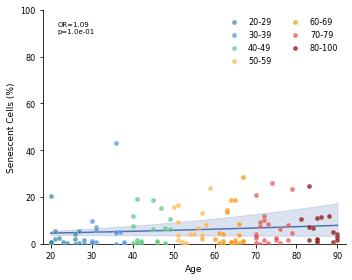

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 4: Scatter + Trendline - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


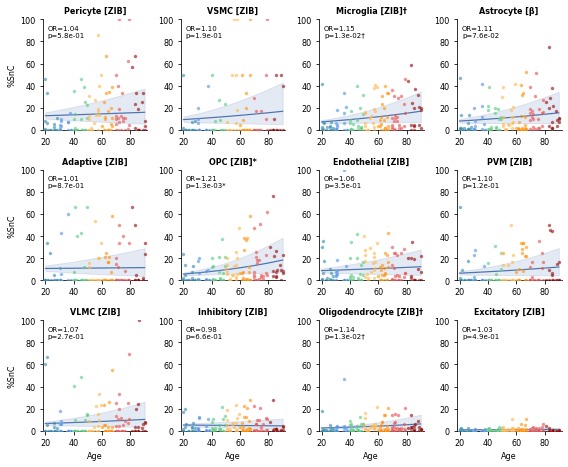

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 5: Boxplot - Overall
────────────────────────────────────────────────────────────────────────────────


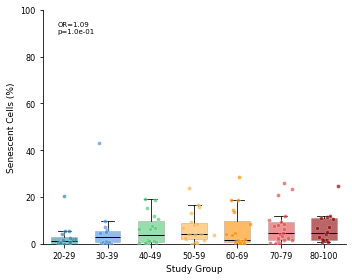

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 6: Boxplot - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


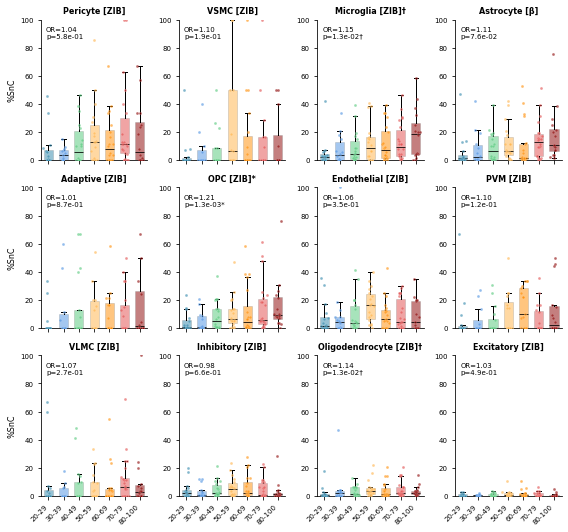

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 7: % Zeros by Study Group
────────────────────────────────────────────────────────────────────────────────


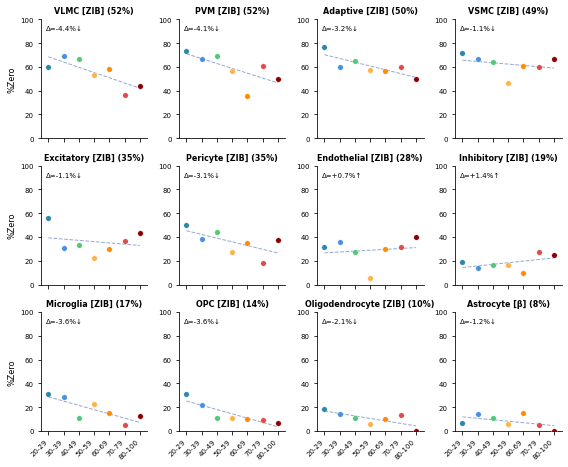

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
FIGURE 8: Sample Composition
────────────────────────────────────────────────────────────────────────────────


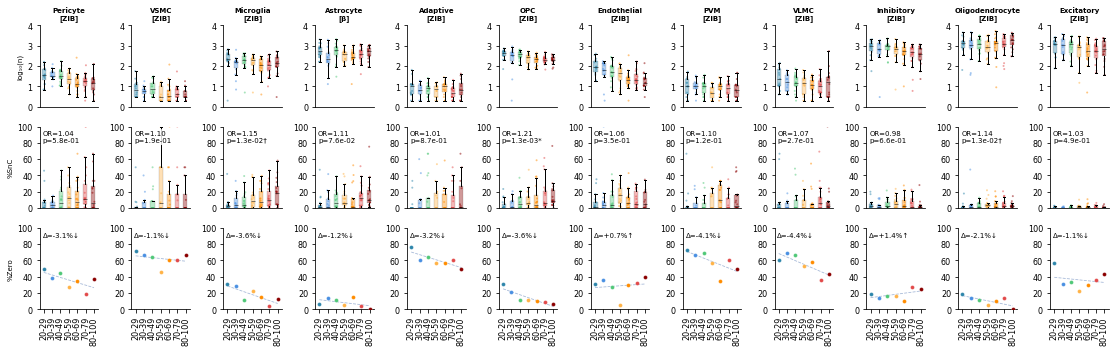

  ✓ Saved

────────────────────────────────────────────────────────────────────────────────
OUTPUT SUMMARY
────────────────────────────────────────────────────────────────────────────────

  Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging

  1. psychad_aging_part2a_forest_overall
  2. psychad_aging_part2b_forest_combined
  3. psychad_aging_part2a_scatter
  4. psychad_aging_part2b_scatter
  5. psychad_aging_part2a_boxplot
  6. psychad_aging_part2b_boxplot
  7. psychad_aging_part2b_pct_zero
  8. psychad_aging_part2_composition

  Significance: *** FDR<0.001, ** FDR<0.01, * FDR<0.05, † p<0.05

════════════════════════════════════════════════════════════════════════════════
✓ Part 2 Visualization complete
════════════════════════════════════════════════════════════════════════════════


In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 2 VISUALIZATION (Publication Ready)
# ════════════════════════════════════════════════════════════════════════════════
#
# Visualizes results from selected model:
#   - Group A: v1_logit_zi_full (Zero-Inflated Beta)
#   - Group B: v1_logit_beta (Standard Beta)
#
# Figures:
#   1. Forest Plot - Overall
#   2. Forest Plot - Per Cell Type (Conditional + ZI side-by-side)
#   3. Scatter + Trendline - Overall
#   4. Scatter + Trendline - Per Cell Type (with OR, p annotation)
#   5. Boxplot by Study Group - Overall
#   6. Boxplot by Study Group - Per Cell Type (with OR, p annotation)
#   7. % Zeros by Study Group - Per Cell Type (with slope annotation)
#   8. Sample Composition Panel (with OR, p annotation)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2 VISUALIZATION")
print("="*80)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.special import expit
from statsmodels.stats.multitest import multipletests

# ─────────────────────────────────────────────────────────────────────────────────
# 10.1 Configuration
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("10.1 CONFIGURATION")
print(f"{'─'*80}")

# Model selection
MODEL_KEY_GROUP_A = 'v1_logit_zi_full'
MODEL_KEY_GROUP_B = 'v1_logit_beta'
MODEL_KEY_OVERALL = 'v1_logit_beta'

# Significance thresholds
SIG_FDR_001 = 0.001
SIG_FDR_01 = 0.01
SIG_FDR_05 = 0.05
SIG_NOMINAL = 0.05

# Publication color scheme
COLOR_SIG = '#C44E52'
COLOR_NS = '#8C8C8C'
COLOR_MODEL = '#4C72B0'
COLOR_CI = '#4C72B0'

# Markers
MARKER_GROUP_A = 'o'
MARKER_GROUP_B = 's'
MARKER_SIZE = 6
MARKER_SIZE_SCATTER = 25

# Fonts
FONT_TITLE = 10
FONT_LABEL = 9
FONT_TICK = 8
FONT_LEGEND = 8
FONT_ANNOT = 7

# Lines
LW_AXIS = 0.8
LW_ERROR = 1.2
LW_MODEL = 1.5

DPI = 300

# ─────────────────────────────────────────────────────────────────────────────────
# Study groups from earlier cells
# ─────────────────────────────────────────────────────────────────────────────────

if 'STUDY_GROUPS_ORDERED' not in dir():
    STUDY_GROUPS_ORDERED = sorted(df_donor[COL_STUDYGROUP].unique())
    print(f"  ⚠ STUDY_GROUPS_ORDERED created from data")

if 'STUDY_GROUP_COLORS' not in dir():
    import matplotlib.cm as cm
    colors = cm.tab10(np.linspace(0, 1, len(STUDY_GROUPS_ORDERED)))
    STUDY_GROUP_COLORS = {sg: colors[i] for i, sg in enumerate(STUDY_GROUPS_ORDERED)}
    print(f"  ⚠ STUDY_GROUP_COLORS created with default palette")

# Detect cohort type
is_aging_cohort = any(sg.startswith('Age_') for sg in STUDY_GROUPS_ORDERED)

def format_sg_label(sg):
    """Format study group label."""
    if is_aging_cohort and sg.startswith('Age_'):
        parts = sg.replace('Age_', '').split('_')
        if len(parts) == 2:
            return f"{parts[0]}-{parts[1]}"
        return sg.replace('Age_', '')
    return sg

sg_labels = [format_sg_label(sg) for sg in STUDY_GROUPS_ORDERED]

print(f"\n  Cohort type: {'Aging' if is_aging_cohort else 'Disease'}")
print(f"  Study groups: {STUDY_GROUPS_ORDERED}")

# Age range
age_min = df_donor[COL_AGE].min()
age_max = df_donor[COL_AGE].max()
age_range = np.linspace(age_min, age_max, 100)
age_scaled_range = age_range / AGE_SCALE

print(f"\n  Models: A={MODEL_KEY_GROUP_A}, B={MODEL_KEY_GROUP_B}")

# ─────────────────────────────────────────────────────────────────────────────────
# 10.2 Prepare Data
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("10.2 DATA PREPARATION")
print(f"{'─'*80}")

df_plot_a = df_results_2b_groupA[df_results_2b_groupA['model_key'] == MODEL_KEY_GROUP_A].copy()
df_plot_b = df_results_2b_groupB[df_results_2b_groupB['model_key'] == MODEL_KEY_GROUP_B].copy()

df_plot_a['group'] = 'A'
df_plot_b['group'] = 'B'

df_plot = pd.concat([df_plot_a, df_plot_b], ignore_index=True)

print(f"  Group A: {len(df_plot_a)} cell types")
print(f"  Group B: {len(df_plot_b)} cell types")

df_overall = df_results_2a[df_results_2a['model_key'] == MODEL_KEY_OVERALL].copy()
if len(df_overall) == 0:
    df_overall = df_results_2a.iloc[[0]].copy()

# ─────────────────────────────────────────────────────────────────────────────────
# 10.3 FDR Correction
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("10.3 FDR CORRECTION")
print(f"{'─'*80}")

cond_pvals = df_plot['cond_p'].fillna(1).values
_, cond_fdr, _, _ = multipletests(cond_pvals, method='fdr_bh')
df_plot['cond_fdr'] = cond_fdr

print(f"  Conditional: {(cond_fdr < 0.05).sum()}/{len(cond_pvals)} FDR<0.05")

zi_pvals = df_plot_a['zi_p'].fillna(1).values
if len(zi_pvals) > 0:
    _, zi_fdr, _, _ = multipletests(zi_pvals, method='fdr_bh')
    df_plot.loc[df_plot['group'] == 'A', 'zi_fdr'] = zi_fdr
    print(f"  ZI: {(zi_fdr < 0.05).sum()}/{len(zi_pvals)} FDR<0.05")
else:
    df_plot['zi_fdr'] = np.nan

# ─────────────────────────────────────────────────────────────────────────────────
# 10.4 Axis Limits & Ordering
# ─────────────────────────────────────────────────────────────────────────────────

ct_order = df_plot.sort_values('mean_snc', ascending=True)[COL_CELLTYPE].tolist()
ct_order_desc = df_plot.sort_values('mean_snc', ascending=False)[COL_CELLTYPE].tolist()

y_max_snc = max(df_donor_ct['prop_snc'].max() * 100, df_donor['prop_snc'].max() * 100)
y_lim_snc = (0, np.ceil(y_max_snc / 10) * 10)

y_lim_log_cells = (
    np.floor(np.log10(df_donor_ct['n_cells'].min() + 1)),
    np.ceil(np.log10(df_donor_ct['n_cells'].max() + 1))
)

y_lim_pct_zero = (0, 100)

print(f"\n  Y-limits: %SnC={y_lim_snc}, log(n)={y_lim_log_cells}, %Zero={y_lim_pct_zero}")

# ─────────────────────────────────────────────────────────────────────────────────
# Helper Functions
# ─────────────────────────────────────────────────────────────────────────────────

def get_sig_marker(p_val, fdr_val):
    if pd.isna(fdr_val) and pd.isna(p_val):
        return ""
    if pd.notna(fdr_val) and fdr_val < SIG_FDR_001:
        return "***"
    if pd.notna(fdr_val) and fdr_val < SIG_FDR_01:
        return "**"
    if pd.notna(fdr_val) and fdr_val < SIG_FDR_05:
        return "*"
    if pd.notna(p_val) and p_val < SIG_NOMINAL:
        return "†"
    return ""

def get_sig_color(p_val, fdr_val):
    if pd.notna(fdr_val) and fdr_val < SIG_FDR_05:
        return COLOR_SIG
    return COLOR_NS

def set_pub_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(LW_AXIS)
    ax.spines['bottom'].set_linewidth(LW_AXIS)
    ax.tick_params(width=LW_AXIS, labelsize=FONT_TICK)

def add_stats_annotation(ax, or_val, p_val, fdr_val=None):
    """Add OR and p-value annotation to top-left corner."""
    if pd.isna(or_val) or pd.isna(p_val):
        return
    sig = get_sig_marker(p_val, fdr_val)
    text = f"OR={or_val:.2f}\np={p_val:.1e}{sig}"
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=FONT_ANNOT,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='none', alpha=0.8))

def add_slope_annotation(ax, slope):
    """Add slope annotation to top-left corner."""
    if pd.isna(slope):
        return
    direction = '↑' if slope > 0 else '↓' if slope < 0 else ''
    text = f"Δ={slope:+.1f}%{direction}"
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=FONT_ANNOT,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='none', alpha=0.8))

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: FOREST PLOT - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 1: Forest Plot - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(4, 1.5))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

row = df_overall.iloc[0]
exp_b = row['cond_exp_beta']
ci_lo = row['cond_exp_lower']
ci_hi = row['cond_exp_upper']
p_val = row['cond_p']

color = COLOR_SIG if p_val < SIG_NOMINAL else COLOR_NS

ax.errorbar(exp_b, 0, xerr=[[exp_b - ci_lo], [ci_hi - exp_b]], 
            fmt='s', color=color, capsize=3, markersize=MARKER_SIZE, 
            capthick=LW_ERROR, elinewidth=LW_ERROR, zorder=3)

sig = get_sig_marker(p_val, p_val)
ax.text(ci_hi + 0.02, 0, f'OR={exp_b:.2f} [{ci_lo:.2f}-{ci_hi:.2f}], p={p_val:.2e}{sig}',
        va='center', fontsize=FONT_ANNOT)

ax.set_yticks([0])
ax.set_yticklabels(['Overall'], fontsize=FONT_LABEL)
ax.set_xlabel('Odds Ratio per Decade', fontsize=FONT_LABEL)
ax.set_ylim(-0.5, 0.5)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', labelsize=FONT_TICK)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_forest_overall.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_forest_overall.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: FOREST PLOT - PER CELL TYPE (Conditional + ZI)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 2: Forest Plot - Per Cell Type")
print(f"{'─'*80}")

n_ct = len(ct_order)
fig, axes = plt.subplots(1, 2, figsize=(7, 0.35 * n_ct + 1), sharey=True)

for panel_idx, (ax, component) in enumerate(zip(axes, ['cond', 'zi'])):
    ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
    
    for i, ct in enumerate(ct_order):
        row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
        
        if component == 'zi' and row['group'] == 'B':
            ax.text(1, i, '—', ha='center', va='center', fontsize=FONT_TICK, color='gray')
            continue
        
        exp_b = row[f'{component}_exp_beta']
        ci_lo = row[f'{component}_exp_lower']
        ci_hi = row[f'{component}_exp_upper']
        p_val = row[f'{component}_p']
        fdr_val = row.get(f'{component}_fdr', np.nan)
        
        color = get_sig_color(p_val, fdr_val)
        marker = MARKER_GROUP_A if row['group'] == 'A' else MARKER_GROUP_B
        
        if pd.notna(exp_b):
            ax.errorbar(exp_b, i, xerr=[[exp_b - ci_lo], [ci_hi - exp_b]], 
                        fmt=marker, color=color, capsize=2, markersize=MARKER_SIZE-1, 
                        capthick=LW_ERROR, elinewidth=LW_ERROR, zorder=3,
                        markeredgecolor='white', markeredgewidth=0.3)
    
    ax.set_xlabel('Odds Ratio', fontsize=FONT_LABEL)
    title = 'Conditional\n(proportion)' if component == 'cond' else 'Zero-Inflation\n(P(zero))'
    ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
    set_pub_style(ax)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)

axes[0].set_yticks(range(n_ct))
y_labels = []
for ct in ct_order:
    row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
    sig = get_sig_marker(row['cond_p'], row['cond_fdr'])
    y_labels.append(f"{ct} ({row['mean_snc']:.1f}%) {sig}")
axes[0].set_yticklabels(y_labels, fontsize=FONT_TICK)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SIG, markersize=5, label='FDR<0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_NS, markersize=5, label='NS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='ZI Beta'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=5, label='Std Beta'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           fontsize=FONT_LEGEND, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_forest_combined.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_forest_combined.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: SCATTER + TRENDLINE - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 3: Scatter + Trendline - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(5, 4))

row = df_overall.iloc[0]
beta_age = row['cond_beta']
se_age = row['cond_se']

baseline_prop = df_donor['prop_snc'].mean()
mean_age_scaled = df_donor['Age_scaled'].mean()
intercept = np.log(baseline_prop / (1 - baseline_prop)) - beta_age * mean_age_scaled

eta = intercept + beta_age * age_scaled_range
prob = expit(eta)
eta_lo = intercept + (beta_age - 1.96 * se_age) * age_scaled_range
eta_hi = intercept + (beta_age + 1.96 * se_age) * age_scaled_range
prob_lo = expit(eta_lo)
prob_hi = expit(eta_hi)

ax.fill_between(age_range, prob_lo * 100, prob_hi * 100, alpha=0.2, color=COLOR_CI)
ax.plot(age_range, prob * 100, color=COLOR_MODEL, linewidth=LW_MODEL)

for sg in STUDY_GROUPS_ORDERED:
    mask = df_donor[COL_STUDYGROUP] == sg
    if mask.sum() > 0:
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        ax.scatter(df_donor.loc[mask, COL_AGE], 
                   df_donor.loc[mask, 'prop_snc'] * 100,
                   c=[color], s=MARKER_SIZE_SCATTER, alpha=0.7, 
                   edgecolors='white', linewidths=0.3, zorder=5,
                   label=format_sg_label(sg))

add_stats_annotation(ax, row['cond_exp_beta'], row['cond_p'])

ax.set_xlabel(COL_AGE, fontsize=FONT_LABEL)
ax.set_ylabel('Senescent Cells (%)', fontsize=FONT_LABEL)
ax.set_xlim(age_min - 2, age_max + 2)
ax.set_ylim(y_lim_snc)
ax.legend(loc='upper right', fontsize=FONT_LEGEND, frameon=False, ncol=2)
set_pub_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_scatter.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_scatter.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: SCATTER + TRENDLINE - PER CELL TYPE (with stats annotation)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 4: Scatter + Trendline - Per Cell Type")
print(f"{'─'*80}")

n_cols = 4
n_rows = int(np.ceil(len(ct_order_desc) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2.2 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_desc):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
    
    # Scatter
    for sg in STUDY_GROUPS_ORDERED:
        mask = df_ct[COL_STUDYGROUP] == sg
        if mask.sum() > 0:
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(df_ct.loc[mask, COL_AGE], 
                       df_ct.loc[mask, 'prop_snc'] * 100,
                       c=[color], s=12, alpha=0.6, edgecolors='white', linewidths=0.2, zorder=5)
    
    # Trendline
    beta_ct = row['cond_beta']
    se_ct = row['cond_se']
    if pd.notna(beta_ct):
        baseline = df_ct['prop_snc'].mean()
        mean_age = df_ct['Age_scaled'].mean()
        if 0 < baseline < 1:
            intercept = np.log(baseline / (1 - baseline)) - beta_ct * mean_age
            eta = intercept + beta_ct * age_scaled_range
            prob = expit(eta)
            eta_lo = intercept + (beta_ct - 1.96 * se_ct) * age_scaled_range
            eta_hi = intercept + (beta_ct + 1.96 * se_ct) * age_scaled_range
            
            ax.fill_between(age_range, expit(eta_lo) * 100, expit(eta_hi) * 100, 
                           alpha=0.15, color=COLOR_CI)
            ax.plot(age_range, prob * 100, color=COLOR_MODEL, linewidth=1.2)
    
    # Stats annotation
    add_stats_annotation(ax, row['cond_exp_beta'], row['cond_p'], row['cond_fdr'])
    
    # Title
    sig = get_sig_marker(row['cond_p'], row['cond_fdr'])
    grp = 'ZIB' if row['group'] == 'A' else 'β'
    ax.set_title(f"{ct} [{grp}]{sig}", fontsize=FONT_TICK, fontweight='bold')
    
    ax.set_xlim(age_min - 2, age_max + 2)
    ax.set_ylim(y_lim_snc)
    ax.tick_params(labelsize=FONT_TICK - 1)
    set_pub_style(ax)
    
    if idx >= len(ct_order_desc) - n_cols:
        ax.set_xlabel(COL_AGE, fontsize=FONT_TICK)
    if idx % n_cols == 0:
        ax.set_ylabel('%SnC', fontsize=FONT_TICK)

for idx in range(len(ct_order_desc), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_scatter.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_scatter.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: BOXPLOT - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 5: Boxplot - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(5, 4))

box_data = [df_donor[df_donor[COL_STUDYGROUP] == sg]['prop_snc'].values * 100 
            for sg in STUDY_GROUPS_ORDERED]

bp = ax.boxplot(box_data, positions=range(len(STUDY_GROUPS_ORDERED)), widths=0.6, 
                patch_artist=True, showfliers=False)

for i, (patch, sg) in enumerate(zip(bp['boxes'], STUDY_GROUPS_ORDERED)):
    color = STUDY_GROUP_COLORS.get(sg, 'gray')
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('gray')
    patch.set_linewidth(0.5)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1)
for whisker in bp['whiskers']:
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_linewidth(0.8)

for i, sg in enumerate(STUDY_GROUPS_ORDERED):
    mask = df_donor[COL_STUDYGROUP] == sg
    y = df_donor.loc[mask, 'prop_snc'].values * 100
    x = np.random.normal(i, 0.12, size=len(y))
    color = STUDY_GROUP_COLORS.get(sg, 'gray')
    ax.scatter(x, y, c=[color], s=15, alpha=0.7, edgecolors='white', linewidths=0.3, zorder=3)

ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
ax.set_xticklabels(sg_labels, fontsize=FONT_TICK, rotation=45 if len(sg_labels[0]) > 5 else 0, 
                   ha='right' if len(sg_labels[0]) > 5 else 'center')
ax.set_xlabel(COL_STUDYGROUP.replace('_', ' '), fontsize=FONT_LABEL)
ax.set_ylabel('Senescent Cells (%)', fontsize=FONT_LABEL)
ax.set_ylim(y_lim_snc)
set_pub_style(ax)

row = df_overall.iloc[0]
add_stats_annotation(ax, row['cond_exp_beta'], row['cond_p'])

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_boxplot.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_boxplot.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6: BOXPLOT - PER CELL TYPE (with stats annotation)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 6: Boxplot - Per Cell Type")
print(f"{'─'*80}")

n_cols = 4
n_rows = int(np.ceil(len(ct_order_desc) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2.5 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_desc):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
    
    box_data = [df_ct[df_ct[COL_STUDYGROUP] == sg]['prop_snc'].values * 100 
                for sg in STUDY_GROUPS_ORDERED]
    
    bp = ax.boxplot(box_data, positions=range(len(STUDY_GROUPS_ORDERED)), widths=0.6, 
                    patch_artist=True, showfliers=False)
    
    for i, (patch, sg) in enumerate(zip(bp['boxes'], STUDY_GROUPS_ORDERED)):
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
        patch.set_edgecolor('gray')
        patch.set_linewidth(0.5)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(0.8)
    
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        mask = df_ct[COL_STUDYGROUP] == sg
        y = df_ct.loc[mask, 'prop_snc'].values * 100
        if len(y) > 0:
            x = np.random.normal(i, 0.1, size=len(y))
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(x, y, c=[color], s=8, alpha=0.6, edgecolors='white', linewidths=0.2, zorder=3)
    
    ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
    if idx >= len(ct_order_desc) - n_cols:
        ax.set_xticklabels(sg_labels, fontsize=FONT_TICK - 2, rotation=45, ha='right')
    else:
        ax.set_xticklabels([])
    
    # Stats annotation
    add_stats_annotation(ax, row['cond_exp_beta'], row['cond_p'], row['cond_fdr'])
    
    sig = get_sig_marker(row['cond_p'], row['cond_fdr'])
    grp = 'ZIB' if row['group'] == 'A' else 'β'
    ax.set_title(f"{ct} [{grp}]{sig}", fontsize=FONT_TICK, fontweight='bold')
    
    ax.set_ylim(y_lim_snc)
    if idx % n_cols == 0:
        ax.set_ylabel('%SnC', fontsize=FONT_TICK)
    set_pub_style(ax)
    ax.tick_params(labelsize=FONT_TICK - 1)

for idx in range(len(ct_order_desc), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_boxplot.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_boxplot.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7: % ZEROS BY STUDY GROUP (with slope annotation)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 7: % Zeros by Study Group")
print(f"{'─'*80}")

ct_order_zero = df_plot.sort_values('pct_zeros', ascending=False)[COL_CELLTYPE].tolist()

n_cols = 4
n_rows = int(np.ceil(len(ct_order_zero) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2.2 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_zero):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
    
    pct_zeros = []
    x_pos = []
    sg_valid = []
    
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) >= 3:
            pz = (sg_data['prop_snc'] == 0).mean() * 100
            pct_zeros.append(pz)
            x_pos.append(i)
            sg_valid.append(sg)
    
    slope = np.nan
    if len(pct_zeros) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
                transform=ax.transAxes, fontsize=FONT_TICK, color='gray')
        ax.set_title(ct, fontsize=FONT_TICK, fontweight='bold')
    else:
        # Points
        for xp, sg, pz in zip(x_pos, sg_valid, pct_zeros):
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(xp, pz, c=[color], s=30, edgecolors='white', linewidths=0.3, zorder=5)
        
        # Trendline
        if len(x_pos) >= 3:
            z = np.polyfit(x_pos, pct_zeros, 1)
            slope = z[0]
            p_line = np.poly1d(z)
            x_line = np.linspace(min(x_pos), max(x_pos), 50)
            ax.plot(x_line, p_line(x_line), color=COLOR_MODEL, linewidth=1, 
                    linestyle='--', alpha=0.6, zorder=2)
        
        # Slope annotation
        add_slope_annotation(ax, slope)
        
        grp = 'ZIB' if row['group'] == 'A' else 'β'
        ax.set_title(f"{ct} [{grp}] ({row['pct_zeros']:.0f}%)", fontsize=FONT_TICK, fontweight='bold')
    
    ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
    if idx >= len(ct_order_zero) - n_cols:
        ax.set_xticklabels(sg_labels, fontsize=FONT_TICK - 2, rotation=45, ha='right')
    else:
        ax.set_xticklabels([])
    
    ax.set_xlim(-0.5, len(STUDY_GROUPS_ORDERED) - 0.5)
    ax.set_ylim(y_lim_pct_zero)
    if idx % n_cols == 0:
        ax.set_ylabel('%Zero', fontsize=FONT_TICK)
    set_pub_style(ax)
    ax.tick_params(labelsize=FONT_TICK - 1)

for idx in range(len(ct_order_zero), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_pct_zero.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_pct_zero.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 8: SAMPLE COMPOSITION (3-row panel with annotations)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 8: Sample Composition")
print(f"{'─'*80}")

n_cts = len(ct_order_desc)
fig, axes = plt.subplots(3, n_cts, figsize=(1.3 * n_cts, 5))

for ct_idx, ct in enumerate(ct_order_desc):
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    row = df_plot[df_plot[COL_CELLTYPE] == ct].iloc[0]
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 0: log10(n_cells)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0, ct_idx]
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]['n_cells'].dropna()
        if len(sg_data) == 0:
            continue
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        sg_log = np.log10(sg_data.values + 1)
        
        if len(sg_data) >= 3:
            bp = ax.boxplot([sg_log], positions=[i], widths=0.5, patch_artist=True, manage_ticks=False)
            bp['boxes'][0].set_facecolor(color)
            bp['boxes'][0].set_alpha(0.4)
            bp['boxes'][0].set_linewidth(0.3)
            bp['medians'][0].set_color('black')
            bp['medians'][0].set_linewidth(0.5)
            for f in bp['fliers']:
                f.set_visible(False)
        
        jx = np.random.uniform(-0.12, 0.12, len(sg_data))
        ax.scatter(i + jx, sg_log, c=[color]*len(sg_data), s=4, alpha=0.5, edgecolors='none')
    
    grp = 'ZIB' if row['group'] == 'A' else 'β'
    ax.set_title(f"{ct}\n[{grp}]", fontsize=FONT_TICK - 1, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylim(y_lim_log_cells)
    if ct_idx == 0:
        ax.set_ylabel('log₁₀(n)', fontsize=FONT_TICK - 1)
    ax.tick_params(labelsize=FONT_TICK - 2)
    set_pub_style(ax)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 1: %SnC (with OR, p annotation)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1, ct_idx]
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]['prop_snc'].dropna() * 100
        if len(sg_data) == 0:
            continue
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        
        if len(sg_data) >= 3:
            bp = ax.boxplot([sg_data.values], positions=[i], widths=0.5, patch_artist=True, manage_ticks=False)
            bp['boxes'][0].set_facecolor(color)
            bp['boxes'][0].set_alpha(0.4)
            bp['boxes'][0].set_linewidth(0.3)
            bp['medians'][0].set_color('black')
            bp['medians'][0].set_linewidth(0.5)
            for f in bp['fliers']:
                f.set_visible(False)
        
        jx = np.random.uniform(-0.12, 0.12, len(sg_data))
        ax.scatter(i + jx, sg_data.values, c=[color]*len(sg_data), s=4, alpha=0.5, edgecolors='none')
    
    # Stats annotation
    add_stats_annotation(ax, row['cond_exp_beta'], row['cond_p'], row['cond_fdr'])
    
    ax.set_xticks([])
    ax.set_ylim(y_lim_snc)
    if ct_idx == 0:
        ax.set_ylabel('%SnC', fontsize=FONT_TICK - 1)
    ax.tick_params(labelsize=FONT_TICK - 2)
    set_pub_style(ax)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 2: %Zero (with slope annotation)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[2, ct_idx]
    pct_zeros = []
    x_pos = []
    sg_valid = []
    
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) >= 3:
            pz = (sg_data['prop_snc'] == 0).mean() * 100
            pct_zeros.append(pz)
            x_pos.append(i)
            sg_valid.append(sg)
    
    slope = np.nan
    if len(pct_zeros) > 0:
        for xp, sg, pz in zip(x_pos, sg_valid, pct_zeros):
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(xp, pz, c=[color], s=15, edgecolors='white', linewidths=0.2, zorder=5)
        
        if len(x_pos) >= 3:
            z = np.polyfit(x_pos, pct_zeros, 1)
            slope = z[0]
            p_line = np.poly1d(z)
            x_line = np.linspace(min(x_pos), max(x_pos), 50)
            ax.plot(x_line, p_line(x_line), color=COLOR_MODEL, linewidth=0.8, 
                    linestyle='--', alpha=0.5)
    
    # Slope annotation
    add_slope_annotation(ax, slope)
    
    ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
    ax.set_xticklabels(sg_labels, fontsize=FONT_TICK - 2, rotation=90)
    ax.set_xlim(-0.5, len(STUDY_GROUPS_ORDERED) - 0.5)
    ax.set_ylim(y_lim_pct_zero)
    if ct_idx == 0:
        ax.set_ylabel('%Zero', fontsize=FONT_TICK - 1)
    ax.tick_params(labelsize=FONT_TICK - 2)
    set_pub_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2_composition.pdf', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2_composition.png', dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("OUTPUT SUMMARY")
print(f"{'─'*80}")

print(f"\n  Figures saved to: {FIGURES_DIR}")
print(f"\n  1. {DATASET}_part2a_forest_overall")
print(f"  2. {DATASET}_part2b_forest_combined")
print(f"  3. {DATASET}_part2a_scatter")
print(f"  4. {DATASET}_part2b_scatter")
print(f"  5. {DATASET}_part2a_boxplot")
print(f"  6. {DATASET}_part2b_boxplot")
print(f"  7. {DATASET}_part2b_pct_zero")
print(f"  8. {DATASET}_part2_composition")

print(f"\n  Significance: *** FDR<0.001, ** FDR<0.01, * FDR<0.05, † p<0.05")

print(f"\n{'═'*80}")
print(f"✓ Part 2 Visualization complete")
print(f"{'═'*80}")

PART 3: GROUP COMPARISONS - psychad_aging

▸ Defining comparison groups...
  Cohort type: aging
  Young: ['Age_20_29', 'Age_30_39']
  Old: ['Age_70_79', 'Age_80_100']

  Donors in comparison:
    Young: 30
    Old: 38
    Total: 68 (excluded: 56)

────────────────────────────────────────────────────────────
PART 3A: OVERALL GROUP COMPARISON
────────────────────────────────────────────────────────────

  Young (n=30): Mean=4.37%, Median=1.35%
  Old (n=38): Mean=6.85%, Median=4.50%

  Mann-Whitney U=361.0, p=1.00e-02
  Cliff's δ=-0.367 (medium)
  Result: Old > Young *

────────────────────────────────────────────────────────────
PART 3B: PER CELL TYPE GROUP COMPARISON
────────────────────────────────────────────────────────────

  Cell_Type           n1  n2  Mean1  Mean2      δ         p       FDR     Effect
  -------------------------------------------------------------------------------------
  Astrocyte           30  38   6.83  15.70 -0.511  3.25e-04  2.04e-03    large**
  OPC        

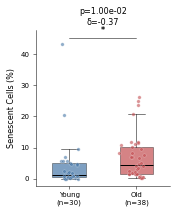

  ✓ Saved

▸ Figure 2: Effect Size Forest Plot


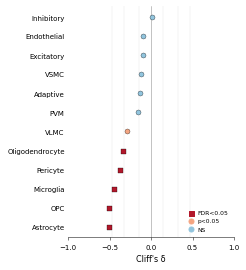

  ✓ Saved

▸ Figure 3: Per Cell Type Boxplots


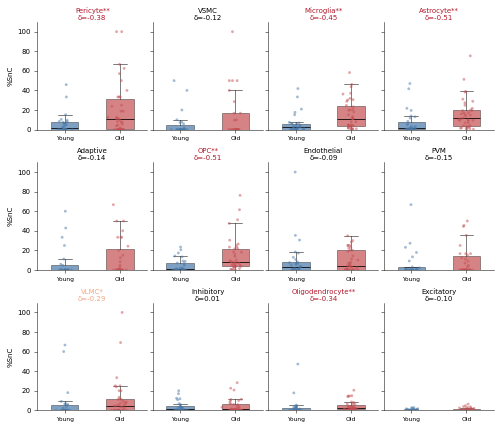

  ✓ Saved

▸ Figure 4: % Change Bar Chart


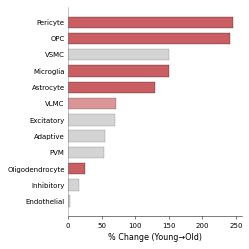

  ✓ Saved

▸ Figure 5: % Zero Comparison


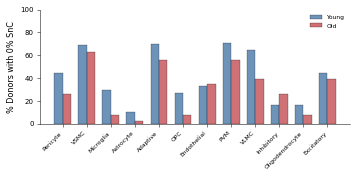

  ✓ Saved

PART 3 COMPLETE: psychad_aging

Comparison: Young vs Old
  Young: ['Age_20_29', 'Age_30_39']
  Old: ['Age_70_79', 'Age_80_100']

Results:
  Part 3A Overall: p=1.00e-02, δ=-0.367 (medium)
  Part 3B Per Cell_Type: 6 nominal, 5 FDR-significant

Files saved to: /fs/scratch/PAS2598/senescence_analysis/results/02.5_probability_modeling/psychad_aging
  - psychad_aging_part3a_overall_comparison.csv
  - psychad_aging_part3b_celltype_comparison.csv

Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging
  1. psychad_aging_part3a_overall_comparison.pdf/.svg
  2. psychad_aging_part3b_effect_size_forest.pdf/.svg
  3. psychad_aging_part3b_celltype_boxplots.pdf/.svg
  4. psychad_aging_part3b_pct_change_bar.pdf/.svg
  5. psychad_aging_part3b_pct_zero_comparison.pdf/.svg

✓ Part 3 complete → Next Cell: Part 3C or Export


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 3 - GROUP COMPARISONS (Young vs Old)
# ════════════════════════════════════════════════════════════════════════════════
#
# Part 3A: Overall group comparison (Mann-Whitney U + Cliff's δ)
# Part 3B: Per cell type group comparison with FDR correction
#
# Visualizations (publication-quality):
#   1. Overall boxplot comparison
#   2. Effect size forest plot
#   3. Per cell type boxplots
#   4. % Change bar chart
#   5. % Zero comparison
#
# Output: PDF + SVG
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print(f"PART 3: GROUP COMPARISONS - {DATASET}")
print("="*60)

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────────
# Publication-quality plot settings
# ─────────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'lines.linewidth': 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ─────────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n▸ Defining comparison groups...")

is_aging = any(sg.startswith('Age_') for sg in STUDY_GROUPS_ORDERED)

if is_aging:
    print(f"  Cohort type: aging")
    YOUNG_GROUPS = STUDY_GROUPS_ORDERED[:2]
    OLD_GROUPS = STUDY_GROUPS_ORDERED[-2:]
    GROUP1_NAME = 'Young'
    GROUP2_NAME = 'Old'
    GROUP1_COLOR = '#4878A8'  # Muted blue
    GROUP2_COLOR = '#C44E52'  # Muted red
else:
    print(f"  Cohort type: disease")
    YOUNG_GROUPS = ['Control', 'NCI', 'Ctrl']
    OLD_GROUPS = ['AD', 'Alzheimer']
    GROUP1_NAME = 'Control'
    GROUP2_NAME = 'AD'
    GROUP1_COLOR = '#4878A8'
    GROUP2_COLOR = '#C44E52'

print(f"  {GROUP1_NAME}: {YOUNG_GROUPS}")
print(f"  {GROUP2_NAME}: {OLD_GROUPS}")

mask_group1_donor = df_donor[COL_STUDYGROUP].isin(YOUNG_GROUPS)
mask_group2_donor = df_donor[COL_STUDYGROUP].isin(OLD_GROUPS)
mask_group1_ct = df_donor_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS)
mask_group2_ct = df_donor_ct[COL_STUDYGROUP].isin(OLD_GROUPS)

n_group1 = mask_group1_donor.sum()
n_group2 = mask_group2_donor.sum()
n_excluded = len(df_donor) - n_group1 - n_group2

print(f"\n  Donors in comparison:")
print(f"    {GROUP1_NAME}: {n_group1}")
print(f"    {GROUP2_NAME}: {n_group2}")
print(f"    Total: {n_group1 + n_group2} (excluded: {n_excluded})")

# ════════════════════════════════════════════════════════════════════════════════
# PART 3A: OVERALL GROUP COMPARISON
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3A: OVERALL GROUP COMPARISON")
print(f"{'─'*60}")

group1_data = df_donor.loc[mask_group1_donor, 'prop_snc'].values * 100
group2_data = df_donor.loc[mask_group2_donor, 'prop_snc'].values * 100

mean1, mean2 = np.mean(group1_data), np.mean(group2_data)
median1, median2 = np.median(group1_data), np.median(group2_data)

print(f"\n  {GROUP1_NAME} (n={len(group1_data)}): Mean={mean1:.2f}%, Median={median1:.2f}%")
print(f"  {GROUP2_NAME} (n={len(group2_data)}): Mean={mean2:.2f}%, Median={median2:.2f}%")

stat_u, p_overall = mannwhitneyu(group1_data, group2_data, alternative='two-sided')

n1, n2 = len(group1_data), len(group2_data)
greater = sum(1 for x in group1_data for y in group2_data if x > y)
less = sum(1 for x in group1_data for y in group2_data if x < y)
cliff_delta_overall = (greater - less) / (n1 * n2)

if abs(cliff_delta_overall) < 0.147:
    effect_label_overall = 'negligible'
elif abs(cliff_delta_overall) < 0.33:
    effect_label_overall = 'small'
elif abs(cliff_delta_overall) < 0.474:
    effect_label_overall = 'medium'
else:
    effect_label_overall = 'large'

print(f"\n  Mann-Whitney U={stat_u:.1f}, p={p_overall:.2e}")
print(f"  Cliff's δ={cliff_delta_overall:.3f} ({effect_label_overall})")

sig_marker = "**" if p_overall < 0.01 else "*" if p_overall < 0.05 else ""
direction = f"{GROUP2_NAME} > {GROUP1_NAME}" if mean2 > mean1 else f"{GROUP1_NAME} > {GROUP2_NAME}"
print(f"  Result: {direction} {sig_marker}")

results_3a = {
    'comparison': f'{GROUP1_NAME}_vs_{GROUP2_NAME}',
    'n_group1': n_group1, 'n_group2': n_group2,
    'mean_group1': mean1, 'mean_group2': mean2,
    'median_group1': median1, 'median_group2': median2,
    'U_statistic': stat_u, 'p_value': p_overall,
    'cliff_delta': cliff_delta_overall, 'effect_size': effect_label_overall
}
df_results_3a = pd.DataFrame([results_3a])

# ════════════════════════════════════════════════════════════════════════════════
# PART 3B: PER CELL TYPE GROUP COMPARISON
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3B: PER CELL TYPE GROUP COMPARISON")
print(f"{'─'*60}")

# Get cell type order from df_donor_ct (sorted by mean senescence proportion)
ct_order = df_donor_ct.groupby(COL_CELLTYPE)['prop_snc'].mean().sort_values(ascending=False).index.tolist()

results_3b = []

for ct in ct_order:
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct]
    
    ct_group1 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS), 'prop_snc'].values * 100
    ct_group2 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(OLD_GROUPS), 'prop_snc'].values * 100
    
    if len(ct_group1) < 3 or len(ct_group2) < 3:
        continue
    
    ct_mean1, ct_mean2 = np.mean(ct_group1), np.mean(ct_group2)
    ct_stat, ct_p = mannwhitneyu(ct_group1, ct_group2, alternative='two-sided')
    
    ct_n1, ct_n2 = len(ct_group1), len(ct_group2)
    ct_greater = sum(1 for x in ct_group1 for y in ct_group2 if x > y)
    ct_less = sum(1 for x in ct_group1 for y in ct_group2 if x < y)
    ct_delta = (ct_greater - ct_less) / (ct_n1 * ct_n2)
    
    if abs(ct_delta) < 0.147:
        ct_effect = 'negligible'
    elif abs(ct_delta) < 0.33:
        ct_effect = 'small'
    elif abs(ct_delta) < 0.474:
        ct_effect = 'medium'
    else:
        ct_effect = 'large'
    
    pct_change = ((ct_mean2 - ct_mean1) / ct_mean1) * 100 if ct_mean1 > 0 else np.nan
    pct_zero_g1 = (ct_group1 == 0).mean() * 100
    pct_zero_g2 = (ct_group2 == 0).mean() * 100
    
    results_3b.append({
        COL_CELLTYPE: ct, 'n_group1': ct_n1, 'n_group2': ct_n2,
        'mean_group1': ct_mean1, 'mean_group2': ct_mean2,
        'pct_change': pct_change, 'pct_zero_group1': pct_zero_g1, 'pct_zero_group2': pct_zero_g2,
        'U_statistic': ct_stat, 'p_value': ct_p, 'cliff_delta': ct_delta, 'effect_size': ct_effect
    })

df_results_3b = pd.DataFrame(results_3b)
df_results_3b['FDR'] = stats.false_discovery_control(df_results_3b['p_value'], method='bh')
df_results_3b = df_results_3b.sort_values('p_value').reset_index(drop=True)

print(f"\n  {COL_CELLTYPE:<18} {'n1':>3} {'n2':>3} {'Mean1':>6} {'Mean2':>6} {'δ':>6} {'p':>9} {'FDR':>9} {'Effect':>10}")
print(f"  {'-'*85}")

for _, row in df_results_3b.iterrows():
    sig = "**" if row['FDR'] < 0.05 else "*" if row['p_value'] < 0.05 else ""
    print(f"  {row[COL_CELLTYPE]:<18} {row['n_group1']:>3} {row['n_group2']:>3} "
          f"{row['mean_group1']:>6.2f} {row['mean_group2']:>6.2f} "
          f"{row['cliff_delta']:>6.3f} {row['p_value']:>9.2e} {row['FDR']:>9.2e} "
          f"{row['effect_size']:>8}{sig}")

n_nominal = (df_results_3b['p_value'] < 0.05).sum()
n_fdr = (df_results_3b['FDR'] < 0.05).sum()
print(f"\n  Significant: {n_nominal} nominal (p<0.05), {n_fdr} FDR-corrected")

df_results_3a.to_csv(RESULTS_DIR / f'{DATASET}_part3a_overall_comparison.csv', index=False)
df_results_3b.to_csv(RESULTS_DIR / f'{DATASET}_part3b_celltype_comparison.csv', index=False)
print(f"\n✓ Results saved to CSV")

# ════════════════════════════════════════════════════════════════════════════════
# PART 3 VISUALIZATION (Publication-quality)
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3 VISUALIZATION")
print(f"{'─'*60}")

# Consistent y-axis
y_max_3b = max(
    df_donor_ct.loc[mask_group1_ct | mask_group2_ct, 'prop_snc'].max() * 100,
    df_results_3b['mean_group2'].max()
) * 1.1
y_lim_3b = (0, y_max_3b)

# Cell type order for plots (sorted by mean senescence proportion)
ct_order_3b = df_donor_ct.groupby(COL_CELLTYPE)['prop_snc'].mean().sort_values(ascending=False).index.tolist()
ct_order_3b = [ct for ct in ct_order_3b if ct in df_results_3b[COL_CELLTYPE].values]

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: OVERALL COMPARISON (Compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 1: Overall Comparison")

fig, ax = plt.subplots(figsize=(2.5, 3))

box_data = [group1_data, group2_data]

bp = ax.boxplot(box_data, positions=[0, 1], widths=0.5, patch_artist=True, 
                showfliers=False, zorder=2)

for patch, color in zip(bp['boxes'], [GROUP1_COLOR, GROUP2_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(0.5)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1)
for whisker in bp['whiskers']:
    whisker.set_linewidth(0.5)
for cap in bp['caps']:
    cap.set_linewidth(0.5)

for i, (data, color) in enumerate(zip(box_data, [GROUP1_COLOR, GROUP2_COLOR])):
    x = np.random.normal(i, 0.08, size=len(data))
    ax.scatter(x, data, c=color, s=12, alpha=0.6, edgecolors='white', linewidths=0.3, zorder=3)

# Significance bar
y_bar = max(group1_data.max(), group2_data.max()) * 1.05
sig_text = "**" if p_overall < 0.01 else "*" if p_overall < 0.05 else "ns"
ax.plot([0, 1], [y_bar, y_bar], color='black', linewidth=0.5)
ax.text(0.5, y_bar * 1.02, sig_text, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels([f'{GROUP1_NAME}\n(n={n_group1})', f'{GROUP2_NAME}\n(n={n_group2})'])
ax.set_ylabel('Senescent Cells (%)')
ax.set_title(f'p={p_overall:.2e}\nδ={cliff_delta_overall:.2f}', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part3a_overall_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part3a_overall_comparison.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: EFFECT SIZE FOREST PLOT (Compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 2: Effect Size Forest Plot")

df_plot_forest = df_results_3b.sort_values('cliff_delta', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 0.25 * len(df_plot_forest) + 0.8))

ax.axvline(x=0, color='#888888', linestyle='-', linewidth=0.5, zorder=1)

# Effect size thresholds (subtle)
for thresh in [-0.474, -0.33, -0.147, 0.147, 0.33, 0.474]:
    ax.axvline(x=thresh, color='#DDDDDD', linestyle='-', linewidth=0.3, zorder=0)

y_pos = range(len(df_plot_forest))

for i, (_, row) in enumerate(df_plot_forest.iterrows()):
    delta = row['cliff_delta']
    fdr = row['FDR']
    p_val = row['p_value']
    
    if fdr < 0.05:
        color = '#B2182B'
        marker = 's'
    elif p_val < 0.05:
        color = '#F4A582'
        marker = 'o'
    else:
        color = '#92C5DE'
        marker = 'o'
    
    ax.scatter(delta, i, c=color, s=25, marker=marker, edgecolors='black', linewidths=0.3, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels([row[COL_CELLTYPE] for _, row in df_plot_forest.iterrows()])
ax.set_xlabel("Cliff's δ")
ax.set_xlim(-1, 1)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Minimal legend
ax.scatter([], [], c='#B2182B', s=25, marker='s', label='FDR<0.05')
ax.scatter([], [], c='#F4A582', s=25, marker='o', label='p<0.05')
ax.scatter([], [], c='#92C5DE', s=25, marker='o', label='NS')
ax.legend(loc='lower right', frameon=False, handletextpad=0.1, fontsize=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_effect_size_forest.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_effect_size_forest.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: PER CELL TYPE BOXPLOTS (Compact grid)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 3: Per Cell Type Boxplots")

n_cts = len(ct_order_3b)
n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 2 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_3b):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct]
    ct_row = df_results_3b[df_results_3b[COL_CELLTYPE] == ct].iloc[0]
    
    ct_group1 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS), 'prop_snc'].values * 100
    ct_group2 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(OLD_GROUPS), 'prop_snc'].values * 100
    
    bp = ax.boxplot([ct_group1, ct_group2], positions=[0, 1], widths=0.5, 
                    patch_artist=True, showfliers=False)
    
    for patch, color in zip(bp['boxes'], [GROUP1_COLOR, GROUP2_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_linewidth(0.5)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(0.8)
    for whisker in bp['whiskers']:
        whisker.set_linewidth(0.5)
    for cap in bp['caps']:
        cap.set_linewidth(0.5)
    
    for i, (data, color) in enumerate(zip([ct_group1, ct_group2], [GROUP1_COLOR, GROUP2_COLOR])):
        if len(data) > 0:
            x = np.random.normal(i, 0.06, size=len(data))
            ax.scatter(x, data, c=color, s=8, alpha=0.5, edgecolors='none', zorder=3)
    
    p_ct = ct_row['p_value']
    fdr_ct = ct_row['FDR']
    delta_ct = ct_row['cliff_delta']
    
    sig = "**" if fdr_ct < 0.05 else "*" if p_ct < 0.05 else ""
    title_color = '#B2182B' if fdr_ct < 0.05 else ('#F4A582' if p_ct < 0.05 else 'black')
    
    ax.set_title(f"{ct}{sig}\nδ={delta_ct:.2f}", fontsize=7, color=title_color, pad=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([GROUP1_NAME, GROUP2_NAME], fontsize=6, ha='center')
    ax.set_ylim(y_lim_3b)
    
    if idx % n_cols == 0:
        ax.set_ylabel('%SnC', fontsize=7)
    else:
        ax.set_yticklabels([])

for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(h_pad=0.8, w_pad=0.3)
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_celltype_boxplots.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_celltype_boxplots.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: % CHANGE BAR CHART (Horizontal, compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 4: % Change Bar Chart")

df_plot_change = df_results_3b.sort_values('pct_change', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 0.25 * len(df_plot_change) + 0.5))

ax.axvline(x=0, color='#888888', linestyle='-', linewidth=0.5)

y_pos = range(len(df_plot_change))

for i, (_, row) in enumerate(df_plot_change.iterrows()):
    pct = row['pct_change']
    fdr = row['FDR']
    p_val = row['p_value']
    
    if fdr < 0.05:
        color = GROUP2_COLOR if pct > 0 else GROUP1_COLOR
        alpha = 0.9
    elif p_val < 0.05:
        color = GROUP2_COLOR if pct > 0 else GROUP1_COLOR
        alpha = 0.6
    else:
        color = '#AAAAAA'
        alpha = 0.5
    
    ax.barh(i, pct, color=color, alpha=alpha, edgecolor='black', linewidth=0.3, height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels([row[COL_CELLTYPE] for _, row in df_plot_change.iterrows()])
ax.set_xlabel(f'% Change ({GROUP1_NAME}→{GROUP2_NAME})')
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_pct_change_bar.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_pct_change_bar.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: % ZERO COMPARISON (Compact grouped bar)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 5: % Zero Comparison")

df_plot_zero = df_results_3b.set_index(COL_CELLTYPE).loc[
    [ct for ct in ct_order_3b if ct in df_results_3b[COL_CELLTYPE].values]
].reset_index()

fig, ax = plt.subplots(figsize=(5, 2.5))

x = np.arange(len(df_plot_zero))
width = 0.35

bars1 = ax.bar(x - width/2, df_plot_zero['pct_zero_group1'], width, 
               color=GROUP1_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3, label=GROUP1_NAME)
bars2 = ax.bar(x + width/2, df_plot_zero['pct_zero_group2'], width, 
               color=GROUP2_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3, label=GROUP2_NAME)

ax.set_xticks(x)
ax.set_xticklabels(df_plot_zero[COL_CELLTYPE], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('% Donors with 0% SnC')
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=6, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_pct_zero_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part3b_pct_zero_comparison.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"PART 3 COMPLETE: {DATASET}")
print(f"{'='*60}")

print(f"\nComparison: {GROUP1_NAME} vs {GROUP2_NAME}")
print(f"  {GROUP1_NAME}: {YOUNG_GROUPS}")
print(f"  {GROUP2_NAME}: {OLD_GROUPS}")

print(f"\nResults:")
print(f"  Part 3A Overall: p={p_overall:.2e}, δ={cliff_delta_overall:.3f} ({effect_label_overall})")
print(f"  Part 3B Per {COL_CELLTYPE}: {n_nominal} nominal, {n_fdr} FDR-significant")

print(f"\nFiles saved to: {RESULTS_DIR}")
print(f"  - {DATASET}_part3a_overall_comparison.csv")
print(f"  - {DATASET}_part3b_celltype_comparison.csv")

print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"  1. {DATASET}_part3a_overall_comparison.pdf/.svg")
print(f"  2. {DATASET}_part3b_effect_size_forest.pdf/.svg")
print(f"  3. {DATASET}_part3b_celltype_boxplots.pdf/.svg")
print(f"  4. {DATASET}_part3b_pct_change_bar.pdf/.svg")
print(f"  5. {DATASET}_part3b_pct_zero_comparison.pdf/.svg")

print(f"\n✓ Part 3 complete → Next Cell: Part 3C or Export")


PART 3C: SENESCENCE MARKER EXPRESSION BY GROUP

Checking marker availability...
  ✓ CDKN1A (p21)
  ✓ CDKN2A (p16)
  ✓ TP53 (p53)
  ✓ SERPINE1 (PAI-1)
  ✓ IL6 (IL-6)
  ✓ CXCL8 (IL-8)
  ✓ GLB1 (SA-β-gal)
  ✓ LMNB1 (Lamin B1)

Available: 8/8 markers

──────────────────────────────────────────────────────────────────────
PREPARING DATA
──────────────────────────────────────────────────────────────────────

  Young: ['Age_20_29', 'Age_30_39']
  Old: ['Age_70_79', 'Age_80_100']
  Total cells: 307,603

  Cell counts:
    Young Non-SnC: 148,030 cells, 30 donors
    Young SnC: 4,419 cells, 30 donors
    Old Non-SnC: 147,114 cells, 38 donors
    Old SnC: 8,040 cells, 38 donors

  Extracting expression...

  Aggregating (stratified)...
  After filtering (≥3 cells):
    Young Non-SnC: 30 donors
    Young SnC: 28 donors
    Old Non-SnC: 38 donors
    Old SnC: 38 donors

  Aggregating (all cells)...
  After filtering (≥3 cells):
    Young: 30 donors
    Old: 38 donors

─────────────────────────────

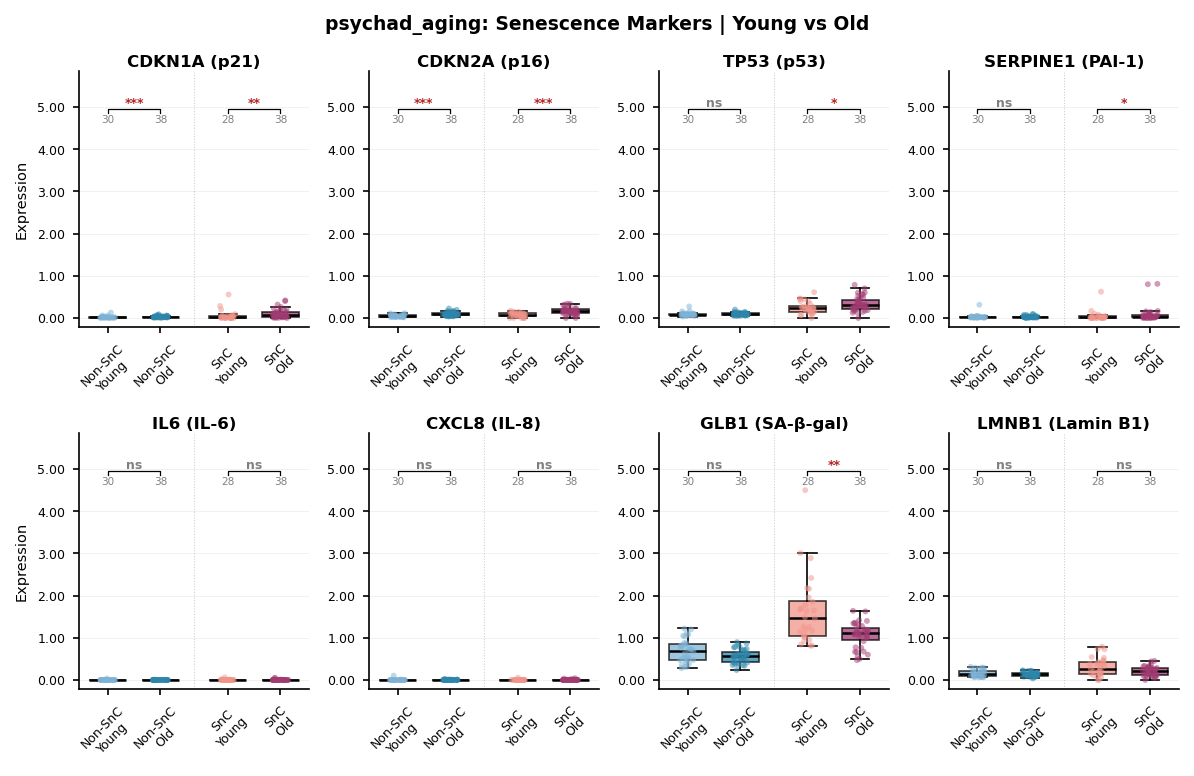


──────────────────────────────────────────────────────────────────────
VISUALIZATION 2: ALL CELLS
──────────────────────────────────────────────────────────────────────

✓ Saved: psychad_aging_part3c_markers_all_cells.pdf/.png


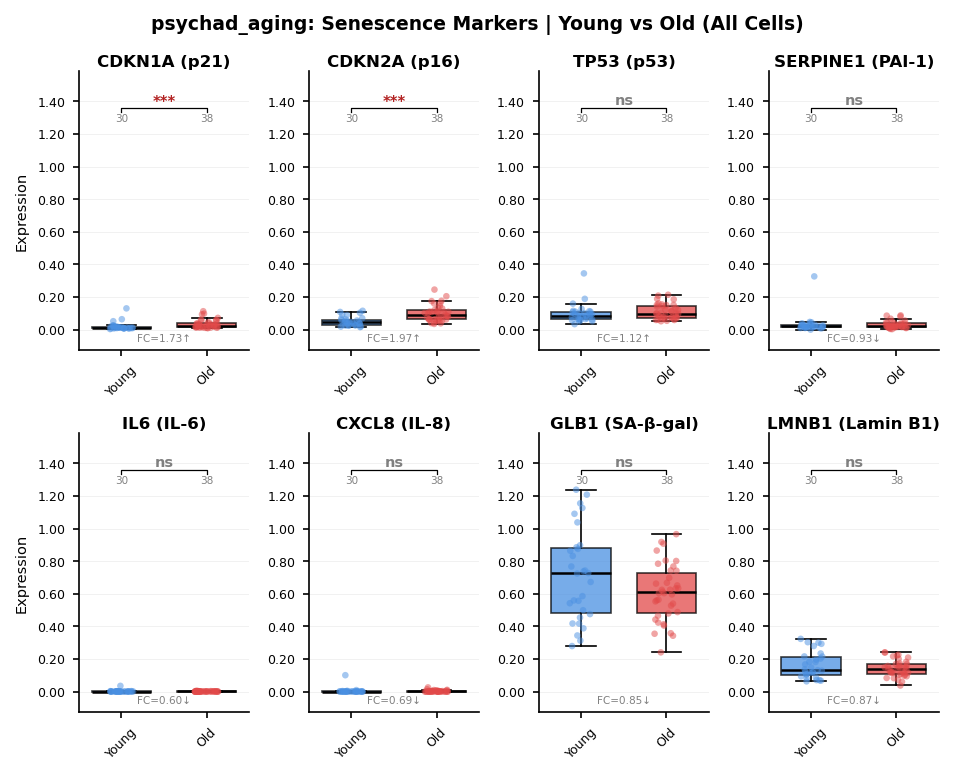


PART 3C COMPLETE

  Comparison: Young vs Old
  
  Stratified: 16 tests, 6 FDR-sig
  All cells:  8 tests, 2 FDR-sig
  
  Files: part3c_markers_stratified.csv, part3c_markers_all_cells.csv
         psychad_aging_part3c_markers_stratified.pdf/.png
         psychad_aging_part3c_markers_all_cells.pdf/.png



In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# PART 3C: SENESCENCE MARKER EXPRESSION - GROUP COMPARISON
# ════════════════════════════════════════════════════════════════════════════════
#
# Compare senescence marker expression between groups
#
# Analysis 1: Stratified by SnC status (4-group)
# Analysis 2: All cells combined (2-group)
#
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("PART 3C: SENESCENCE MARKER EXPRESSION BY GROUP")
print(f"{'='*70}")

# ─────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────────

SENESCENCE_MARKERS = {
    'CDKN1A': {'alias': 'p21', 'category': 'Cell Cycle Arrest'},
    'CDKN2A': {'alias': 'p16', 'category': 'Cell Cycle Arrest'},
    'TP53': {'alias': 'p53', 'category': 'Cell Cycle Arrest'},
    'SERPINE1': {'alias': 'PAI-1', 'category': 'SASP'},
    'IL6': {'alias': 'IL-6', 'category': 'SASP'},
    'CXCL8': {'alias': 'IL-8', 'category': 'SASP'},
    'GLB1': {'alias': 'SA-β-gal', 'category': 'Lysosomal'},
    'LMNB1': {'alias': 'Lamin B1', 'category': 'Nuclear'},
}

MIN_CELLS_PER_DONOR = 3

COLORS_3C = {
    f'NonSnC_{GROUP1_NAME}': '#7FB3D5',
    f'NonSnC_{GROUP2_NAME}': '#2E86AB',
    f'SnC_{GROUP1_NAME}': '#F1948A',
    f'SnC_{GROUP2_NAME}': '#A23B72',
}

COLORS_GROUP = {
    GROUP1_NAME: '#4A90E2',
    GROUP2_NAME: '#E24A4A',
}

# ─────────────────────────────────────────────────────────────────────────────────
# CHECK AVAILABLE MARKERS
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\nChecking marker availability...")

available_genes = set(adata.var_names)
available_markers = {g: info for g, info in SENESCENCE_MARKERS.items() if g in available_genes}
missing_markers = [g for g in SENESCENCE_MARKERS if g not in available_genes]

for gene in available_markers:
    print(f"  ✓ {gene} ({available_markers[gene]['alias']})")
for gene in missing_markers:
    print(f"  ✗ {gene} - not found")

print(f"\nAvailable: {len(available_markers)}/{len(SENESCENCE_MARKERS)} markers")

if len(available_markers) == 0:
    raise ValueError("No senescence markers found!")

marker_genes = list(available_markers.keys())

# ─────────────────────────────────────────────────────────────────────────────────
# PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*70}")
print("PREPARING DATA")
print(f"{'─'*70}")

mask_group1 = adata.obs[SRC_STUDYGROUP].isin(YOUNG_GROUPS)
mask_group2 = adata.obs[SRC_STUDYGROUP].isin(OLD_GROUPS)
mask_groups = mask_group1 | mask_group2

adata_subset = adata[mask_groups].copy()

print(f"\n  {GROUP1_NAME}: {YOUNG_GROUPS}")
print(f"  {GROUP2_NAME}: {OLD_GROUPS}")
print(f"  Total cells: {adata_subset.n_obs:,}")

adata_subset.obs['Group'] = np.where(
    adata_subset.obs[SRC_STUDYGROUP].isin(YOUNG_GROUPS), GROUP1_NAME, GROUP2_NAME
)
adata_subset.obs['SnC_Status'] = np.where(
    adata_subset.obs[SRC_SENESCENT] == True, 'SnC', 'Non-SnC'
)

print(f"\n  Cell counts:")
for grp in [GROUP1_NAME, GROUP2_NAME]:
    for ss in ['Non-SnC', 'SnC']:
        n_cells = ((adata_subset.obs['Group'] == grp) & (adata_subset.obs['SnC_Status'] == ss)).sum()
        n_donors = adata_subset.obs.loc[
            (adata_subset.obs['Group'] == grp) & (adata_subset.obs['SnC_Status'] == ss), SRC_DONOR
        ].nunique()
        print(f"    {grp} {ss}: {n_cells:,} cells, {n_donors} donors")

# ─────────────────────────────────────────────────────────────────────────────────
# EXTRACT EXPRESSION
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n  Extracting expression...")

from scipy.sparse import issparse

if issparse(adata_subset.X):
    expr_matrix = adata_subset[:, marker_genes].X.toarray()
else:
    expr_matrix = adata_subset[:, marker_genes].X

expr_df = pd.DataFrame(expr_matrix, index=adata_subset.obs_names, columns=marker_genes)
expr_df[SRC_DONOR] = adata_subset.obs[SRC_DONOR].values
expr_df['Group'] = adata_subset.obs['Group'].values
expr_df['SnC_Status'] = adata_subset.obs['SnC_Status'].values

# ─────────────────────────────────────────────────────────────────────────────────
# AGGREGATE - STRATIFIED
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n  Aggregating (stratified)...")

donor_agg_stratified = expr_df.groupby([SRC_DONOR, 'Group', 'SnC_Status']).agg(
    {**{gene: 'mean' for gene in marker_genes}, SRC_DONOR: 'size'}
).rename(columns={SRC_DONOR: 'n_cells'}).reset_index()

donor_agg_stratified = donor_agg_stratified[donor_agg_stratified['n_cells'] >= MIN_CELLS_PER_DONOR].copy()

print(f"  After filtering (≥{MIN_CELLS_PER_DONOR} cells):")
for grp in [GROUP1_NAME, GROUP2_NAME]:
    for ss in ['Non-SnC', 'SnC']:
        n = ((donor_agg_stratified['Group'] == grp) & (donor_agg_stratified['SnC_Status'] == ss)).sum()
        print(f"    {grp} {ss}: {n} donors")

# ─────────────────────────────────────────────────────────────────────────────────
# AGGREGATE - ALL CELLS
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n  Aggregating (all cells)...")

donor_agg_all = expr_df.groupby([SRC_DONOR, 'Group']).agg(
    {**{gene: 'mean' for gene in marker_genes}, SRC_DONOR: 'size'}
).rename(columns={SRC_DONOR: 'n_cells'}).reset_index()

donor_agg_all = donor_agg_all[donor_agg_all['n_cells'] >= MIN_CELLS_PER_DONOR].copy()

print(f"  After filtering (≥{MIN_CELLS_PER_DONOR} cells):")
for grp in [GROUP1_NAME, GROUP2_NAME]:
    n = (donor_agg_all['Group'] == grp).sum()
    print(f"    {grp}: {n} donors")

# ════════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1: STRATIFIED
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print("ANALYSIS 1: STRATIFIED BY SNC STATUS")
print(f"{'─'*70}")

results_3c_stratified = []

for gene in marker_genes:
    info = available_markers[gene]
    
    for snc_status in ['Non-SnC', 'SnC']:
        mask_status = donor_agg_stratified['SnC_Status'] == snc_status
        g1_vals = donor_agg_stratified.loc[mask_status & (donor_agg_stratified['Group'] == GROUP1_NAME), gene].values
        g2_vals = donor_agg_stratified.loc[mask_status & (donor_agg_stratified['Group'] == GROUP2_NAME), gene].values
        
        if len(g1_vals) < 3 or len(g2_vals) < 3:
            continue
        
        stat_u, p_val = mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
        
        n1, n2 = len(g1_vals), len(g2_vals)
        greater = sum(1 for x in g1_vals for y in g2_vals if x > y)
        less = sum(1 for x in g1_vals for y in g2_vals if x < y)
        cliff_d = (greater - less) / (n1 * n2)
        
        if abs(cliff_d) < 0.147:
            effect_label = 'negligible'
        elif abs(cliff_d) < 0.33:
            effect_label = 'small'
        elif abs(cliff_d) < 0.474:
            effect_label = 'medium'
        else:
            effect_label = 'large'
        
        mean_g1, mean_g2 = np.mean(g1_vals), np.mean(g2_vals)
        
        results_3c_stratified.append({
            'Gene': gene, 'Alias': info['alias'], 'Category': info['category'],
            'SnC_Status': snc_status,
            f'n_{GROUP1_NAME}': n1, f'n_{GROUP2_NAME}': n2,
            f'Mean_{GROUP1_NAME}': mean_g1, f'Mean_{GROUP2_NAME}': mean_g2,
            'Log2FC': np.log2(mean_g2 / mean_g1) if mean_g1 > 0 else np.nan,
            'U_statistic': stat_u, 'P_Value': p_val,
            'Cliff_Delta': cliff_d, 'Effect_Size': effect_label,
            'G1_Values': g1_vals, 'G2_Values': g2_vals
        })

df_results_3c_stratified = pd.DataFrame(results_3c_stratified)
df_results_3c_stratified['FDR'] = stats.false_discovery_control(df_results_3c_stratified['P_Value'], method='bh')
df_results_3c_stratified = df_results_3c_stratified.sort_values(['Gene', 'SnC_Status']).reset_index(drop=True)

print(f"\n  {'Gene':<10} {'Status':<8} {'n1':>4} {'n2':>4} {'Mean1':>7} {'Mean2':>7} {'log2FC':>7} {'δ':>6} {'p':>10} {'FDR':>10}")
print(f"  {'-'*90}")

for _, row in df_results_3c_stratified.iterrows():
    sig = "**" if row['FDR'] < 0.05 else "*" if row['P_Value'] < 0.05 else ""
    print(f"  {row['Gene']:<10} {row['SnC_Status']:<8} "
          f"{row[f'n_{GROUP1_NAME}']:>4} {row[f'n_{GROUP2_NAME}']:>4} "
          f"{row[f'Mean_{GROUP1_NAME}']:>7.2f} {row[f'Mean_{GROUP2_NAME}']:>7.2f} "
          f"{row['Log2FC']:>7.2f} {row['Cliff_Delta']:>6.2f} "
          f"{row['P_Value']:>10.2e} {row['FDR']:>10.2e}{sig}")

n_nom_strat = (df_results_3c_stratified['P_Value'] < 0.05).sum()
n_fdr_strat = (df_results_3c_stratified['FDR'] < 0.05).sum()
print(f"\n  Significant: {n_nom_strat} nominal, {n_fdr_strat} FDR")

# ════════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2: ALL CELLS
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print(f"ANALYSIS 2: ALL CELLS ({GROUP1_NAME} vs {GROUP2_NAME})")
print(f"{'─'*70}")

results_3c_all = []

for gene in marker_genes:
    info = available_markers[gene]
    
    g1_vals = donor_agg_all.loc[donor_agg_all['Group'] == GROUP1_NAME, gene].values
    g2_vals = donor_agg_all.loc[donor_agg_all['Group'] == GROUP2_NAME, gene].values
    
    if len(g1_vals) < 3 or len(g2_vals) < 3:
        continue
    
    stat_u, p_val = mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    
    n1, n2 = len(g1_vals), len(g2_vals)
    greater = sum(1 for x in g1_vals for y in g2_vals if x > y)
    less = sum(1 for x in g1_vals for y in g2_vals if x < y)
    cliff_d = (greater - less) / (n1 * n2)
    
    if abs(cliff_d) < 0.147:
        effect_label = 'negligible'
    elif abs(cliff_d) < 0.33:
        effect_label = 'small'
    elif abs(cliff_d) < 0.474:
        effect_label = 'medium'
    else:
        effect_label = 'large'
    
    mean_g1, mean_g2 = np.mean(g1_vals), np.mean(g2_vals)
    
    results_3c_all.append({
        'Gene': gene, 'Alias': info['alias'], 'Category': info['category'],
        f'n_{GROUP1_NAME}': n1, f'n_{GROUP2_NAME}': n2,
        f'Mean_{GROUP1_NAME}': mean_g1, f'Mean_{GROUP2_NAME}': mean_g2,
        'Log2FC': np.log2(mean_g2 / mean_g1) if mean_g1 > 0 else np.nan,
        'U_statistic': stat_u, 'P_Value': p_val,
        'Cliff_Delta': cliff_d, 'Effect_Size': effect_label,
        'G1_Values': g1_vals, 'G2_Values': g2_vals
    })

df_results_3c_all = pd.DataFrame(results_3c_all)
df_results_3c_all['FDR'] = stats.false_discovery_control(df_results_3c_all['P_Value'], method='bh')
df_results_3c_all = df_results_3c_all.sort_values('P_Value').reset_index(drop=True)

print(f"\n  {'Gene':<10} {'Alias':<8} {'n1':>4} {'n2':>4} {'Mean1':>7} {'Mean2':>7} {'log2FC':>7} {'δ':>6} {'p':>10} {'FDR':>10}")
print(f"  {'-'*90}")

for _, row in df_results_3c_all.iterrows():
    sig = "**" if row['FDR'] < 0.05 else "*" if row['P_Value'] < 0.05 else ""
    print(f"  {row['Gene']:<10} {row['Alias']:<8} "
          f"{row[f'n_{GROUP1_NAME}']:>4} {row[f'n_{GROUP2_NAME}']:>4} "
          f"{row[f'Mean_{GROUP1_NAME}']:>7.2f} {row[f'Mean_{GROUP2_NAME}']:>7.2f} "
          f"{row['Log2FC']:>7.2f} {row['Cliff_Delta']:>6.2f} "
          f"{row['P_Value']:>10.2e} {row['FDR']:>10.2e}{sig}")

n_nom_all = (df_results_3c_all['P_Value'] < 0.05).sum()
n_fdr_all = (df_results_3c_all['FDR'] < 0.05).sum()
print(f"\n  Significant: {n_nom_all} nominal, {n_fdr_all} FDR")

# ─────────────────────────────────────────────────────────────────────────────────
# SAVE RESULTS
# ─────────────────────────────────────────────────────────────────────────────────

df_results_3c_stratified_export = df_results_3c_stratified.drop(columns=['G1_Values', 'G2_Values'])
df_results_3c_all_export = df_results_3c_all.drop(columns=['G1_Values', 'G2_Values'])

df_results_3c_stratified_export.to_csv(RESULTS_DIR / 'part3c_markers_stratified.csv', index=False)
df_results_3c_all_export.to_csv(RESULTS_DIR / 'part3c_markers_all_cells.csv', index=False)

print(f"\n✓ Saved: part3c_markers_stratified.csv, part3c_markers_all_cells.csv")

df_results_3c_export = df_results_3c_stratified_export.copy()

# ════════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 1: STRATIFIED (4-GROUP)
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print("VISUALIZATION 1: STRATIFIED")
print(f"{'─'*70}")

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 600,
})

n_markers = len(marker_genes)
n_cols = 4
n_rows = int(np.ceil(n_markers / n_cols))

# Global y-limits
global_ymin = np.inf
global_ymax = -np.inf
for gene in marker_genes:
    for snc_status, grp in [('Non-SnC', GROUP1_NAME), ('Non-SnC', GROUP2_NAME), 
                             ('SnC', GROUP1_NAME), ('SnC', GROUP2_NAME)]:
        mask = (donor_agg_stratified['SnC_Status'] == snc_status) & (donor_agg_stratified['Group'] == grp)
        vals = donor_agg_stratified.loc[mask, gene].values
        if len(vals) > 0:
            global_ymin = min(global_ymin, np.min(vals))
            global_ymax = max(global_ymax, np.max(vals))

y_range = global_ymax - global_ymin
y_lim = (global_ymin - y_range * 0.05, global_ymax + y_range * 0.30)

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.6 * n_rows))
axes1 = axes1.flatten() if n_markers > 1 else [axes1]

for idx, gene in enumerate(marker_genes):
    ax = axes1[idx]
    info = available_markers[gene]
    gene_results = df_results_3c_stratified[df_results_3c_stratified['Gene'] == gene]
    
    group_data, group_n = [], []
    group_labels = [f'Non-SnC\n{GROUP1_NAME}', f'Non-SnC\n{GROUP2_NAME}', 
                    f'SnC\n{GROUP1_NAME}', f'SnC\n{GROUP2_NAME}']
    group_colors = [COLORS_3C[f'NonSnC_{GROUP1_NAME}'], COLORS_3C[f'NonSnC_{GROUP2_NAME}'], 
                    COLORS_3C[f'SnC_{GROUP1_NAME}'], COLORS_3C[f'SnC_{GROUP2_NAME}']]
    
    for snc_status, grp in [('Non-SnC', GROUP1_NAME), ('Non-SnC', GROUP2_NAME), 
                             ('SnC', GROUP1_NAME), ('SnC', GROUP2_NAME)]:
        mask = (donor_agg_stratified['SnC_Status'] == snc_status) & (donor_agg_stratified['Group'] == grp)
        vals = donor_agg_stratified.loc[mask, gene].values
        group_data.append(vals)
        group_n.append(len(vals))
    
    positions = [0, 0.55, 1.25, 1.8]
    
    bp = ax.boxplot(group_data, positions=positions, widths=0.38, patch_artist=True, showfliers=False, zorder=2)
    
    for patch, color in zip(bp['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('black')
        patch.set_linewidth(0.8)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)
    
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(0.8)
    
    np.random.seed(42 + idx)
    for i, (pos, vals, color) in enumerate(zip(positions, group_data, group_colors)):
        if len(vals) > 0:
            jitter = np.random.uniform(-0.08, 0.08, len(vals))
            ax.scatter(pos + jitter, vals, color=color, s=8, alpha=0.5, edgecolor='none', zorder=3)
    
    for i, (pos, n) in enumerate(zip(positions, group_n)):
        ax.text(pos, global_ymax + y_range * 0.02, f'{n}', ha='center', va='bottom', fontsize=5, color='gray')
    
    # Non-SnC bracket
    nonsnc_row = gene_results[gene_results['SnC_Status'] == 'Non-SnC']
    if len(nonsnc_row) > 0:
        p_val = nonsnc_row['P_Value'].values[0]
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        bracket_y = global_ymax + y_range * 0.10
        ax.plot([0, 0, 0.55, 0.55], [bracket_y - y_range*0.02, bracket_y, bracket_y, bracket_y - y_range*0.02], 
               color='black', linewidth=0.6)
        ax.text(0.275, bracket_y, stars, ha='center', va='bottom', fontsize=6, fontweight='bold',
               color='#B22222' if p_val < 0.05 else 'gray')
    
    # SnC bracket
    snc_row = gene_results[gene_results['SnC_Status'] == 'SnC']
    if len(snc_row) > 0:
        p_val = snc_row['P_Value'].values[0]
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        bracket_y = global_ymax + y_range * 0.10
        ax.plot([1.25, 1.25, 1.8, 1.8], [bracket_y - y_range*0.02, bracket_y, bracket_y, bracket_y - y_range*0.02], 
               color='black', linewidth=0.6)
        ax.text(1.525, bracket_y, stars, ha='center', va='bottom', fontsize=6, fontweight='bold',
               color='#B22222' if p_val < 0.05 else 'gray')
    
    ax.set_title(f'{gene} ({info["alias"]})', fontweight='bold', fontsize=8, pad=2)
    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels, fontsize=5, rotation=45, ha='center')
    if idx % n_cols == 0:
        ax.set_ylabel('Expression', fontsize=7)
    ax.set_ylim(y_lim)
    ax.set_xlim(-0.3, 2.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.axvline(x=0.9, color='gray', linestyle=':', alpha=0.4, linewidth=0.5)
    ax.yaxis.grid(True, alpha=0.2, linestyle='-', linewidth=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=6)

for idx in range(n_markers, len(axes1)):
    axes1[idx].set_visible(False)

plt.suptitle(f'{DATASET}: Senescence Markers | {GROUP1_NAME} vs {GROUP2_NAME}',
            fontsize=9, fontweight='bold')

plt.tight_layout()

fig1.savefig(FIGURES_DIR / f'{DATASET}_part3c_markers_stratified.pdf', format='pdf', bbox_inches='tight', dpi=600)
fig1.savefig(FIGURES_DIR / f'{DATASET}_part3c_markers_stratified.png', format='png', bbox_inches='tight', dpi=600)
print(f"\n✓ Saved: {DATASET}_part3c_markers_stratified.pdf/.png")
plt.show()
plt.close(fig1)

# ════════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 2: ALL CELLS (2-GROUP)
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print(f"VISUALIZATION 2: ALL CELLS")
print(f"{'─'*70}")

# Global y-limits
global_ymin2 = np.inf
global_ymax2 = -np.inf
for gene in marker_genes:
    for grp in [GROUP1_NAME, GROUP2_NAME]:
        vals = donor_agg_all.loc[donor_agg_all['Group'] == grp, gene].values
        if len(vals) > 0:
            global_ymin2 = min(global_ymin2, np.min(vals))
            global_ymax2 = max(global_ymax2, np.max(vals))

y_range2 = global_ymax2 - global_ymin2
y_lim2 = (global_ymin2 - y_range2 * 0.10, global_ymax2 + y_range2 * 0.28)

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(1.6 * n_cols, 2.6 * n_rows))
axes2 = axes2.flatten() if n_markers > 1 else [axes2]

for idx, gene in enumerate(marker_genes):
    ax = axes2[idx]
    info = available_markers[gene]
    gene_result = df_results_3c_all[df_results_3c_all['Gene'] == gene]
    
    g1_vals = donor_agg_all.loc[donor_agg_all['Group'] == GROUP1_NAME, gene].values
    g2_vals = donor_agg_all.loc[donor_agg_all['Group'] == GROUP2_NAME, gene].values
    
    positions = [0, 0.5]
    
    bp = ax.boxplot([g1_vals, g2_vals], positions=positions, widths=0.35, patch_artist=True, showfliers=False, zorder=2)
    
    for patch, color in zip(bp['boxes'], [COLORS_GROUP[GROUP1_NAME], COLORS_GROUP[GROUP2_NAME]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('black')
        patch.set_linewidth(0.8)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)
    
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(0.8)
    
    np.random.seed(42 + idx)
    jitter1 = np.random.uniform(-0.07, 0.07, len(g1_vals))
    jitter2 = np.random.uniform(-0.07, 0.07, len(g2_vals))
    ax.scatter(0 + jitter1, g1_vals, color=COLORS_GROUP[GROUP1_NAME], s=10, alpha=0.5, edgecolor='none', zorder=3)
    ax.scatter(0.5 + jitter2, g2_vals, color=COLORS_GROUP[GROUP2_NAME], s=10, alpha=0.5, edgecolor='none', zorder=3)
    
    ax.text(0, global_ymax2 + y_range2 * 0.02, f'{len(g1_vals)}', ha='center', va='bottom', fontsize=5, color='gray')
    ax.text(0.5, global_ymax2 + y_range2 * 0.02, f'{len(g2_vals)}', ha='center', va='bottom', fontsize=5, color='gray')
    
    if len(gene_result) > 0:
        p_val = gene_result['P_Value'].values[0]
        log2fc = gene_result['Log2FC'].values[0]
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        
        bracket_y = global_ymax2 + y_range2 * 0.10
        ax.plot([0, 0, 0.5, 0.5], [bracket_y - y_range2*0.02, bracket_y, bracket_y, bracket_y - y_range2*0.02], 
               color='black', linewidth=0.6)
        ax.text(0.25, bracket_y, stars, ha='center', va='bottom', fontsize=7, fontweight='bold',
               color='#B22222' if p_val < 0.05 else 'gray')
        
        direction = '↑' if log2fc > 0 else '↓'
        ax.text(0.25, global_ymin2 - y_range2 * 0.02, f'FC={2**log2fc:.2f}{direction}', 
               ha='center', va='top', fontsize=5, color='gray')
    
    ax.set_title(f'{gene} ({info["alias"]})', fontweight='bold', fontsize=8, pad=2)
    ax.set_xticks(positions)
    ax.set_xticklabels([GROUP1_NAME, GROUP2_NAME], fontsize=6, rotation=45, ha='center')
    if idx % n_cols == 0:
        ax.set_ylabel('Expression', fontsize=7)
    ax.set_ylim(y_lim2)
    ax.set_xlim(-0.25, 0.75)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.yaxis.grid(True, alpha=0.2, linestyle='-', linewidth=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=6)

for idx in range(n_markers, len(axes2)):
    axes2[idx].set_visible(False)

plt.suptitle(f'{DATASET}: Senescence Markers | {GROUP1_NAME} vs {GROUP2_NAME} (All Cells)',
            fontsize=9, fontweight='bold')

plt.tight_layout()

fig2.savefig(FIGURES_DIR / f'{DATASET}_part3c_markers_all_cells.pdf', format='pdf', bbox_inches='tight', dpi=600)
fig2.savefig(FIGURES_DIR / f'{DATASET}_part3c_markers_all_cells.png', format='png', bbox_inches='tight', dpi=600)
print(f"\n✓ Saved: {DATASET}_part3c_markers_all_cells.pdf/.png")
plt.show()
plt.close(fig2)

plt.rcParams.update(plt.rcParamsDefault)

# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("PART 3C COMPLETE")
print(f"{'='*70}")

print(f"""
  Comparison: {GROUP1_NAME} vs {GROUP2_NAME}
  
  Stratified: {len(df_results_3c_stratified)} tests, {n_fdr_strat} FDR-sig
  All cells:  {len(df_results_3c_all)} tests, {n_fdr_all} FDR-sig
  
  Files: part3c_markers_stratified.csv, part3c_markers_all_cells.csv
         {DATASET}_part3c_markers_stratified.pdf/.png
         {DATASET}_part3c_markers_all_cells.pdf/.png
""")

In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# EXPORT ALL RESULTS
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("EXPORT RESULTS")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# CHECK AVAILABLE RESULTS
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("AVAILABLE RESULTS")
print(f"{'─'*60}")

# Check what objects are available
has_2a = 'df_results_2a' in dir() and len(df_results_2a) > 0 if 'df_results_2a' in dir() else False
has_2b_groupA = 'df_results_2b_groupA' in dir() and len(df_results_2b_groupA) > 0 if 'df_results_2b_groupA' in dir() else False
has_2b_groupB = 'df_results_2b_groupB' in dir() and len(df_results_2b_groupB) > 0 if 'df_results_2b_groupB' in dir() else False
has_df_plot = 'df_plot' in dir() and len(df_plot) > 0 if 'df_plot' in dir() else False
has_3a = 'df_results_3a' in dir() and len(df_results_3a) > 0 if 'df_results_3a' in dir() else False
has_3b = 'df_results_3b' in dir() and len(df_results_3b) > 0 if 'df_results_3b' in dir() else False
has_3c = 'df_results_3c_export' in dir() and len(df_results_3c_export) > 0 if 'df_results_3c_export' in dir() else False

results_available = {
    'Part 2A': has_2a,
    'Part 2B': has_df_plot or (has_2b_groupA or has_2b_groupB),
    'Part 3A': has_3a,
    'Part 3B': has_3b,
    'Part 3C': has_3c,
}

print(f"\n  Available results:")
for part, available in results_available.items():
    status = "✓" if available else "✗"
    print(f"    {status} {part}")

# ─────────────────────────────────────────────────────────────────────────────────
# TABLE 1: Cell Type Statistics
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 1: CELL TYPE STATISTICS")
print(f"{'─'*60}")

ct_summary = df_donor_ct.groupby(COL_CELLTYPE).agg({
    'n_cells': ['sum', 'mean', 'std'],
    'prop_snc': ['mean', 'std', lambda x: (x == 0).mean() * 100],
    COL_DONOR: 'nunique'
}).reset_index()

ct_summary.columns = [
    COL_CELLTYPE, 
    'total_cells', 'mean_cells_per_donor', 'std_cells_per_donor',
    'mean_pct_snc', 'std_pct_snc', 'pct_donors_zero',
    'n_donors'
]

ct_summary['mean_pct_snc'] = ct_summary['mean_pct_snc'] * 100
ct_summary['std_pct_snc'] = ct_summary['std_pct_snc'] * 100
ct_summary = ct_summary.sort_values('mean_pct_snc', ascending=False).reset_index(drop=True)

print(f"\n  {COL_CELLTYPE:<18} {'N Donors':>8} {'Total Cells':>12} {'Mean±SD Cells':>16} {'Mean±SD %SnC':>16} {'%Zero':>8}")
print(f"  {'-'*80}")

for _, row in ct_summary.iterrows():
    cells_str = f"{row['mean_cells_per_donor']:.0f}±{row['std_cells_per_donor']:.0f}"
    snc_str = f"{row['mean_pct_snc']:.2f}±{row['std_pct_snc']:.2f}"
    print(f"  {row[COL_CELLTYPE]:<18} {row['n_donors']:>8} {row['total_cells']:>12,.0f} {cells_str:>16} {snc_str:>16} {row['pct_donors_zero']:>8.1f}")

ct_summary.to_csv(RESULTS_DIR / f'{DATASET}_table1_celltype_statistics.csv', index=False)
print(f"\n  ✓ Saved: {DATASET}_table1_celltype_statistics.csv")

# ─────────────────────────────────────────────────────────────────────────────────
# TABLE 2: Beta Regression Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 2: BETA REGRESSION RESULTS (Age Effect)")
print(f"{'─'*60}")

df_table2 = None

if has_2a or has_df_plot:
    
    # Use df_plot if available (has FDR), otherwise use raw results
    if has_df_plot:
        df_part2_ct = df_plot.copy()
        
        # Add Overall from df_results_2a if available
        if has_2a:
            df_overall = df_results_2a.iloc[[0]].copy()
            df_overall['group'] = 'B' if df_overall['model_type'].values[0] == 'beta' else 'A'
            df_overall['cond_fdr'] = np.nan
            if 'mean_snc' not in df_overall.columns:
                df_overall['mean_snc'] = df_donor['prop_snc'].mean() * 100
            df_part2_combined = pd.concat([df_overall, df_part2_ct], ignore_index=True)
        else:
            df_part2_combined = df_part2_ct
    elif has_2a:
        df_part2_combined = df_results_2a.copy()
        df_part2_combined['group'] = 'B'
        df_part2_combined['cond_fdr'] = np.nan
        if 'mean_snc' not in df_part2_combined.columns:
            df_part2_combined['mean_snc'] = df_donor['prop_snc'].mean() * 100
    
    if 'cond_beta' in df_part2_combined.columns:
        
        # Select columns for table
        table2_cols = [COL_CELLTYPE]
        for col in ['n_obs', 'mean_snc', 'pct_zeros', 'group',
                    'cond_beta', 'cond_se', 'cond_exp_beta', 'cond_exp_lower', 'cond_exp_upper', 
                    'cond_p', 'cond_fdr']:
            if col in df_part2_combined.columns:
                table2_cols.append(col)
        
        df_table2 = df_part2_combined[table2_cols].copy()
        
        # Rename columns for cleaner output
        rename_map = {
            'mean_snc': 'mean_prop',
            'cond_beta': 'beta', 'cond_se': 'SE',
            'cond_exp_beta': 'OR', 'cond_exp_lower': 'OR_lower',
            'cond_exp_upper': 'OR_upper', 'cond_p': 'p_value',
            'cond_fdr': 'FDR'
        }
        df_table2 = df_table2.rename(columns={k: v for k, v in rename_map.items() if k in df_table2.columns})
        
        # Sort: Overall first, then by p-value
        df_table2['sort_key'] = df_table2[COL_CELLTYPE].apply(lambda x: 0 if x == 'Overall' else 1)
        df_table2 = df_table2.sort_values(['sort_key', 'p_value']).drop(columns='sort_key').reset_index(drop=True)
        
        # Print header
        header_parts = [f"{COL_CELLTYPE:<18}"]
        if 'n_obs' in df_table2.columns:
            header_parts.append(f"{'N':>5}")
        if 'mean_prop' in df_table2.columns:
            header_parts.append(f"{'%SnC':>6}")
        if 'pct_zeros' in df_table2.columns:
            header_parts.append(f"{'%Zero':>6}")
        if 'group' in df_table2.columns:
            header_parts.append(f"{'Grp':>4}")
        header_parts.extend([f"{'β':>7}", f"{'SE':>6}", f"{'OR':>6}", f"{'95% CI':>16}", f"{'p':>10}"])
        if 'FDR' in df_table2.columns:
            header_parts.append(f"{'FDR':>10}")
        
        print(f"\n  {' '.join(header_parts)}")
        print(f"  {'-'*115}")
        
        for _, row in df_table2.iterrows():
            ci_str = f"({row['OR_lower']:.2f}-{row['OR_upper']:.2f})" if pd.notna(row.get('OR_lower')) else "--"
            fdr_str = f"{row['FDR']:.2e}" if 'FDR' in row and pd.notna(row.get('FDR')) else "--"
            grp_str = str(row.get('group', '--')) if 'group' in row else '--'
            sig = "**" if row.get('FDR', 1) < 0.05 else "*" if row.get('p_value', 1) < 0.05 else ""
            
            line_parts = [f"{row[COL_CELLTYPE]:<18}"]
            if 'n_obs' in df_table2.columns:
                line_parts.append(f"{row['n_obs']:>5.0f}")
            if 'mean_prop' in df_table2.columns:
                line_parts.append(f"{row['mean_prop']:>6.1f}")
            if 'pct_zeros' in df_table2.columns:
                line_parts.append(f"{row['pct_zeros']:>6.1f}")
            if 'group' in df_table2.columns:
                line_parts.append(f"{grp_str:>4}")
            line_parts.extend([
                f"{row['beta']:>7.3f}", f"{row['SE']:>6.3f}", f"{row['OR']:>6.2f}",
                f"{ci_str:>16}", f"{row['p_value']:>10.2e}"
            ])
            if 'FDR' in df_table2.columns:
                line_parts.append(f"{fdr_str:>10}{sig}")
            else:
                line_parts[-1] += sig
            
            print(f"  {' '.join(line_parts)}")
        
        df_table2.to_csv(RESULTS_DIR / f'{DATASET}_table2_beta_regression.csv', index=False)
        print(f"\n  ✓ Saved: {DATASET}_table2_beta_regression.csv")
    else:
        print("\n  ⚠ Expected columns (cond_beta, etc.) not found in Part 2 results")
else:
    print("\n  ⚠ Part 2 results not available")

# ─────────────────────────────────────────────────────────────────────────────────
# TABLE 3: Group Comparison Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 3: GROUP COMPARISON RESULTS")
print(f"{'─'*60}")

df_table3 = None

if has_3a or has_3b:
    
    rows_to_combine = []
    
    # Get group names
    g1_name = GROUP1_NAME if 'GROUP1_NAME' in dir() else 'Group1'
    g2_name = GROUP2_NAME if 'GROUP2_NAME' in dir() else 'Group2'
    
    if has_3a:
        overall_row = {
            COL_CELLTYPE: 'Overall',
            'n_group1': df_results_3a['n_group1'].values[0],
            'n_group2': df_results_3a['n_group2'].values[0],
            'mean_group1': df_results_3a['mean_group1'].values[0],
            'mean_group2': df_results_3a['mean_group2'].values[0],
            'cliff_delta': df_results_3a['cliff_delta'].values[0],
            'effect_size': df_results_3a['effect_size'].values[0],
            'p_value': df_results_3a['p_value'].values[0],
            'FDR': np.nan
        }
        rows_to_combine.append(pd.DataFrame([overall_row]))
    
    if has_3b:
        rows_to_combine.append(df_results_3b)
    
    df_table3 = pd.concat(rows_to_combine, ignore_index=True)
    
    table3_cols = [COL_CELLTYPE, 'n_group1', 'n_group2', 'mean_group1', 'mean_group2', 
                   'cliff_delta', 'effect_size', 'p_value', 'FDR']
    df_table3 = df_table3[[c for c in table3_cols if c in df_table3.columns]]
    
    df_table3['sort_key'] = df_table3[COL_CELLTYPE].apply(lambda x: 0 if x == 'Overall' else 1)
    df_table3 = df_table3.sort_values(['sort_key', 'p_value']).drop(columns='sort_key').reset_index(drop=True)
    
    print(f"\n  Comparison: {g1_name} vs {g2_name}")
    print(f"\n  {COL_CELLTYPE:<18} {'n1':>4} {'n2':>4} {'Mean1':>7} {'Mean2':>7} {'δ':>7} {'Effect':>10} {'p':>10} {'FDR':>10}")
    print(f"  {'-'*90}")
    
    for _, row in df_table3.iterrows():
        fdr_str = f"{row['FDR']:.2e}" if pd.notna(row['FDR']) else "--"
        sig = "**" if row.get('FDR', 1) < 0.05 else "*" if row['p_value'] < 0.05 else ""
        print(f"  {row[COL_CELLTYPE]:<18} {row['n_group1']:>4.0f} {row['n_group2']:>4.0f} "
              f"{row['mean_group1']:>7.2f} {row['mean_group2']:>7.2f} "
              f"{row['cliff_delta']:>7.3f} {row['effect_size']:>10} "
              f"{row['p_value']:>10.2e} {fdr_str:>10}{sig}")
    
    df_table3.to_csv(RESULTS_DIR / f'{DATASET}_table3_group_comparison.csv', index=False)
    print(f"\n  ✓ Saved: {DATASET}_table3_group_comparison.csv")
else:
    print("\n  ⚠ Part 3A/3B results not available")

# ─────────────────────────────────────────────────────────────────────────────────
# TABLE 4: Marker Expression by Age Group (Part 3C)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 4: MARKER EXPRESSION BY AGE GROUP")
print(f"{'─'*60}")

df_table4 = None

if has_3c:
    
    df_table4 = df_results_3c_export.copy()
    
    g1_name = GROUP1_NAME if 'GROUP1_NAME' in dir() else 'Group1'
    g2_name = GROUP2_NAME if 'GROUP2_NAME' in dir() else 'Group2'
    
    print(f"\n  Comparison: {g1_name} vs {g2_name}")
    print(f"\n  {'Gene':<10} {'Status':<8} {'n_Y':>4} {'n_O':>4} {'Mean_Y':>8} {'Mean_O':>8} {'log2FC':>7} {'δ':>7} {'p':>10} {'FDR':>10}")
    print(f"  {'-'*95}")
    
    for _, row in df_table4.iterrows():
        sig = "**" if row['FDR'] < 0.05 else "*" if row['P_Value'] < 0.05 else ""
        print(f"  {row['Gene']:<10} {row['SnC_Status']:<8} {row['n_Young']:>4} {row['n_Old']:>4} "
              f"{row['Mean_Young']:>8.3f} {row['Mean_Old']:>8.3f} {row['Log2FC']:>7.2f} "
              f"{row['Cliff_Delta']:>7.3f} {row['P_Value']:>10.2e} {row['FDR']:>10.2e}{sig}")
    
    df_table4.to_csv(RESULTS_DIR / f'{DATASET}_table4_marker_expression.csv', index=False)
    print(f"\n  ✓ Saved: {DATASET}_table4_marker_expression.csv")
else:
    print("\n  ⚠ Part 3C results not available")

# ─────────────────────────────────────────────────────────────────────────────────
# MASTER SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("MASTER SUMMARY TABLE")
print(f"{'─'*60}")

df_master = ct_summary.copy()

if df_table2 is not None and results_available['Part 2B']:
    part2_cols = [COL_CELLTYPE]
    for col in ['group', 'beta', 'SE', 'OR', 'OR_lower', 'OR_upper', 'p_value', 'FDR']:
        if col in df_table2.columns:
            part2_cols.append(col)
    
    df_part2_ct = df_table2[df_table2[COL_CELLTYPE] != 'Overall'][part2_cols].copy()
    df_part2_ct.columns = [COL_CELLTYPE] + [f'part2_{c}' for c in part2_cols[1:]]
    df_master = df_master.merge(df_part2_ct, on=COL_CELLTYPE, how='left')

if df_table3 is not None and has_3b:
    part3_cols = [COL_CELLTYPE]
    for col in ['mean_group1', 'mean_group2', 'cliff_delta', 'effect_size', 'p_value', 'FDR']:
        if col in df_table3.columns:
            part3_cols.append(col)
    
    df_part3_ct = df_table3[df_table3[COL_CELLTYPE] != 'Overall'][part3_cols].copy()
    df_part3_ct.columns = [COL_CELLTYPE] + [f'part3_{c}' for c in part3_cols[1:]]
    df_master = df_master.merge(df_part3_ct, on=COL_CELLTYPE, how='left')

df_master = df_master.sort_values('mean_pct_snc', ascending=False).reset_index(drop=True)

df_master.to_csv(RESULTS_DIR / f'{DATASET}_master_summary.csv', index=False)
print(f"\n  ✓ Saved: {DATASET}_master_summary.csv")
print(f"    Columns: {list(df_master.columns)}")

# ─────────────────────────────────────────────────────────────────────────────────
# EXCEL WORKBOOK
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("EXCEL WORKBOOK")
print(f"{'─'*60}")

try:
    excel_path = RESULTS_DIR / f'{DATASET}_all_results.xlsx'
    
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        
        ct_summary.to_excel(writer, sheet_name='CellType_Stats', index=False)
        
        if df_table2 is not None:
            df_table2.to_excel(writer, sheet_name='BetaRegression', index=False)
        
        if df_table3 is not None:
            df_table3.to_excel(writer, sheet_name='GroupComparison', index=False)
        
        if df_table4 is not None:
            df_table4.to_excel(writer, sheet_name='MarkerExpression', index=False)
        
        df_master.to_excel(writer, sheet_name='Master_Summary', index=False)
        
        # Raw data sheets
        if has_2a:
            df_results_2a.to_excel(writer, sheet_name='Part2A_Raw', index=False)
        if has_df_plot:
            df_plot.to_excel(writer, sheet_name='Part2B_Raw', index=False)
        elif has_2b_groupA or has_2b_groupB:
            if has_2b_groupA:
                df_results_2b_groupA.to_excel(writer, sheet_name='Part2B_GroupA_Raw', index=False)
            if has_2b_groupB:
                df_results_2b_groupB.to_excel(writer, sheet_name='Part2B_GroupB_Raw', index=False)
        if has_3b:
            df_results_3b.to_excel(writer, sheet_name='Part3B_Raw', index=False)
        if has_3c:
            df_results_3c_export.to_excel(writer, sheet_name='Part3C_Raw', index=False)
    
    print(f"\n  ✓ Saved: {DATASET}_all_results.xlsx")

except Exception as e:
    print(f"\n  ⚠ Could not create Excel file: {e}")

# ─────────────────────────────────────────────────────────────────────────────────
# SUMMARY STATISTICS FOR MANUSCRIPT
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY STATISTICS FOR MANUSCRIPT")
print(f"{'─'*60}")

print(f"\n  Dataset: {DATASET}")
print(f"\n  Sample size:")
print(f"    Total cells: {df_donor_ct['n_cells'].sum():,}")
print(f"    Total donors: {len(df_donor)}")
print(f"    Cell types: {df_donor_ct[COL_CELLTYPE].nunique()}")

print(f"\n  Overall senescence:")
print(f"    Mean: {df_donor['prop_snc'].mean()*100:.2f}%")
print(f"    Median: {df_donor['prop_snc'].median()*100:.2f}%")
print(f"    Range: {df_donor['prop_snc'].min()*100:.2f}% - {df_donor['prop_snc'].max()*100:.2f}%")

if has_2a and df_table2 is not None:
    print(f"\n  Part 2A (Overall beta regression):")
    overall_rows = df_table2[df_table2[COL_CELLTYPE] == 'Overall']
    if len(overall_rows) > 0:
        overall_row = overall_rows.iloc[0]
        grp = overall_row.get('group', '--') if 'group' in overall_row else '--'
        model_desc = 'ZI Beta' if grp == 'A' else 'Standard Beta'
        print(f"    Model: {model_desc} (Group {grp})")
        if 'beta' in overall_row and pd.notna(overall_row['beta']):
            print(f"    β = {overall_row['beta']:.3f} (SE = {overall_row['SE']:.3f})")
            print(f"    OR = {overall_row['OR']:.2f} (95% CI: {overall_row['OR_lower']:.2f}-{overall_row['OR_upper']:.2f})")
            print(f"    p = {overall_row['p_value']:.2e}")

if results_available['Part 2B'] and df_table2 is not None:
    df_part2b_only = df_table2[df_table2[COL_CELLTYPE] != 'Overall']
    
    if len(df_part2b_only) > 0:
        n_sig_part2 = (df_part2b_only['FDR'] < 0.05).sum() if 'FDR' in df_part2b_only.columns else 0
        n_nom_part2 = (df_part2b_only['p_value'] < 0.05).sum() if 'p_value' in df_part2b_only.columns else 0
        
        n_group_a = (df_part2b_only['group'] == 'A').sum() if 'group' in df_part2b_only.columns else 0
        n_group_b = (df_part2b_only['group'] == 'B').sum() if 'group' in df_part2b_only.columns else 0
        
        print(f"\n  Part 2B (Per cell type beta regression):")
        if n_group_a > 0 or n_group_b > 0:
            print(f"    Group A (ZI Beta): {n_group_a} cell types")
            print(f"    Group B (Standard): {n_group_b} cell types")
        print(f"    Significant (FDR<0.05): {n_sig_part2}/{len(df_part2b_only)} cell types")
        print(f"    Nominal (p<0.05): {n_nom_part2}/{len(df_part2b_only)} cell types")
        
        # List significant cell types
        if n_sig_part2 > 0:
            sig_cts = df_part2b_only[df_part2b_only['FDR'] < 0.05][COL_CELLTYPE].tolist()
            print(f"    FDR-significant: {', '.join(sig_cts)}")

if has_3a:
    g1_name = GROUP1_NAME if 'GROUP1_NAME' in dir() else 'Group1'
    g2_name = GROUP2_NAME if 'GROUP2_NAME' in dir() else 'Group2'
    
    print(f"\n  Part 3A (Overall group comparison):")
    print(f"    {g1_name} (n={df_results_3a['n_group1'].values[0]}): {df_results_3a['mean_group1'].values[0]:.2f}%")
    print(f"    {g2_name} (n={df_results_3a['n_group2'].values[0]}): {df_results_3a['mean_group2'].values[0]:.2f}%")
    print(f"    p = {df_results_3a['p_value'].values[0]:.2e}, δ = {df_results_3a['cliff_delta'].values[0]:.3f} ({df_results_3a['effect_size'].values[0]})")

if has_3b:
    n_sig_part3 = (df_results_3b['FDR'] < 0.05).sum()
    n_nom_part3 = (df_results_3b['p_value'] < 0.05).sum()
    print(f"\n  Part 3B (Per cell type group comparison):")
    print(f"    Significant (FDR<0.05): {n_sig_part3}/{len(df_results_3b)} cell types")
    print(f"    Nominal (p<0.05): {n_nom_part3}/{len(df_results_3b)} cell types")
    
    # List significant cell types
    if n_sig_part3 > 0:
        sig_cts = df_results_3b[df_results_3b['FDR'] < 0.05][COL_CELLTYPE].tolist()
        print(f"    FDR-significant: {', '.join(sig_cts)}")

if has_3c:
    n_sig_part3c = (df_results_3c_export['FDR'] < 0.05).sum()
    n_nom_part3c = (df_results_3c_export['P_Value'] < 0.05).sum()
    n_markers_tested = df_results_3c_export['Gene'].nunique()
    
    print(f"\n  Part 3C (Marker expression by age group):")
    print(f"    Markers tested: {n_markers_tested}")
    print(f"    Significant (FDR<0.05): {n_sig_part3c}/{len(df_results_3c_export)} comparisons")
    print(f"    Nominal (p<0.05): {n_nom_part3c}/{len(df_results_3c_export)} comparisons")
    
    sig_markers = df_results_3c_export[df_results_3c_export['FDR'] < 0.05]
    if len(sig_markers) > 0:
        print(f"    FDR-significant:")
        for _, row in sig_markers.iterrows():
            direction = '↑' if row['Log2FC'] > 0 else '↓'
            print(f"      {row['Gene']} ({row['SnC_Status']}): log2FC={row['Log2FC']:.2f} {direction}")

# ─────────────────────────────────────────────────────────────────────────────────
# LIST ALL OUTPUT FILES
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("ALL OUTPUT FILES")
print(f"{'─'*60}")

print(f"\n  Results directory: {RESULTS_DIR}")

csv_files = sorted(RESULTS_DIR.glob('*.csv'))
print(f"\n  CSV files ({len(csv_files)}):")
for f in csv_files:
    print(f"    - {f.name}")

xlsx_files = sorted(RESULTS_DIR.glob('*.xlsx'))
print(f"\n  Excel files ({len(xlsx_files)}):")
for f in xlsx_files:
    print(f"    - {f.name}")

print(f"\n  Figures directory: {FIGURES_DIR}")

pdf_files = sorted(FIGURES_DIR.glob('*.pdf'))
print(f"\n  Figure files ({len(pdf_files)} PDF):")
for f in sorted(set([f.stem for f in pdf_files])):
    print(f"    - {f}.pdf/.svg")

# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"EXPORT COMPLETE: {DATASET}")
print(f"{'='*60}")

EXPORT RESULTS

────────────────────────────────────────────────────────────
AVAILABLE RESULTS
────────────────────────────────────────────────────────────

  Available results:
    ✓ Part 2A
    ✓ Part 2B
    ✓ Part 3A
    ✓ Part 3B
    ✓ Part 3C

────────────────────────────────────────────────────────────
TABLE 1: CELL TYPE STATISTICS
────────────────────────────────────────────────────────────

  Cell_Type          N Donors  Total Cells    Mean±SD Cells     Mean±SD %SnC    %Zero
  --------------------------------------------------------------------------------
  Pericyte                124        4,136            33±38      14.31±20.58     34.7
  VSMC                    124          787             6±13      12.54±24.01     49.2
  Microglia               124       22,475          181±132      11.28±13.30     16.9
  Astrocyte               124       63,658          513±414      11.23±14.00      8.1
  Adaptive                124          883              7±9      11.12±18.31     50.0